In [135]:
%pip install scikit-learn

/home/pedro_vasconcellos/programas/MC886-trab1/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


# Introduction to Machine Learning -- MC886
# Assignment 1 - Linear Models

**Professor:** Marcelo da Silva Reis\
**PED:** Heigon Alafaire Soldera Pires


In [136]:
# Please, enter your name and RA number in the lines below:
print("Ana Carolina de Almeida Cardoso", "|", "246914")
print("Francisco Vinicius Sousa Guedes", "|", "260440")
print("Pedro Damasceno Vasconcellos", "|", "260640")

Ana Carolina de Almeida Cardoso | 246914
Francisco Vinicius Sousa Guedes | 260440
Pedro Damasceno Vasconcellos | 260640



## Objective

The objective with this assignment is to explore **Linear Regression** and other
**Generalized Linear Models** to come up with the best model for the problem.
Remember, the goal is not just getting the code running, but gathering a deeper
understanding on **how** these algorithms work and **why** choosing them in the
first place.

Every model choice has implicit assumptions about the data, the goal here is to
understand the underlying assumptions and critically address the limitations
introduced by them.

### **Guidelines**
> Please, read these guidelines carefully

1. The questions can be answered in English or in Portuguese.

2. We incentivize visualizing the (training) data to gather insight about the
problem and the solutions. If you are not sure about an assumption, plot it!

3. The existing code in this notebook is just a mere reference. You are free to
change the code as much as you need. You will not be penalized for changing a
function signature or implementing more functions/classes.
**Just make the code readable!**

4. The use of generative AI (ChatGPT, DeepSeek, Llama, GitHub Copilot, etc.) is
permitted to assist in completing assignments. In such cases the submitted work
**must** include a statement specifying the models used and, if
applicable, a transcription of the prompts employed to generate the code
incorporated into the solution.
However, using AI to analyse and discuss the results is discouraged.

5. The final performance of your model is not the main goal, explaining why the
model has such a performance (it being good or bad) is more important than the
metric value per se.

6. Metrics are not detached values, revisit the math behind them to understand
what they are trying to say about your model.

7. Do not hesitate in reaching the PED via Discord.

---
### **Dataset**
The dataset we will be using is the [Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)
dataset, an hourly count of vehicles on the westbound Interstate 94, measured by
the MnDOT sensor ATR 301, roughly midway between Minneapolis and St. Paul (MN),
between 2015 and 2018.
Each observation joins the traffic counter with the weather reported for that
same hour and with the holiday calendar.

The data has 26677 samples with the following columns

feature | description | data type
--- | --- | ---
**instant** | Integer identifier | Integer
**date** | Date of the observation | Date
**season** | The season (1 Winter, 2 Spring, 3 Summer, 4 Fall) | Categorical
**yr** | Year (0 for 2015, 1 for 2016, 2 for 2017 and 3 for 2018) | Categorical
**mnth** | The month number | Categorical
**hr** | The hour number | Categorical
**holiday** | Whether the day is a national holiday (or the Minnesota State Fair) | Boolean
**weekday** | The day of the week (0 is Sunday) | Categorical
**workingday** | If the day is neither a holiday nor a weekend | Boolean
**weather** | Current weather (Clear, Clouds, Rain, Snow, Mist, ...) | Categorical
**weather_desc** | A longer description of the current weather | Categorical
**temp** | Temperature in °C | Continuous
**rain_1h** | Rain that fell during the hour, in mm | Continuous
**snow_1h** | Snow that fell during the hour, in mm | Continuous
**clouds_all** | Cloud cover in % | Continuous
**traffic_volume** | Count of vehicles reported in the hour | Integer

The goal will be inferring the traffic volume of an hour only using datetime and
weather information provided in the dataset.

> **Note:** this data comes from real sensors and was only lightly cleaned for
> you. Some hours are absent from the record and a few readings are physically
> implausible. Deciding what (if anything) to do about them is part of the
> assignment.

*Source: Hogue, J. (2019). Metro Interstate Traffic Volume. UCI Machine Learning
Repository (CC BY 4.0).*


In [137]:
# The dataset is available in the classroom assignment, ensure you have downloaded
# it and placed it in the same folder as this notebook
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy.typing import NDArray
# Load the dataset
df = pd.read_csv("traffic_volume.csv")

df["date"] = pd.to_datetime(df["date"])
df.head()


,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
0,1,2015-06-11,3,0,6,20,0,4,1,Rain,light rain,14.44,0.0,0.0,92,2886
1,2,2015-06-12,3,0,6,18,0,5,1,Clear,Sky is Clear,24.39,0.0,0.0,0,4380
2,3,2015-06-12,3,0,6,20,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3095
3,4,2015-06-12,3,0,6,21,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3299
4,5,2015-06-13,3,0,6,21,0,6,0,Clouds,broken clouds,21.69,0.0,0.0,76,3040


Note that the data is time-ordered, and consecutive samples are (usually) 1 hour
apart from each other. Beware that the record is not perfectly regular: some
hours were never reported by the sensor.
The idea is to predict future traffic volume from past data, thus our evaluation
protocol must respect the temporal order.
Therefore, we select the first 80% samples to compose the training data, and the
remaining 20% will be used for testing purposes.

**Important:** Never take decisions over the test dataset, it must be only used after
all models are trained (in the Test Evaluation section).
Any decision made using test information is called [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning)) and will be penalized.


In [138]:
# Divisão cronológica: os 80% primeiros registros formam o treino e os 20% finais, o teste.
# Essa escolha simula a previsão de observações futuras e evita vazamento temporal.
train_size = int(0.8 * len(df))
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

# Evita o uso acidental do conjunto completo nas análises seguintes.
del df

print("Train set size:", len(train_df))
print("Test set size:", len(test_df))


Train set size: 21341
Test set size: 5336


---

## **Data Analysis and Preprocessing**

This part of the assignment aims to analyze the dataset and preprocess
the data for the models.


(0.5 points)
First, consider possible problems in your dataset:
- Should you use all the features in the dataset?
- What features are important, are there missing values in them?
- Are there outliers in continous features?
- How should you handle the categorical features?
- How does the traffic volume change when features change?
- Are these feature correlated?

Do not plot any graph for now, just see some statistics (mean, count, data types).
You can manually explore the dataframe if you want.

In [139]:
train_df.describe()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,21341.000000,21341,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000
mean,10671.000000,2016-11-16 00:53:50.738953,2.574809,1.352092,6.813177,11.471346,0.032707,3.000984,0.680943,9.058459,0.520919,0.000223,41.742749,3277.748981
min,1.000000,2015-06-11 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-29.760000,0.000000,0.000000,0.000000,0.000000
25%,5336.000000,2016-04-16 00:00:00,1.000000,1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,1.000000,1250.000000
50%,10671.000000,2016-11-29 00:00:00,3.000000,1.000000,7.000000,11.000000,0.000000,3.000000,1.000000,11.080000,0.000000,0.000000,40.000000,3446.000000
75%,16006.000000,2017-07-12 00:00:00,4.000000,2.000000,10.000000,18.000000,0.000000,5.000000,1.000000,19.170000,0.000000,0.000000,90.000000,4915.000000
max,21341.000000,2018-02-19 00:00:00,4.000000,3.000000,12.000000,23.000000,1.000000,6.000000,1.000000,34.180000,9831.300000,0.510000,100.000000,7280.000000
std,6160.760383,NaN,1.143291,0.822834,3.447233,6.953911,0.177873,2.002400,0.466122,12.523845,67.301383,0.007825,39.245090,1964.269523


### Questão 1

> **Question:**
>
> Which of the previous questions can you properly answer without visualizing the data?
> What decisions can be made right now?

> Should you use all the features in the dataset?
**Não**, há várias considerações sobre a natureza das features e sobre a utilização delas em modelos lineares. Dentre os quais se destacam.
1) Utilizar variáveis como "hr", "mnth", "weekday" e season sem um pré-processamento pode criar um modelo ruim, pois a natureza monotonica do modelo linear privilegia a a magnitude da feature. Isso é, o modelo assume que a contribuição isolada das 23h na equação ($\beta_1 \times 23$) é numericamente 23 vezes maior do que a contribuição da 1h ($\beta_1 \times 1$). Essa premissa falha em capturar a natureza cíclica e não monotônica do tráfego real. <br>
A solução para essa problemática pode ser transformar o horário em uma variável categórica, de modo que no modelo estaríamos comparando o comportamento dentro de uma categoria específica (por exemplo, como é o tráfeco ás 5 da tarde de uma segunda-feira) ao invés de utilizar a relação linear direta com o valor.<br>
Nesse caso, estamos partindo com a premissa que o trânsito não tem uma natureza linear com marcações de tempo, e sim uma natureza cíclica. Seria extreamente inesperado existir uma natureza linear com as features citadas. Nessa persctiva, um outro possível processamento seriam com funções síclicas, como seno e cosseno.

2) Há feature redudantes. "date", por exemplo, é desmembrada nas em outras colunas, que vão ser quebradas em categorias, logo, não será considerada. "wether" e "wether_desc" indicam fortemente ter uma relação redundante, mas é necessária analisar a distribuição das features e analisa-las pcom estatísticas de correlação e gráficos para chegar em alguma conclusão.

3) "season" está enumerada, mas é uma variável categórica. Será necessário aplicar One Hot Enconding (OHE), para utiliza-la no dataset. Além disso, é necessário avaliar se ela é uma feature redundantes com outras.

> What features are important, are there missing values in them?

1) Importância das features: Sem plotar gráficos, calcular uma matriz de correlação ou rodar testes estatísticos mais complexos que os sugeridos, não é possível determinar com certeza as features mais importantes. É possível fazer inferências com base no conhecimento de domínio, mas isso seria apenas suposições que precisam ser validadas. <br>
Essa pergunta será respondida de forma embasada apenas após a Análise Exploratória de Dados (EDA).

2) Valores Faltantes (Missing Values): É preciso considerar esse ponto sob duas perspectivas separadas: a integridade estrutural do DataFrame e a continuidade da série temporal.
- Integridade do DataFrame: Nos dados carregados (train_df), não há valores nulos explícitos (NaN), indicando que todas as colunas têm dados válidos para as 21.341 linhas. No entanto, isso não implica que todos os dados estão corretos. Por exemplo, a feature rain_1h apresenta um valor máximo absurdo de $9831.3\text{ mm}$. Essa é uma medida fisicamente inviável (quase 10 metros de chuva em uma hora) e extremamente discrepante da segunda maior medida observada, que é $31.75 \text{ mm}$, conforme calculado anteriormente com `$9831.3\text{ mm}$`. Isso evidencia uma falha do sensor e a necessidade de realizar a limpeza nos dados antes da modelagem para não distorcer os pesos do modelo.

- Continuidade da Série Temporal (Gaps ou buracos): Conforme citado no enunciado, existem horários em que o sensor não registrou medidas. Calculando as diferenças de tempo entre as linhas e as estatísicas das diferenças maiores que 1 hora, verificamos que o maior "buraco" no conjunto de treinamento é de 4 dias e 22 horas. As estatísticas revelam que a grande maioria das interrupções é pequena, com a mediana cravada em 2 horas (o que representa apenas 1 medição perdida, já que o intervalo padrão é de 1 hora). Como não faltam semanas ou meses inteiros de dados, não consideramos que esses gaps na série temporal de treino impactem negativamente o modelo.


In [140]:
# Verificando se há "buracos" na série temporal
tempo_exato = train_df["date"] + pd.to_timedelta(train_df['hr'], unit='h')

# Ordena a série de tempo cronologicamente e calcula a diferença
gaps = tempo_exato.sort_values().diff()

# Filtra os buracos reais (maiores que 1 hora)
buracos_reais = gaps[gaps > pd.Timedelta(hours=1)].sort_values(ascending=False)

display(buracos_reais.head(10))
buracos_reais.describe()

7      4 days 22:00:00
2698   3 days 21:00:00
11     1 days 10:00:00
9      1 days 06:00:00
8      1 days 00:00:00
4      1 days 00:00:00
1      0 days 22:00:00
6      0 days 21:00:00
10     0 days 18:00:00
2588   0 days 14:00:00
dtype: timedelta64[us]

count                      1682
mean     0 days 02:21:15.624256
std      0 days 03:56:32.053574
min             0 days 02:00:00
25%             0 days 02:00:00
50%             0 days 02:00:00
75%             0 days 02:00:00
max             4 days 22:00:00
dtype: object

> Are there outliers in continous features?

- Sim, utilizando o critério de que os outliers estão 1,5 * IQR acima do percentil 75 ou abaixo do percentil 25, temos:

| Feature | Quantidade de Outliers |
| :--- | :--- |
| `temp` | 3 |
| `rain_1h` | 817 |
| `snow_1h` | 25 |
| `clouds_all` | 0 |
| `traffic_volume` | 0 |

O fato de haver outliers levanta um alerta importante para a modelagem. Como os modelos lineares baseados em Erro Quadrático Médio (MSE) elevam os resíduos ao quadrado, valores extremos isolados puxam o gradiente com força desproporcional, distorcendo os pesos ($\beta$) do modelo.

In [141]:
train_df.describe()

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,21341.000000,21341,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000,21341.000000
mean,10671.000000,2016-11-16 00:53:50.738953,2.574809,1.352092,6.813177,11.471346,0.032707,3.000984,0.680943,9.058459,0.520919,0.000223,41.742749,3277.748981
min,1.000000,2015-06-11 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-29.760000,0.000000,0.000000,0.000000,0.000000
25%,5336.000000,2016-04-16 00:00:00,1.000000,1.000000,4.000000,5.000000,0.000000,1.000000,0.000000,0.020000,0.000000,0.000000,1.000000,1250.000000
50%,10671.000000,2016-11-29 00:00:00,3.000000,1.000000,7.000000,11.000000,0.000000,3.000000,1.000000,11.080000,0.000000,0.000000,40.000000,3446.000000
75%,16006.000000,2017-07-12 00:00:00,4.000000,2.000000,10.000000,18.000000,0.000000,5.000000,1.000000,19.170000,0.000000,0.000000,90.000000,4915.000000
max,21341.000000,2018-02-19 00:00:00,4.000000,3.000000,12.000000,23.000000,1.000000,6.000000,1.000000,34.180000,9831.300000,0.510000,100.000000,7280.000000
std,6160.760383,NaN,1.143291,0.822834,3.447233,6.953911,0.177873,2.002400,0.466122,12.523845,67.301383,0.007825,39.245090,1964.269523


In [142]:
# Calculando os outliers com o critério de 1,5 * IQR
# IQR é a diferença Amplitude interquartil
colunas_continuas = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']
df_cont = train_df[colunas_continuas]

# Calcula Q1, Q3 e IQR apenas para essas colunas
Q1 = df_cont.quantile(0.25)
Q3 = df_cont.quantile(0.75)
IQR = Q3 - Q1

# Define os limites matemáticos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Achando os outliers
mascara_outliers = (df_cont < limite_inferior) | (df_cont > limite_superior)

# Total de outliers
print("Quantidade de outliers nas colunas contínuas:")
print(mascara_outliers.sum())

Quantidade de outliers nas colunas contínuas:
temp                3
rain_1h           633
snow_1h            31
clouds_all          0
traffic_volume      0
dtype: int64


Vale ressaltar que serem outliers a partir de uma estatística de ordem, não significa necessariamente que são medidas com problema anômalas. Vamos analisar caso a caso:

`temp`: Os 3 registros condizem com as medidas da época. São os momentos mais frios do ano. São leitura viáveis e que devem ser consideradas para o modelo.

In [143]:
display(train_df[mascara_outliers['temp']])

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
11104,11105,2016-12-18,1,1,12,6,0,0,0,Clear,sky is clear,-28.93,0.0,0.0,1,800
11105,11106,2016-12-18,1,1,12,7,0,0,0,Haze,haze,-29.53,0.0,0.0,1,1037
11106,11107,2016-12-18,1,1,12,8,0,0,0,Haze,haze,-29.76,0.0,0.0,1,1462


In [144]:
# 1. Pega os 'instants' das linhas que são outliers de temperatura
instants_temp = train_df[mascara_outliers['temp']]['instant'].values

# 2. Cria uma lista com esses instants e adiciona os vizinhos (10 antes e 10 depois)
instants_contexto_temp = []
for inst in instants_temp:
    # O range vai de inst-10 até inst+10 (lembrando que o limite superior no Python é exclusivo, por isso + 11)
    instants_contexto_temp.extend(list(range(inst - 10, inst + 11)))

# 3. Remove duplicatas (caso os outliers estejam próximos) e ordena
instants_contexto_temp = sorted(list(set(instants_contexto_temp)))

# 4. Filtra o dataframe mantendo apenas essas linhas e garante a ordem cronológica
df_temp_contexto = train_df[train_df['instant'].isin(instants_contexto_temp)].sort_values('instant')

# 5. Exibe o resultado focando na temperatura e no clima
display(df_temp_contexto[['instant', 'date', 'hr', 'temp', 'weather', 'weather_desc']])

,instant,date,hr,temp,weather,weather_desc
11094,11095,2016-12-17,20,-19.99,Clear,sky is clear
11095,11096,2016-12-17,21,-21.39,Clear,sky is clear
11096,11097,2016-12-17,22,-22.31,Clear,sky is clear
11097,11098,2016-12-17,23,-23.56,Clear,sky is clear
11098,11099,2016-12-18,0,-24.31,Clear,sky is clear
11099,11100,2016-12-18,1,-24.93,Clear,sky is clear
11100,11101,2016-12-18,2,-25.86,Clear,sky is clear
11101,11102,2016-12-18,3,-26.55,Clear,sky is clear
11102,11103,2016-12-18,4,-27.53,Clear,sky is clear
11103,11104,2016-12-18,5,-28.26,Clear,sky is clear


`rain_1h`: Há uma quantidade massiva de outliers estatísticos simplesmente porque, na maior parte do tempo, o volume de chuva é zero (Q3 = 0), o que faz o cálculo do IQR classificar qualquer chuva leve como anomalia. Dentre esses 817 valores, a esmagadora maioria é legítima, havendo apenas um problemático (9831.3 mm) que representa uma discrepância absurdamente inviável.

In [145]:
display(train_df[mascara_outliers['rain_1h']])

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
53,54,2015-06-26,3,0,6,17,0,5,1,Rain,light rain,25.12,0.55,0.0,75,5319
54,55,2015-06-26,3,0,6,18,0,5,1,Rain,moderate rain,23.08,0.55,0.0,40,4416
55,56,2015-06-26,3,0,6,19,0,5,1,Rain,moderate rain,22.73,1.02,0.0,40,3612
63,64,2015-06-27,3,0,6,3,0,6,0,Rain,light rain,14.93,0.60,0.0,1,452
82,83,2015-06-27,3,0,6,23,0,6,0,Rain,moderate rain,20.87,2.86,0.0,75,2441
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9357,9358,2016-10-05,4,1,10,0,0,3,1,Rain,moderate rain,15.95,1.02,0.0,88,514
9358,9359,2016-10-05,4,1,10,1,0,3,1,Rain,moderate rain,15.75,2.03,0.0,88,314
9359,9360,2016-10-05,4,1,10,2,0,3,1,Rain,heavy intensity rain,13.86,7.05,0.0,88,243
9360,9361,2016-10-05,4,1,10,3,0,3,1,Rain,moderate rain,13.25,2.73,0.0,92,316


`snow_1h`: Analogamente à `rain_1h`, o valor é zero a maior parte do tempo, por isso pequenos dias de neve são considerados outliers estísticos. No entanto, ao analisar a série temporal, os valores são viáveis com os anteriores

In [146]:
display(train_df[mascara_outliers['snow_1h']].sort_values(by='snow_1h', ascending=False))

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume
3448,3449,2015-12-23,1,0,12,12,0,3,1,Rain,moderate rain,1.18,0.98,0.51,90,5167
3542,3543,2015-12-28,1,0,12,23,0,1,1,Snow,snow,-6.09,0.00,0.51,90,888
3541,3542,2015-12-28,1,0,12,22,0,1,1,Snow,snow,-6.01,0.00,0.44,90,2165
3449,3450,2015-12-23,1,0,12,14,0,3,1,Snow,light snow,0.59,0.00,0.32,90,5182
3450,3451,2015-12-23,1,0,12,16,0,3,1,Snow,light snow,0.71,0.00,0.32,90,5222
3540,3541,2015-12-28,1,0,12,21,0,1,1,Snow,snow,-5.90,0.00,0.25,90,2149
3690,3691,2016-01-06,1,1,1,21,0,3,1,Snow,light snow,-0.68,0.00,0.25,90,2077
3717,3718,2016-01-08,1,1,1,13,0,5,1,Snow,light snow,0.65,0.00,0.25,90,4933
3496,3497,2015-12-26,1,0,12,9,0,6,0,Snow,light snow,-1.98,0.00,0.21,90,2013
3709,3710,2016-01-08,1,1,1,1,0,5,1,Snow,light snow,0.13,0.00,0.17,90,359


In [147]:
# 1. Pega os 'instants' (IDs cronológicos) das linhas que são outliers de neve
instants_neve = train_df[mascara_outliers['snow_1h']]['instant'].values

# 2. Cria uma lista com esses instants e adiciona os vizinhos (2 antes e 2 depois)
instants_contexto = []
for inst in instants_neve:
    instants_contexto.extend([inst - 3, inst - 2, inst - 1, inst, inst + 1, inst + 2, inst + 3])

# 3. Remove duplicatas (caso tenha nevado por várias horas seguidas) e ordena
instants_contexto = sorted(list(set(instants_contexto)))

# 4. Filtra o dataframe mantendo apenas essas linhas e garante a ordem cronológica
df_neve_contexto = train_df[train_df['instant'].isin(instants_contexto)].sort_values('instant')

# 5. Exibe o resultado destacando os outliers
colunas = ['instant', 'date', 'hr', 'temp', 'snow_1h', 'rain_1h', 'weather', 'weather_desc']

# Função que verifica se a linha é um outlier de neve e pinta o fundo
def destacar_outliers(row):
    if row['snow_1h'] > 0:
        return ['background-color: lightcoral'] * len(row)
    else:
        return [''] * len(row)

# Aplica o estilo no DataFrame
display(df_neve_contexto[colunas].style.apply(destacar_outliers, axis=1))

,instant,date,hr,temp,snow_1h,rain_1h,weather,weather_desc
3445,3446,2015-12-23 00:00:00,6,1.990000,0.000000,0.250000,Rain,light rain
3446,3447,2015-12-23 00:00:00,8,1.580000,0.000000,0.640000,Rain,moderate rain
3447,3448,2015-12-23 00:00:00,10,1.590000,0.000000,1.020000,Rain,moderate rain
3448,3449,2015-12-23 00:00:00,12,1.180000,0.510000,0.980000,Rain,moderate rain
3449,3450,2015-12-23 00:00:00,14,0.590000,0.320000,0.000000,Snow,light snow
3450,3451,2015-12-23 00:00:00,16,0.710000,0.320000,0.000000,Snow,light snow
3451,3452,2015-12-23 00:00:00,18,0.680000,0.060000,0.000000,Snow,light snow
3452,3453,2015-12-23 00:00:00,20,-0.560000,0.000000,0.000000,Clouds,overcast clouds
3453,3454,2015-12-23 00:00:00,22,-1.330000,0.000000,0.000000,Clouds,overcast clouds
3454,3455,2015-12-24 00:00:00,0,-2.380000,0.000000,0.000000,Clouds,overcast clouds


>  How should you handle the categorical features?

Para modelos lineares, não podemos inserir variáveis categóricas em seu formato de texto ou como números ordinais brutos, pois o modelo interpretaria magnitudes e ordens matemáticas que não existem no mundo real. Por exemplo, quando enumeramos a categoria "weather" com outono tem valor 4 e  o inverno valor tem 1, estamos matematicamente assumindo que um o primeiro tem um peso 4 vezes maior que o segundo.

A forma correta de lidar com as features categóricas com múltiplas classes (season, yr, mnth, hr, weekday, weather e weather_desc) é aplicar a técnica de One-Hot Encoding (criação de variáveis dummy). Para evitar a multicolinearidade perfeita (a "armadilha das variáveis dummy"), devemos remover a primeira categoria de cada variável (drop_first=True), que servirá como base de referência no intercepto do modelo.

Um ponto de atenção para as próximas etapas é que weather e weather_desc representam o clima com níveis de detalhes diferentes. A decisão de qual delas manter para o encoding final será tomada na etapa de Análise Exploratória (EDA), após avaliarmos se as subcategorias mais detalhadas de weather_desc apresentam variações significativas no impacto do trânsito que justifiquem o aumento de dimensionalidade.

Já as features booleanas (holiday e workingday) já estão representadas de forma binária (0 e 1) e não requerem transformações adicionais.  

> **How does the traffic volume change when features change?**

Para estudar a variação da variável alvo com as features, precisamos separar a análise em dois casos: variáveis numéricas (contínuas e temporais ordinais) e variáveis categóricas.

*(Nota: Não será aplicada nenhuma transformação proposta anteriormente nesta etapa; a comparação de correlação será feita estritamente com os dados de treino originais).*

**1. Variáveis Numéricas e Temporais Ordinais:**
Para entendermos melhor o comportamento, o ideal seria plotar um gráfico de dispersão do tráfego em função das variáveis contínuas, e plotar as temporais ordinais como uma série temporal. Como isso não cumpre a restrição de não utilizar gráficos, estudamos a correlação linear direta entre as variáveis através da correlação de Pearson. O resultado foi:

| Variável | Tipo | Correlacao_Pearson_com_Transito |
| :--- | :--- | :--- |
| **hr** | Ordinal (Temporal) | 0.3572 |
| **temp** | Contínua | 0.1275 |
| **clouds_all** | Contínua | 0.1126 |
| **weekday** | Ordinal (Temporal) | 0.0732 |
| **yr** | Ordinal (Temporal) | 0.0250 |
| **date** | Ordinal (Temporal) | 0.0223 |
| **mnth** | Ordinal (Temporal) | -0.0141 |
| **rain_1h** | Contínua | 0.0077 |
| **snow_1h** | Contínua | -0.0039 |

A correlação geral entre as variáveis é bem baixa, mostrando que, isoladamente, elas não conseguem explicar linearmente a variação do volume de trânsito. Outra descoberta importante é que a variável de hora (`hr`), mesmo sem nenhuma transformação que indique a sua natureza cíclica, possui a correlação mais forte entre as variáveis analisadas, o que indica que ela será fundamental na previsão.

In [148]:
# 1. Definindo as colunas (contínuas + temporais ordinais)
colunas_analise = ['date', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hr', 'weekday', 'mnth', 'yr']

# 2. Calcula a correlação apenas com o traffic_volume
correlacao = train_df[colunas_analise + ['traffic_volume']].corr()[['traffic_volume']].drop('traffic_volume')
correlacao.columns = ['Correlacao_Pearson_com_Transito']

# 3. Formata para exibir bonitinho, ordenado do maior impacto (absoluto) para o menor
display(correlacao.sort_values(by='Correlacao_Pearson_com_Transito', key=abs, ascending=False).round(4))

,Correlacao_Pearson_com_Transito
hr,0.3572
temp,0.1309
clouds_all,0.1001
weekday,0.0700
yr,0.0194
date,0.0158
mnth,-0.0130
rain_1h,0.0076
snow_1h,-0.0027


**2. Variáveis Categóricas:**
Não é possível usar a medida de correlação de Pearson para estudar como as variáveis categóricas influenciam o trânsito. No entanto, podemos estudar estatísticas de ordem dentro de cada categoria. Uma categoria define bem a variação se ela atende a 2 critérios principais:

1. **Baixa dispersão interna:** A variação dos valores do tráfego para as instâncias de uma mesma categoria é baixa (analisado pelo desvio padrão em relação à média e pela amplitude de percentis).
2. **Dispersões disjuntas:** A dispersão entre instâncias diferentes tem pouca interseção. Ou seja, conseguimos definir bem limiares de tráfego que separam uma categoria da outra.

Em geral, quase nenhuma categoria isolada cumpre as duas regras para todas as suas instâncias, apresentando um alto desvio padrão (dados muito dispersos) e médias próximas.

A grande exceção parcial é a categoria `hr` (hora), que respeitou os critérios em certos momentos: algumas horas possuem um Coeficiente de Variação (Desvio/Média) menor que 20%, e horários de madrugada versus horários de pico possuem dispersões claramente disjuntas. Isso reforça matematicamente o peso dessa feature para o problema.

Vale ressaltar que o fato de as variáveis não segmentarem o alvo perfeitamente de forma isolada **não significa que elas descrevem mal o problema, mas sim que o problema não pode ser resolvido em apenas uma dimensão.**

In [149]:
# Lista de colunas categóricas, booleanas e temporais
colunas_categoricas = ['yr', 'mnth', 'weekday', 'hr', 'holiday', 'workingday', 'weather']

for col in colunas_categoricas:
    print(f"\n--- Estatísticas Descritivas do Trânsito por: {col.upper()} ---")
    print("Ordenado do maior para o menor trânsito (baseado na Mediana)")

    # O método .describe() traz count, mean, std, min, 25%, 50%, 75% e max
    resumo = train_df.groupby(col)['traffic_volume'].describe().round(2)

    # Cria a coluna com o % do desvio padrão em relação à média (Coeficiente de Variação)
    resumo['% Desvio/Média'] = ((resumo['std'] / resumo['mean']) * 100).round(2)

    # Ordena todas as tabelas pela coluna '50%' (Mediana) em ordem decrescente
    resumo = resumo.sort_values(by='50%', ascending=False)

    display(resumo)


# --- Análise Detalhada do Clima ---

# Agrupa pela categoria principal e pela descrição detalhada
estatisticas_clima_detalhado = train_df.groupby(['weather', 'weather_desc'])['traffic_volume'].describe().round(2)

# Cria a coluna com o % do desvio padrão em relação à média
estatisticas_clima_detalhado['% Desvio/Média'] = ((estatisticas_clima_detalhado['std'] / estatisticas_clima_detalhado['mean']) * 100).round(2)

# Ordena do maior impacto (mediana) para o menor
estatisticas_clima_detalhado = estatisticas_clima_detalhado.sort_values(by='50%', ascending=False)

print("\n--- Estatísticas Descritivas por Descrição do Clima (weather_desc) ---")
print("Ordenado pela Mediana (50%)")

# Força a exibição de todas as linhas para você analisar todas as descrições
pd.set_option('display.max_rows', None)
display(estatisticas_clima_detalhado)
pd.reset_option('display.max_rows')


--- Estatísticas Descritivas do Trânsito por: YR ---
Ordenado do maior para o menor trânsito (baseado na Mediana)


,count,mean,std,min,25%,50%,75%,max,% Desvio/Média
yr,,,,,,,,,
2,8713.0,3376.59,1982.58,186.0,1355.0,3593.0,4992.00,7280.0,58.72
0,3593.0,3258.04,1970.84,1.0,1206.0,3385.0,4947.00,6893.0,60.49
3,1197.0,3167.83,1912.67,205.0,1210.0,3337.0,4801.00,6883.0,60.38
1,7838.0,3193.70,1943.76,0.0,1180.0,3306.5,4805.75,7260.0,60.86



--- Estatísticas Descritivas do Trânsito por: MNTH ---
Ordenado do maior para o menor trânsito (baseado na Mediana)


,count,mean,std,min,25%,50%,75%,max,% Desvio/Média
mnth,,,,,,,,,
6,1582.0,3448.53,1921.49,269.0,1569.75,3746.5,5031.00,6747.0,55.72
3,1212.0,3464.40,2083.08,223.0,1251.75,3715.5,5192.25,7280.0,60.13
8,2216.0,3368.13,1936.87,9.0,1423.75,3678.5,4948.50,6997.0,57.51
4,1312.0,3445.12,2070.32,251.0,1334.75,3635.0,5124.75,7260.0,60.09
10,1955.0,3315.04,1974.52,210.0,1348.50,3613.0,4948.50,6985.0,59.56
9,2079.0,3328.89,1991.80,1.0,1329.50,3567.0,4946.50,7117.0,59.83
5,1464.0,3370.61,1990.98,123.0,1323.00,3533.0,4977.75,7130.0,59.07
2,1621.0,3292.11,2001.45,217.0,1173.00,3496.0,4939.00,7154.0,60.80
7,2216.0,3114.91,1867.92,0.0,1212.00,3231.0,4651.75,6827.0,59.97



--- Estatísticas Descritivas do Trânsito por: WEEKDAY ---
Ordenado do maior para o menor trânsito (baseado na Mediana)


...

,count,mean,std,min,25%,50%,75%,max,% Desvio/Média
workingday,,,,,,,,,
1,14532.0,3579.19,2056.66,1.0,1568.0,4278.0,5293.0,7280.0,57.46
0,6809.0,2634.41,1567.85,0.0,1070.0,2759.0,4060.0,6821.0,59.51



--- Estatísticas Descritivas do Trânsito por: WEATHER ---
Ordenado do maior para o menor trânsito (baseado na Mediana)


,count,mean,std,min,25%,50%,75%,max,% Desvio/Média
weather,,,,,,,,,
Clouds,6909.0,3714.31,1853.73,1.0,2438.00,4235.0,5094.00,7280.0,49.91
Haze,437.0,3482.26,1846.38,0.0,1791.00,3895.0,4906.00,7192.0,53.02
Rain,2337.0,3252.08,2000.99,0.0,1065.00,3452.0,4946.00,7130.0,61.53
Snow,1328.0,3117.43,1871.02,211.0,1231.25,3232.5,4716.25,6949.0,60.02
Drizzle,346.0,3100.69,1973.92,113.0,1049.75,3063.5,4773.75,6691.0,63.66
Clear,7823.0,3042.71,1953.43,1.0,977.50,3050.0,4746.50,7241.0,64.20
Thunderstorm,262.0,2941.58,1923.20,3.0,898.75,3009.5,4479.25,6844.0,65.38
Mist,1761.0,2837.82,2133.61,3.0,715.00,2665.0,4866.00,7260.0,75.18
Smoke,13.0,2269.92,1743.78,367.0,723.00,2182.0,3139.00,5861.0,76.82



--- Estatísticas Descritivas por Descrição do Clima (weather_desc) ---
Ordenado pela Mediana (50%)


count     mean      std  \
weather      weather_desc                                                    
Thunderstorm proximity thunderstorm with drizzle     1.0  6667.00      NaN   
Snow         light shower snow                       8.0  4965.00   819.93   
Rain         freezing rain                           1.0  4762.00      NaN   
             proximity shower rain                  84.0  4546.85  1221.61   
             light intensity shower rain             8.0  4208.38   983.33   
Clouds       scattered clouds                     1921.0  3863.87  1805.94   
             broken clouds                        1848.0  3800.50  1773.29   
             few clouds                            838.0  3736.03  1721.37   
Haze         haze                                  437.0  3482.26  1846.38   
Snow         sleet                                   2.0  3882.00  1945.96   
Clouds       overcast clouds                      2302.0  3512.40  1981.78   
Clear        Sky is Clear                          917.0  3273.18  1902.33   
Rain         light rain                           1237.0  3233.82  2017.81   
Snow         heavy snow                             21.0  3326.10  1443.24   
             light snow                           1185.0  3158.85  1888.20   
Rain         heavy intensity rain                  246.0  3094.44  2002.21   
Thunderstorm proximity thunderstorm                199.0  3100.73  1895.67   
Rain         moderate rain                         752.0  3180.08  2001.92   
Drizzle      drizzle                               102.0  3193.42  1933.48   
             light intensity drizzle               231.0  3063.41  1997.43   
Clear        sky is clear                         6906.0  3012.11  1958.22   
Drizzle      heavy intensity drizzle                13.0  3035.62  1995.31   
Thunderstorm proximity thunderstorm with rain        5.0  2337.40  1417.43   
Mist         mist                                 1761.0  2837.82  2133.61   
Snow         snow                                  110.0  2526.68  1638.45   
Thunderstorm thunderstorm                           36.0  2742.58  2034.65   
Smoke        smoke                                  13.0  2269.92  1743.78   
Thunderstorm thunderstorm with heavy rain            6.0  2210.67  1776.36   
Rain         very heavy rain                         9.0  2983.78  2141.91   
Fog          fog                                   125.0  2823.25  2350.14   
Thunderstorm thunderstorm with light drizzle         2.0  1403.00  1138.44   
             thunderstorm with rain                  2.0  1119.00   852.77   
             thunderstorm with light rain           11.0  1659.36  1681.14   
Snow         light rain and snow                     2.0   724.00   287.09   

                                                     min      25%     50%  \
weather      weather_desc                                                   
Thunderstorm proximity thunderstorm with drizzle  6667.0  6667.00  6667.0   
Snow         light shower snow                    3921.0  4229.50  5114.0   
Rain         freezing rain                        4762.0  4762.00  4762.0   
             proximity shower rain                1787.0  3583.25  4682.0   
             light intensity shower rain          2286.0  3645.75  4601.0   
Clouds       scattered clouds                        1.0  2755.00  4362.0   
             broken clouds                           1.0  2652.00  4322.5   
             few clouds                              2.0  2709.25  4220.5   
Haze         haze                                    0.0  1791.00  3895.0   
Snow         sleet                                2506.0  3194.00  3882.0   
Clouds       overcast clouds                         8.0  1731.00  3867.0   
Clear        Sky is Clear                          221.0  1319.00  3516.0   
Rain         light rain                              0.0   986.00  3439.0   
Snow         heavy snow                            270.0  2706.00  3404.0   
          

**3. Correlação entre features e associação com o alvo**

As estatísticas por categoria mostram se os grupos se separam, mas não medem o quanto uma feature explica o volume, nem se duas features carregam a mesma informação. As duas células seguintes fecham essa lacuna: a correlação de Pearson entre as variáveis numéricas e ordinais, e a razão de correlação ($\eta$) das categóricas com `traffic_volume`.

In [150]:
# 1. Lista de colunas numéricas e ordinais, INCLUINDO o traffic_volume
colunas_completas = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hr', 'weekday', 'mnth', 'yr', 'traffic_volume']

# 2. Calcula a matriz de correlação completa
matriz_corr_geral = train_df[colunas_completas].corr()

# 3. Transforma a matriz em uma lista de pares de variáveis
pares_gerais = matriz_corr_geral.unstack()

# 4. Remove a correlação de uma variável com ela mesma (r = 1.0)
pares_gerais = pares_gerais[pares_gerais < 1.0]

# 5. Remove pares duplicados (ex: A-B e B-A) e ordena pelo impacto absoluto
pares_gerais = pares_gerais.drop_duplicates().sort_values(key=abs, ascending=False)

print("--- Top 15 Maiores Correlações do Dataset ---")
# Transforma em DataFrame para exibição tabular limpa e formata as colunas
df_pares = pares_gerais.head(15).reset_index()
df_pares.columns = ['Feature 1', 'Feature 2', 'Correlacao (Pearson)']

# 6. Adiciona a coluna do R-quadrado (r²)
df_pares['R-quadrado (r²)'] = df_pares['Correlacao (Pearson)'] ** 2

display(df_pares.round(4))

--- Top 15 Maiores Correlações do Dataset ---


,Feature 1,Feature 2,Correlacao (Pearson),R-quadrado (r²)
0,mnth,yr,-0.3842,0.1476
1,hr,traffic_volume,0.3572,0.1276
2,temp,yr,-0.3279,0.1075
3,temp,mnth,0.2216,0.0491
4,temp,hr,0.1347,0.0182
5,temp,traffic_volume,0.1309,0.0171
6,clouds_all,traffic_volume,0.1001,0.0100
7,temp,clouds_all,-0.0829,0.0069
8,weekday,traffic_volume,0.0700,0.0049
9,clouds_all,yr,0.0596,0.0036


In [151]:
import numpy as np
import pandas as pd

# 1. Função matemática para calcular a Razão de Correlação (Eta)
def correlation_ratio(categorias, continua):
    # Converte para array do numpy para otimizar o cálculo
    cat_array = categorias.values
    cont_array = continua.values

    # Média global da variável contínua
    media_global = cont_array.mean()

    # Soma Total dos Quadrados (SST - Variância total do trânsito)
    sst = ((cont_array - media_global)**2).sum()

    # Soma dos Quadrados Entre os Grupos (SSB - Variância explicada pelas categorias)
    ssb = 0
    for categoria in categorias.unique():
        # Filtra os valores contínuos que pertencem a essa categoria
        valores_categoria = cont_array[cat_array == categoria]
        # Multiplica o tamanho do grupo pela diferença da sua média para a média global
        ssb += len(valores_categoria) * (valores_categoria.mean() - media_global)**2

    # Retorna o Eta (raiz quadrada de SSB / SST)
    # Se SST for 0 (nenhuma variação), retorna 0
    return np.sqrt(ssb / sst) if sst != 0 else 0.0

# 2. Seleciona as colunas categóricas (podemos incluir as temporais para ver o impacto real delas)
colunas_para_eta = ['hr', 'weekday', 'mnth', 'yr', 'holiday', 'workingday', 'weather', 'weather_desc']

# 3. Calcula o Eta e o Eta² para cada uma em relação ao traffic_volume
resultados_eta = []
for col in colunas_para_eta:
    eta = correlation_ratio(train_df[col], train_df['traffic_volume'])
    resultados_eta.append({
        'Feature Categórica': col,
        'Eta (η)': eta,
        'Eta-quadrado (η²)': eta**2
    })

# 4. Exibe a tabela ordenada pelo maior impacto
df_eta = pd.DataFrame(resultados_eta).sort_values(by='Eta-quadrado (η²)', ascending=False).reset_index(drop=True)

print("--- Correlação de Variáveis Categóricas com o Trânsito (Razão de Correlação) ---")
display(df_eta.round(4))

--- Correlação de Variáveis Categóricas com o Trânsito (Razão de Correlação) ---


,Feature Categórica,Eta (η),Eta-quadrado (η²)
0,hr,0.8848,0.7829
1,workingday,0.2242,0.0503
2,weekday,0.2204,0.0486
3,weather_desc,0.1820,0.0331
4,weather,0.1643,0.0270
5,mnth,0.0673,0.0045
6,holiday,0.0604,0.0036
7,yr,0.0436,0.0019


A maior correlação de Pearson do treino não é com o alvo. É entre `mnth` e `yr` ($-0{,}384$; $r^2 \approx 0{,}15$). Isso não é uma sazonalidade estável. O corte cronológico de 80% começa em 2015-06-11 e termina em 2018-02-19: 2015 só aparece a partir de junho, e 2018 só aparece em janeiro e fevereiro. Meses altos ficam concentrados nos anos iniciais e meses baixos no ano final, então a correlação negativa é um artefato da janela. O mesmo mecanismo explica `temp` com `yr` ($-0{,}328$): o pedaço de 2018 no treino é inverno, e o de 2015 é verão e outono. `temp` com `mnth` ($0{,}222$) é a sazonalidade esperada.

Nenhum par de features explica muita variância compartilhada. O maior $r^2$ entre features é $0{,}15$. Não há multicolinearidade forte o bastante para descartar uma variável só por esse critério. Com o alvo, a associação linear mais forte continua sendo `hr` ($0{,}357$; $r^2 \approx 0{,}13$). Temperatura e nebulosidade vêm em seguida, ambas fracas ($0{,}131$ e $0{,}100$). Chuva e neve quase não aparecem no ranking.

A razão de correlação não assume ordem linear, então recupera o que o Pearson perde ao tratar a hora como número. Para `hr`, $\eta = 0{,}885$ e $\eta^2 = 0{,}783$: a hora, vista como categoria, explica cerca de 78% da variância do volume no treino, contra cerca de 13% no Pearson. Isso confirma que `hr` não pode entrar no modelo como número ordinal.

`workingday` ($\eta = 0{,}224$; $\eta^2 = 0{,}050$) e `weekday` ($\eta = 0{,}220$; $\eta^2 = 0{,}049$) têm força quase igual e descrevem a mesma divisão. Domingo (`weekday = 0`) tem a menor mediana e sábado a segunda menor; os dias úteis ficam juntos, acima. `holiday` sozinho é fraco ($\eta^2 = 0{,}004$) porque feriados são raros: o efeito se dilui na média e já aparece, em parte, quando o dia não é útil. As duas features não acrescentam eixos independentes.

`weather_desc` ($\eta^2 = 0{,}033$) supera `weather` ($\eta^2 = 0{,}027$) por pouco. O ganho não compensa as categorias com uma ou poucas observações, como *proximity thunderstorm with drizzle* e *freezing rain*. `mnth` ($\eta^2 = 0{,}005$) e `yr` ($\eta^2 = 0{,}002$) quase não segmentam o volume. A correlação entre mês e ano, portanto, não deve ser lida como uma relação do trânsito: ela descreve a janela do treino, não o alvo.

### Questão 2 (EDA)

---
(1.0 points) Now, explore the raw data, visualize their relationship with the target `traffic_volume`.
You can use boxplots to understand feature distributions, histograms to observe
the count frequency, explore the temporal correlation.

There is no minimum/maximum requirements for the exploratory data analysis, plot
as many graphs as you need to gather information from your problem.
After plotting, write about your findings, formulate hypothesis about unseen
patterns and ponder about the data preprocessing step.

#### Validando os valores das colunas numéricas

In [152]:
# Filtrando dados de medidas consideradas incorretas incorretos:
# Consideramos conhecimento do domínio do problema
# 100 mm de chuva por hora é uma tempestade extreamente forte.
# A maior chuva registrada na região foi de cerca de 250 mm em 6 horas, logo
# o limite superior de 100 mm é seugro
train_df.drop(
    train_df[train_df['rain_1h'] > 100].index,
    inplace=True
)

In [153]:
print(f"A menor marca registrada por um publiómetro é de 0.25mm.\n\
Há um total de {train_df[train_df['rain_1h'] == 0.25]['rain_1h'].count()} linhas registraram a marca mínima, \
 {train_df[train_df['rain_1h'] > 0.25]['rain_1h'].count()} acima, \
 e {train_df[(train_df['rain_1h'] < 0.25) & (train_df['rain_1h'] > 0)]['rain_1h'].count()} abaixo.")
print(f"Um total de {train_df[train_df['rain_1h'] == 0]['rain_1h'].count()} não registraram chuva")

A menor marca registrada por um publiómetro é de 0.25mm.
Há um total de 107 linhas registraram a marca mínima,  525 acima,  e 0 abaixo.
Um total de 20708 não registraram chuva


In [154]:
colunas_nao_negativas = [
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'traffic_volume'
]

for col in colunas_nao_negativas:
    negativos = train_df[train_df[col] < 0]

    print(f'{col}: {len(negativos)} valores negativos')

rain_1h: 0 valores negativos
snow_1h: 0 valores negativos
clouds_all: 0 valores negativos
traffic_volume: 0 valores negativos


In [155]:
valores_validos = {
    'season': [1, 2, 3, 4],
    'yr': [0, 1, 2, 3],
    'mnth': list(range(1, 13)),
    'hr': list(range(24)),
    'holiday': [0, 1],
    'weekday': list(range(7)),
    'workingday': [0, 1]
}

for col, validos in valores_validos.items():
    invalidos = train_df.loc[
        ~train_df[col].isin(validos),
        col
    ]

    print(
        f'{col}: {len(invalidos)} valores inválidos'
    )

    if len(invalidos) > 0:
        print('Valores encontrados:', invalidos.unique())

season: 0 valores inválidos
yr: 0 valores inválidos
mnth: 0 valores inválidos
hr: 0 valores inválidos
holiday: 0 valores inválidos
weekday: 0 valores inválidos
workingday: 0 valores inválidos


#### Consistência da série temporal

A análise das diferenças horárias de temperatura identificou algumas variações abruptas. Entretanto, a inspeção das observações imediatamente anteriores e posteriores mostrou que esses casos ocorrem predominantemente em períodos de transição do ciclo diário, próximos ao amanhecer ou entardecer, e mantêm comportamento temporal coerente. Dessa forma, não foram tratados como inconsistências ou removidos do conjunto de dados.

Distribuição dos intervalos entre registros:


,quantidade
delta_t_h,
1.0,19656
2.0,1544
3.0,91
4.0,21
5.0,5
6.0,4
7.0,2
8.0,2
10.0,4



Quantidade de gaps temporais: 1683


,timestamp,delta_t_h
1,2015-06-12 18:00:00,22.0
2,2015-06-12 20:00:00,2.0
4,2015-06-13 21:00:00,24.0
5,2015-06-13 23:00:00,2.0
6,2015-06-14 20:00:00,21.0
7,2015-06-19 18:00:00,118.0
8,2015-06-20 18:00:00,24.0
9,2015-06-22 00:00:00,30.0
10,2015-06-22 18:00:00,18.0
11,2015-06-24 04:00:00,34.0



Transições consecutivas de 1 hora: 19656


,count,mean,std,min,25%,50%,75%,max
diff_temp,19656.0,-0.003479,1.072241,-8.31,-0.56,-0.06,0.46,9.96
diff_rain_1h,19656.0,-0.000658,0.747110,-31.47,0.00,0.00,0.00,27.69
diff_snow_1h,19656.0,0.000011,0.004187,-0.38,0.00,0.00,0.00,0.25
diff_clouds_all,19656.0,0.051536,25.329596,-92.00,0.00,0.00,0.00,92.00
diff_traffic_volume,19656.0,1.969271,819.455871,-2806.00,-485.00,-74.00,361.00,3245.00


/tmp/ipykernel_2030696/1007562123.py:129: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_2030696/1007562123.py:129: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_2030696/1007562123.py:129: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_2030696/1007562123.py:129: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(
/tmp/ipykernel_2030696/1007562123.py:129: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Us

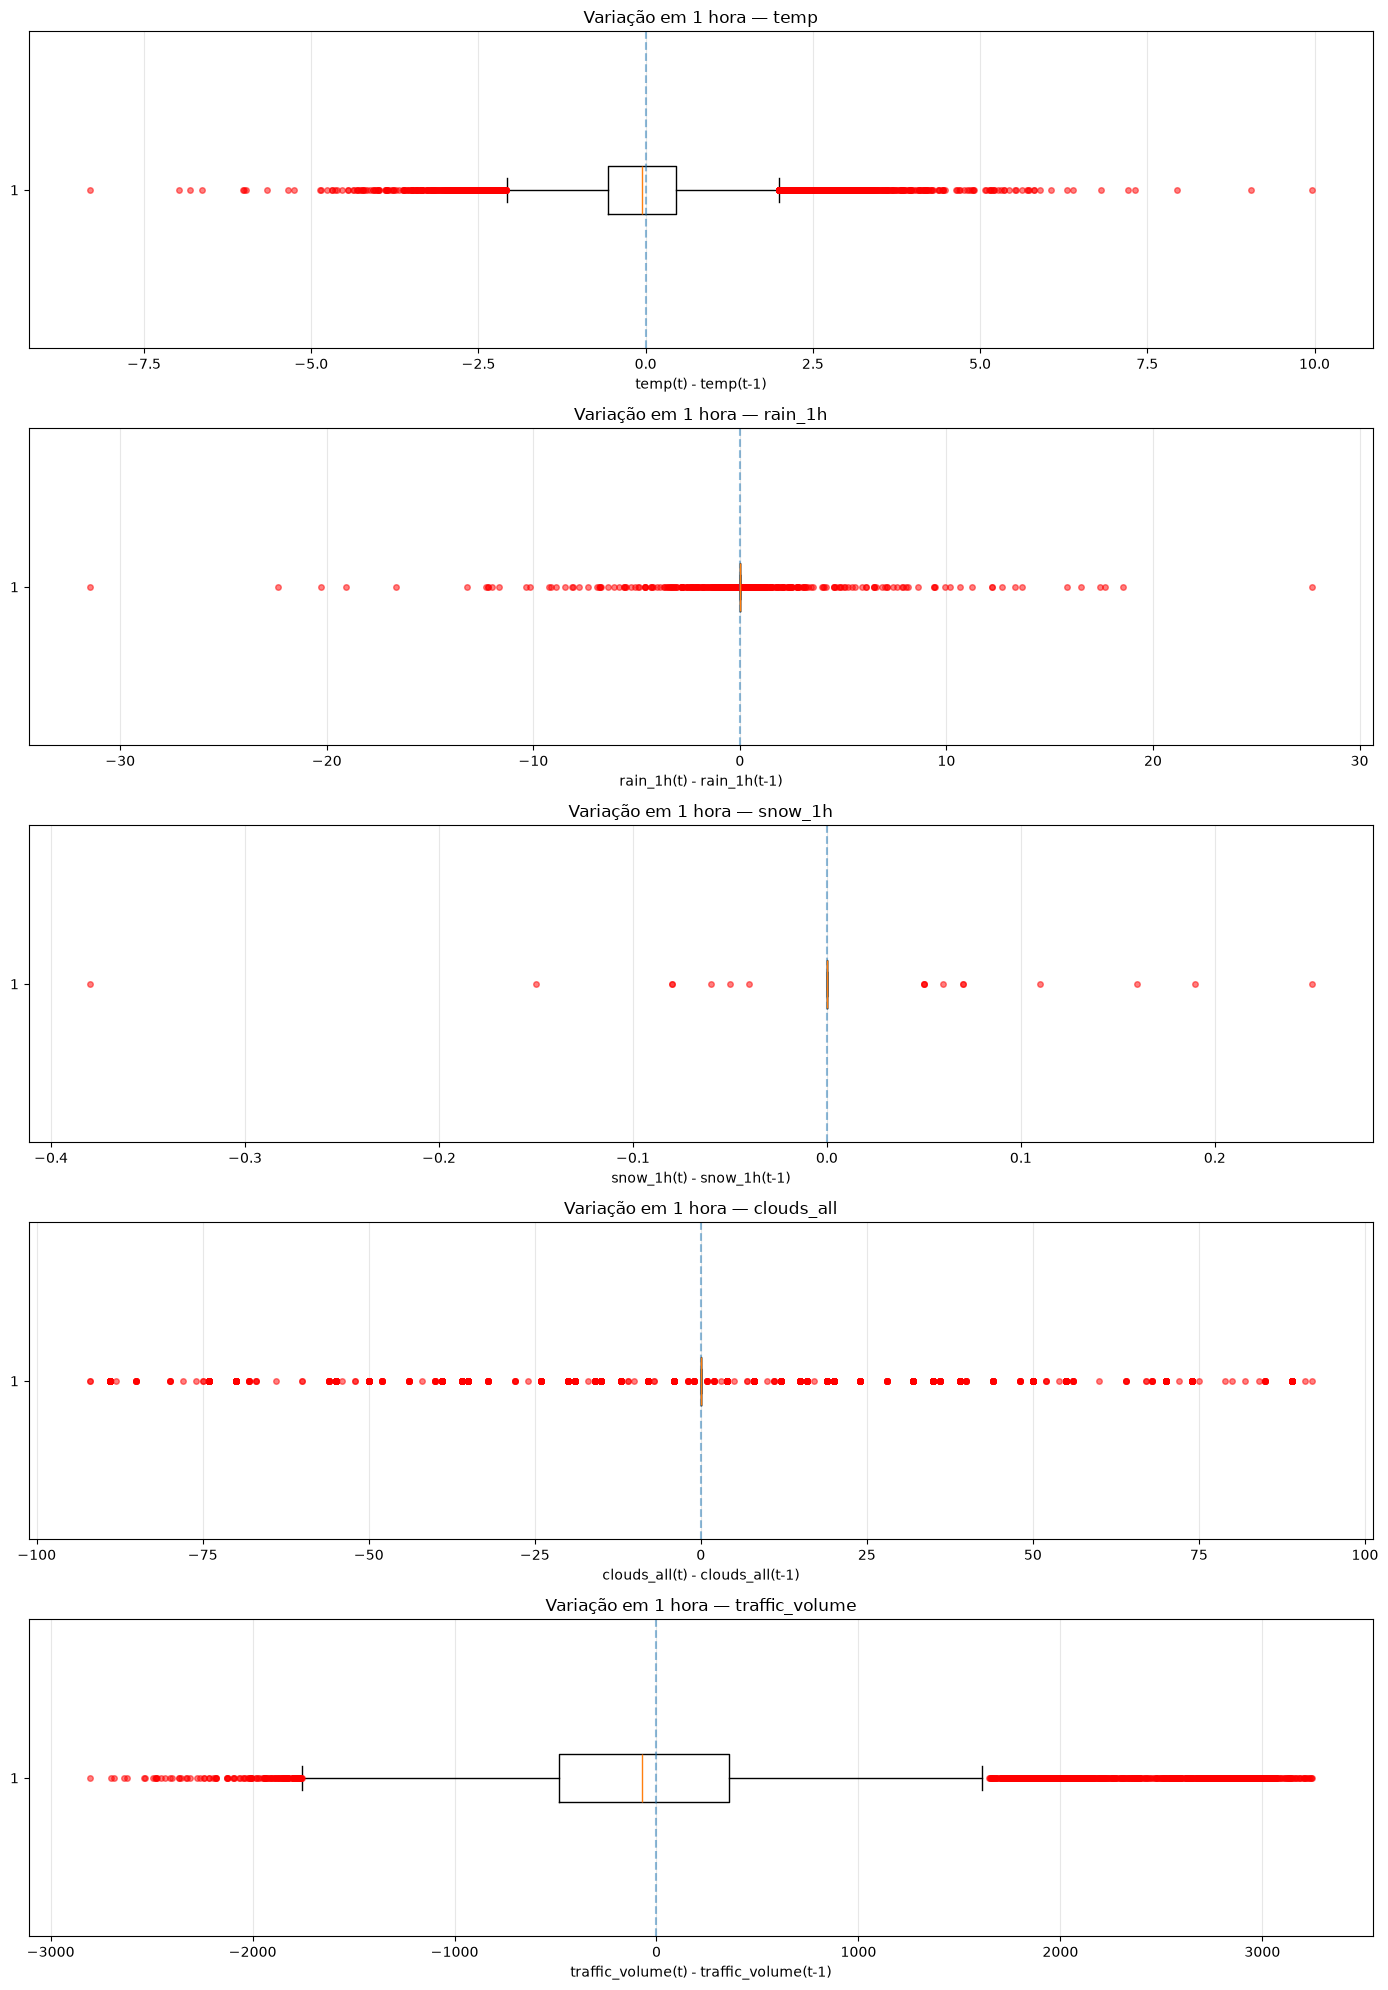


Maiores variações horárias — temp


,timestamp,temp_anterior,temp,diff_temp,abs_diff_temp
12560,2017-02-17 11:00:00,3.26,13.22,9.96,9.96
12608,2017-02-19 11:00:00,4.52,13.57,9.05,9.05
17316,2017-09-04 17:00:00,23.00,14.69,-8.31,8.31
7431,2016-07-16 09:00:00,13.38,21.33,7.95,7.95
9753,2016-10-22 08:00:00,0.45,7.76,7.31,7.31
12584,2017-02-18 11:00:00,3.13,10.34,7.21,7.21
9762,2016-10-22 18:00:00,17.22,10.24,-6.98,6.98
7531,2016-07-20 13:00:00,24.74,31.55,6.81,6.81
5452,2016-04-22 02:00:00,10.20,3.39,-6.81,6.81
434,2015-07-12 23:00:00,27.57,20.93,-6.64,6.64



Maiores variações horárias — rain_1h


,timestamp,rain_1h_anterior,rain_1h,diff_rain_1h,abs_diff_rain_1h
8184,2016-08-16 18:00:00,31.75,0.28,-31.47,31.47
8183,2016-08-16 17:00:00,4.06,31.75,27.69,27.69
1269,2015-08-16 22:00:00,25.46,3.09,-22.37,22.37
436,2015-07-13 01:00:00,27.57,7.29,-20.28,20.28
8357,2016-08-23 23:00:00,20.07,1.02,-19.05,19.05
8356,2016-08-23 22:00:00,1.52,20.07,18.55,18.55
435,2015-07-13 00:00:00,9.91,27.57,17.66,17.66
1268,2015-08-16 21:00:00,8.04,25.46,17.42,17.42
8044,2016-08-10 22:00:00,18.42,1.78,-16.64,16.64
7885,2016-08-04 07:00:00,0.00,16.51,16.51,16.51



Maiores variações horárias — snow_1h


,timestamp,snow_1h_anterior,snow_1h,diff_snow_1h,abs_diff_snow_1h
3543,2015-12-29 00:00:00,0.51,0.13,-0.38,0.38
3717,2016-01-08 13:00:00,0.00,0.25,0.25,0.25
3541,2015-12-28 22:00:00,0.25,0.44,0.19,0.19
3496,2015-12-26 09:00:00,0.05,0.21,0.16,0.16
3497,2015-12-26 10:00:00,0.21,0.06,-0.15,0.15
3709,2016-01-08 01:00:00,0.06,0.17,0.11,0.11
3544,2015-12-29 01:00:00,0.13,0.05,-0.08,0.08
3711,2016-01-08 04:00:00,0.08,0.00,-0.08,0.08
3704,2016-01-07 16:00:00,0.06,0.13,0.07,0.07
3542,2015-12-28 23:00:00,0.44,0.51,0.07,0.07



Maiores variações horárias — clouds_all


,timestamp,clouds_all_anterior,clouds_all,diff_clouds_all,abs_diff_clouds_all
9032,2016-09-21 09:00:00,0.0,92,92.0,92.0
9981,2016-10-31 21:00:00,92.0,0,-92.0,92.0
7485,2016-07-18 15:00:00,92.0,0,-92.0,92.0
16847,2017-08-16 03:00:00,1.0,92,91.0,91.0
16149,2017-07-18 01:00:00,90.0,1,-89.0,89.0
13464,2017-03-27 13:00:00,1.0,90,89.0,89.0
16160,2017-07-18 12:00:00,90.0,1,-89.0,89.0
10011,2016-11-02 03:00:00,90.0,1,-89.0,89.0
10009,2016-11-02 01:00:00,1.0,90,89.0,89.0
3534,2015-12-28 10:00:00,1.0,90,89.0,89.0



Maiores variações horárias — traffic_volume


,timestamp,traffic_volume_anterior,traffic_volume,diff_traffic_volume,abs_diff_traffic_volume
12693,2017-02-23 06:00:00,2809.0,6054,3245.0,3245.0
14648,2017-05-16 06:00:00,2604.0,5847,3243.0,3243.0
5409,2016-04-20 06:00:00,2859.0,6100,3241.0,3241.0
13839,2017-04-12 06:00:00,2624.0,5853,3229.0,3229.0
5738,2016-05-05 06:00:00,2917.0,6146,3229.0,3229.0
12981,2017-03-07 06:00:00,2746.0,5966,3220.0,3220.0
5277,2016-04-14 06:00:00,2836.0,6052,3216.0,3216.0
5456,2016-04-22 06:00:00,2824.0,6035,3211.0,3211.0
13005,2017-03-08 06:00:00,2692.0,5898,3206.0,3206.0
5690,2016-05-03 06:00:00,2878.0,6083,3205.0,3205.0


In [156]:
# ============================================================
# ANÁLISE DE CONSISTÊNCIA TEMPORAL
# ============================================================

# Trabalhar em uma cópia para não alterar o train_df
df_temporal = train_df.copy()

# ------------------------------------------------------------
# 1. Criar timestamp completo e ordenar cronologicamente
# ------------------------------------------------------------

df_temporal['timestamp'] = (
    pd.to_datetime(df_temporal['date'])
    + pd.to_timedelta(df_temporal['hr'], unit='h')
)

df_temporal = (
    df_temporal
    .sort_values('timestamp')
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Verificar distância entre registros consecutivos
# ------------------------------------------------------------

df_temporal['delta_t_h'] = (
    df_temporal['timestamp']
    .diff()
    .dt.total_seconds()
    / 3600
)

print('Distribuição dos intervalos entre registros:')
display(
    df_temporal['delta_t_h']
    .value_counts()
    .sort_index()
    .to_frame('quantidade')
)

# Registros que NÃO estão separados por exatamente 1 hora
gaps = df_temporal[
    df_temporal['delta_t_h'].notna()
    & (df_temporal['delta_t_h'] != 1)
]

print(f'\nQuantidade de gaps temporais: {len(gaps)}')

if len(gaps) > 0:
    display(
        gaps[
            ['timestamp', 'delta_t_h']
        ].head(20)
    )

# ------------------------------------------------------------
# 3. Features contínuas
# ------------------------------------------------------------

colunas_continuas = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'traffic_volume'
]

# ------------------------------------------------------------
# 4. Criar valor anterior e diferença para cada variável
# ------------------------------------------------------------

for col in colunas_continuas:

    df_temporal[f'{col}_anterior'] = (
        df_temporal[col].shift(1)
    )

    df_temporal[f'diff_{col}'] = (
        df_temporal[col]
        - df_temporal[f'{col}_anterior']
    )

    df_temporal[f'abs_diff_{col}'] = (
        df_temporal[f'diff_{col}'].abs()
    )

# ------------------------------------------------------------
# 5. Manter apenas transições realmente consecutivas:
#    exatamente 1 hora entre os registros
# ------------------------------------------------------------

df_1h = df_temporal[
    df_temporal['delta_t_h'] == 1
].copy()

print(
    f'\nTransições consecutivas de 1 hora: '
    f'{len(df_1h)}'
)

# ------------------------------------------------------------
# 6. Estatísticas das diferenças horárias
# ------------------------------------------------------------

diff_cols = [
    f'diff_{col}'
    for col in colunas_continuas
]

display(
    df_1h[diff_cols].describe().T
)

# ------------------------------------------------------------
# 7. Boxplots das diferenças entre horas consecutivas
# ------------------------------------------------------------

fig, axes = plt.subplots(
    len(colunas_continuas),
    1,
    figsize=(14, 4 * len(colunas_continuas))
)

for ax, col in zip(axes, colunas_continuas):

    valores = df_1h[f'diff_{col}'].dropna()

    ax.boxplot(
        valores,
        vert=False,
        whis=1.5,
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markeredgecolor': 'red',
            'markersize': 4,
            'alpha': 0.5
        }
    )

    ax.axvline(
        0,
        linestyle='--',
        alpha=0.5
    )

    ax.set_title(
        f'Variação em 1 hora — {col}'
    )

    ax.set_xlabel(
        f'{col}(t) - {col}(t-1)'
    )

    ax.grid(
        axis='x',
        alpha=0.3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 8. Mostrar as maiores variações absolutas
# ------------------------------------------------------------

for col in colunas_continuas:

    print(
        f'\n{"=" * 70}\n'
        f'Maiores variações horárias — {col}\n'
        f'{"=" * 70}'
    )

    display(
        df_1h[
            [
                'timestamp',
                f'{col}_anterior',
                col,
                f'diff_{col}',
                f'abs_diff_{col}'
            ]
        ]
        .sort_values(
            f'abs_diff_{col}',
            ascending=False
        )
        .head(10)
    )

In [157]:
# ============================================================
# INSPECIONAR AS MAIORES VARIAÇÕES DE TEMPERATURA
# ============================================================

n_maiores = 10

# Pega os índices das maiores variações horárias
maiores_variacoes = (
    df_1h
    .nlargest(n_maiores, 'abs_diff_temp')
    [
        [
            'timestamp',
            'temp_anterior',
            'temp',
            'diff_temp',
            'abs_diff_temp'
        ]
    ]
)

indices_maiores = maiores_variacoes.index.tolist()

print('Índices das maiores variações:')
print(indices_maiores)

display(maiores_variacoes)


# ============================================================
# Mostrar 3 horas antes e 3 horas depois de cada ocorrência
# ============================================================

for idx in indices_maiores:

    timestamp_central = df_temporal.loc[idx, 'timestamp']

    inicio = timestamp_central - pd.Timedelta(hours=3)
    fim = timestamp_central + pd.Timedelta(hours=3)

    janela = df_temporal.loc[
        (df_temporal['timestamp'] >= inicio)
        & (df_temporal['timestamp'] <= fim),
        [
            'timestamp',
            'temp',
            'diff_temp',
            'delta_t_h',
            'rain_1h',
            'snow_1h',
            'clouds_all',
            'traffic_volume'
        ]
    ].copy()

    # Marca o registro onde ocorreu a grande variação
    janela['posição'] = ''

    janela.loc[
        janela['timestamp'] < timestamp_central,
        'posição'
    ] = 'antes'

    janela.loc[
        janela['timestamp'] == timestamp_central,
        'posição'
    ] = '<<< VARIAÇÃO'

    janela.loc[
        janela['timestamp'] > timestamp_central,
        'posição'
    ] = 'depois'

    print('\n' + '=' * 90)
    print(
        f'Índice: {idx} | '
        f'Timestamp: {timestamp_central} | '
        f'Diff: {df_temporal.loc[idx, "diff_temp"]:.2f} °C'
    )
    print('=' * 90)

    display(janela)

Índices das maiores variações:
[12560, 12608, 17316, 7431, 9753, 12584, 9762, 7531, 5452, 434]


,timestamp,temp_anterior,temp,diff_temp,abs_diff_temp
12560,2017-02-17 11:00:00,3.26,13.22,9.96,9.96
12608,2017-02-19 11:00:00,4.52,13.57,9.05,9.05
17316,2017-09-04 17:00:00,23.00,14.69,-8.31,8.31
7431,2016-07-16 09:00:00,13.38,21.33,7.95,7.95
9753,2016-10-22 08:00:00,0.45,7.76,7.31,7.31
12584,2017-02-18 11:00:00,3.13,10.34,7.21,7.21
9762,2016-10-22 18:00:00,17.22,10.24,-6.98,6.98
7531,2016-07-20 13:00:00,24.74,31.55,6.81,6.81
5452,2016-04-22 02:00:00,10.20,3.39,-6.81,6.81
434,2015-07-12 23:00:00,27.57,20.93,-6.64,6.64



Índice: 12560 | Timestamp: 2017-02-17 11:00:00 | Diff: 9.96 °C


,timestamp,temp,diff_temp,delta_t_h,rain_1h,snow_1h,clouds_all,traffic_volume,posição
12557,2017-02-17 08:00:00,2.00,5.17,1.0,0.0,0.0,0,5960,antes
12558,2017-02-17 09:00:00,2.00,0.00,1.0,0.0,0.0,0,5207,antes
12559,2017-02-17 10:00:00,3.26,1.26,1.0,0.0,0.0,0,4841,antes
12560,2017-02-17 11:00:00,13.22,9.96,1.0,0.0,0.0,0,5259,<<< VARIAÇÃO
12561,2017-02-17 12:00:00,13.22,0.00,1.0,0.0,0.0,0,5385,depois
12562,2017-02-17 13:00:00,13.22,0.00,1.0,0.0,0.0,0,5351,depois
12563,2017-02-17 14:00:00,15.42,2.20,1.0,0.0,0.0,0,5474,depois



Índice: 12608 | Timestamp: 2017-02-19 11:00:00 | Diff: 9.05 °C


...

,timestamp,temp,diff_temp,delta_t_h,rain_1h,snow_1h,clouds_all,traffic_volume,posição
7528,2016-07-20 10:00:00,24.74,0.00,1.0,0.0,0.0,0,4145,antes
7529,2016-07-20 11:00:00,24.74,0.00,1.0,0.0,0.0,0,4457,antes
7530,2016-07-20 12:00:00,24.74,0.00,1.0,0.0,0.0,0,4568,antes
7531,2016-07-20 13:00:00,31.55,6.81,1.0,0.0,0.0,0,4483,<<< VARIAÇÃO
7532,2016-07-20 14:00:00,31.55,0.00,1.0,0.0,0.0,0,4803,depois
7533,2016-07-20 15:00:00,33.22,1.67,1.0,0.0,0.0,0,5073,depois
7534,2016-07-20 16:00:00,33.22,0.00,1.0,0.0,0.0,0,5952,depois



Índice: 5452 | Timestamp: 2016-04-22 02:00:00 | Diff: -6.81 °C


,timestamp,temp,diff_temp,delta_t_h,rain_1h,snow_1h,clouds_all,traffic_volume,posição
5449,2016-04-21 23:00:00,6.74,-3.40,1.0,0.0,0.0,24,2737,antes
5450,2016-04-22 00:00:00,10.90,4.16,1.0,0.0,0.0,24,983,antes
5451,2016-04-22 01:00:00,10.20,-0.70,1.0,0.0,0.0,24,948,antes
5452,2016-04-22 02:00:00,3.39,-6.81,1.0,0.0,0.0,0,442,<<< VARIAÇÃO
5453,2016-04-22 03:00:00,3.39,0.00,1.0,0.0,0.0,0,418,depois
5454,2016-04-22 04:00:00,3.39,0.00,1.0,0.0,0.0,0,921,depois
5455,2016-04-22 05:00:00,1.80,-1.59,1.0,0.0,0.0,0,2824,depois



Índice: 434 | Timestamp: 2015-07-12 23:00:00 | Diff: -6.64 °C


,timestamp,temp,diff_temp,delta_t_h,rain_1h,snow_1h,clouds_all,traffic_volume,posição
431,2015-07-12 20:00:00,29.21,-0.36,1.0,0.00,0.0,1,2866,antes
432,2015-07-12 21:00:00,27.80,-1.41,1.0,0.00,0.0,90,2379,antes
433,2015-07-12 22:00:00,27.57,-0.23,1.0,0.00,0.0,75,1784,antes
434,2015-07-12 23:00:00,20.93,-6.64,1.0,9.91,0.0,90,963,<<< VARIAÇÃO
435,2015-07-13 00:00:00,18.87,-2.06,1.0,27.57,0.0,90,492,depois
436,2015-07-13 01:00:00,19.07,0.20,1.0,7.29,0.0,75,374,depois
437,2015-07-13 02:00:00,18.97,-0.10,1.0,0.51,0.0,1,295,depois


#### Redundância entre `wheather` e `wheather_desc`

Verificamos que cada valor de weather_desc está associado a exatamente uma única categoria de weather, indicando uma relação hierárquica entre as duas variáveis. Embora weather_desc forneça uma descrição mais granular, a análise dos boxplots mostrou distribuições de traffic_volume semelhantes entre diversas subcategorias e suas respectivas categorias gerais. Além disso, algumas descrições apresentam baixa frequência, o que aumentaria a dimensionalidade e a esparsidade após one-hot encoding, podendo fazer com que o modelo aprendesse padrões específicos ou ruídos. Por esse motivo, optou-se por remover weather_desc e manter weather como representação mais compacta das condições meteorológicas.

In [158]:
#Verificando se há weather_desc relacionada a mais de um whether
train_df.groupby('weather_desc')['weather'].nunique().sort_values(ascending=False)

weather_desc
Sky is Clear                           1
broken clouds                          1
drizzle                                1
few clouds                             1
fog                                    1
freezing rain                          1
haze                                   1
heavy intensity drizzle                1
heavy intensity rain                   1
heavy snow                             1
light intensity drizzle                1
light intensity shower rain            1
light rain                             1
light rain and snow                    1
light shower snow                      1
light snow                             1
mist                                   1
moderate rain                          1
overcast clouds                        1
proximity shower rain                  1
proximity thunderstorm                 1
proximity thunderstorm with drizzle    1
proximity thunderstorm with rain       1
scattered clouds                       1
sky

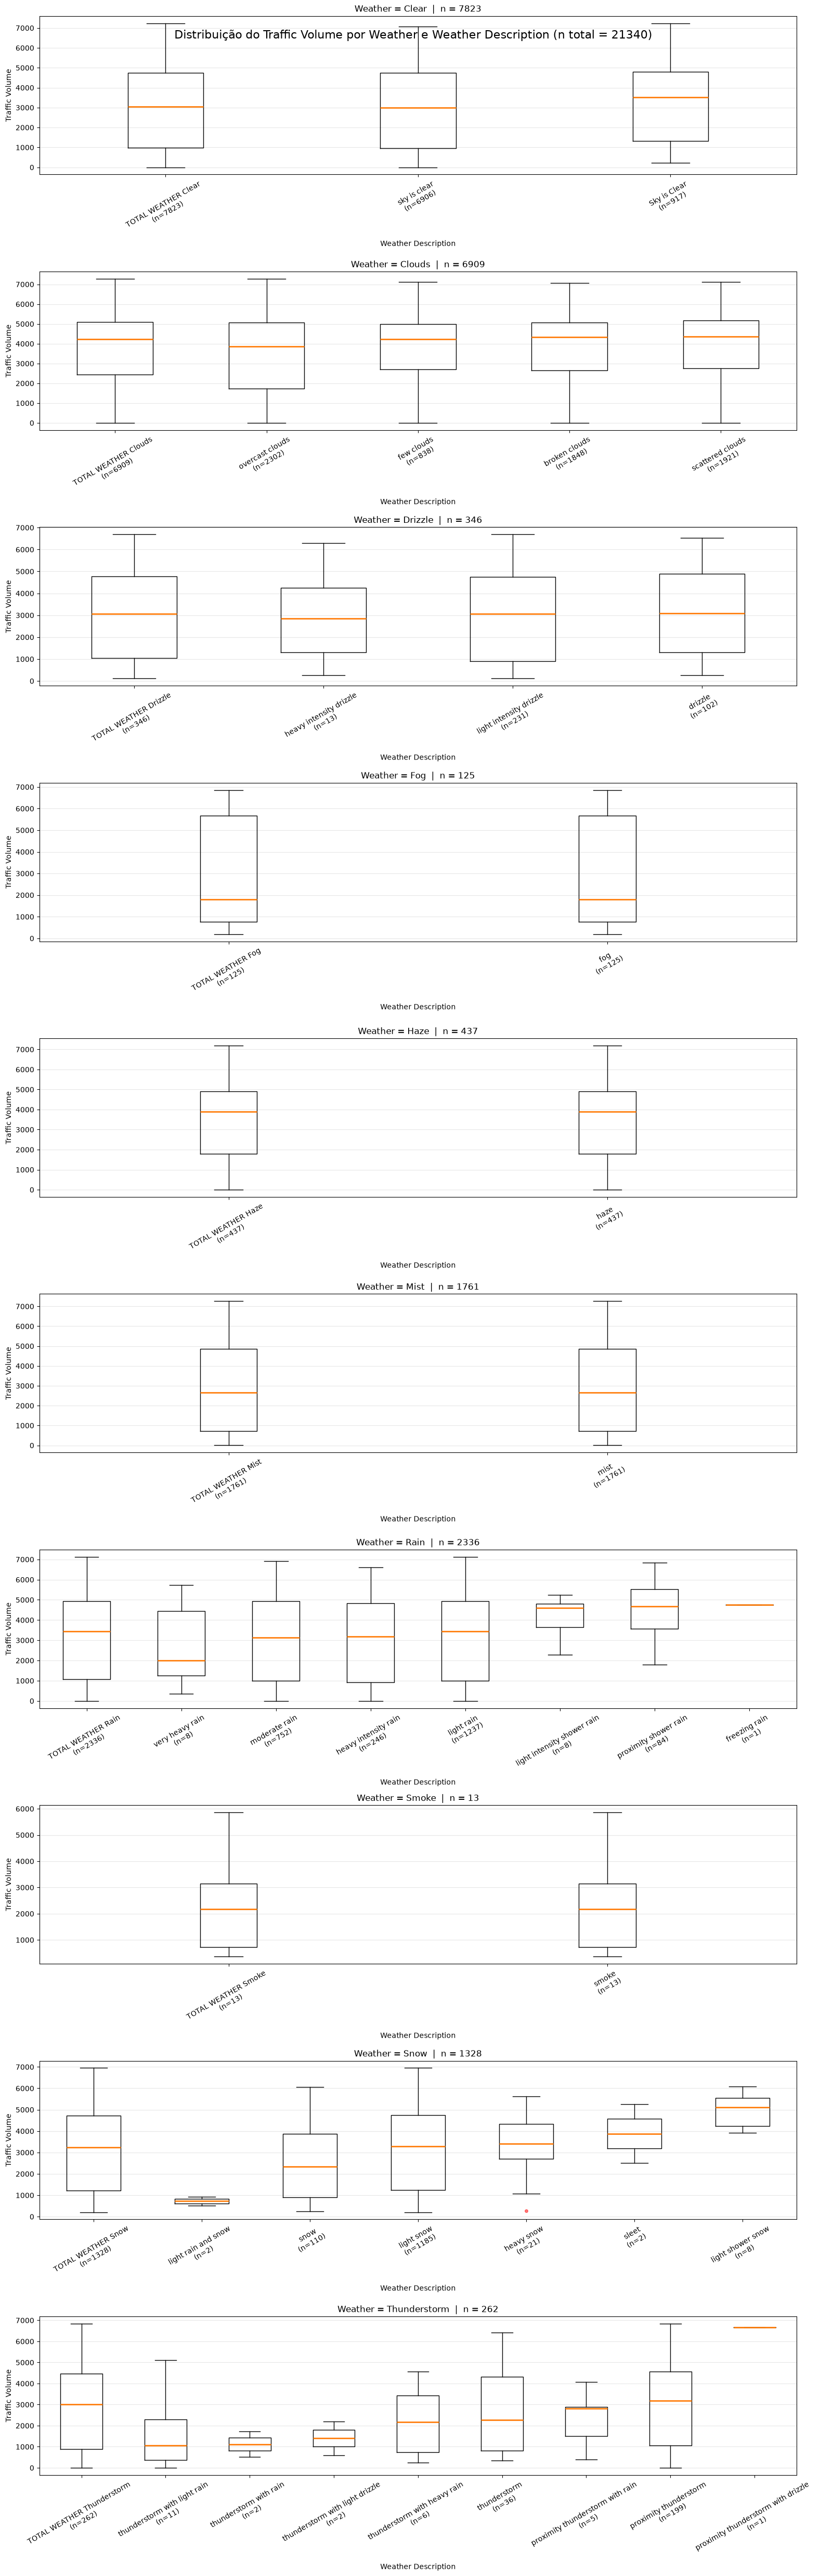

In [159]:
weather_values = sorted(train_df['weather'].dropna().unique())

fig, axes = plt.subplots(
    len(weather_values),
    1,
    figsize=(16, 5 * len(weather_values))
)

if len(weather_values) == 1:
    axes = [axes]

for ax, weather in zip(axes, weather_values):

    # Apenas registros desse weather
    df_weather = train_df[
        train_df['weather'] == weather
    ]

    total_weather = len(df_weather)

    # Ordena weather_desc pela mediana do traffic_volume
    categorias = (
        df_weather
        .groupby('weather_desc')['traffic_volume']
        .median()
        .sort_values()
        .index
        .tolist()
    )

    # -------------------------------------------------
    # Primeiro boxplot = categoria weather inteira
    # -------------------------------------------------
    valores_weather = df_weather['traffic_volume'].dropna()

    dados = [
        valores_weather.values
    ]

    labels = [
        f'TOTAL WEATHER {weather}\n(n={len(valores_weather)})'
    ]

    # -------------------------------------------------
    # Depois adiciona cada weather_desc
    # -------------------------------------------------
    for desc in categorias:

        valores = df_weather.loc[
            df_weather['weather_desc'] == desc,
            'traffic_volume'
        ].dropna()

        dados.append(valores.values)

        labels.append(
            f'{desc}\n(n={len(valores)})'
        )

    ax.boxplot(
        dados,
        tick_labels=labels,
        whis=1.5,

        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markeredgecolor': 'red',
            'markersize': 4,
            'alpha': 0.5
        },

        medianprops={
            'linewidth': 2
        }
    )

    ax.set_title(
        f'Weather = {weather}  |  n = {total_weather}'
    )

    ax.set_xlabel('Weather Description')
    ax.set_ylabel('Traffic Volume')

    ax.tick_params(
        axis='x',
        rotation=30
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

plt.suptitle(
    f'Distribuição do Traffic Volume por Weather e Weather Description '
    f'(n total = {len(train_df)})',
    fontsize=16
)

plt.tight_layout()
plt.show()

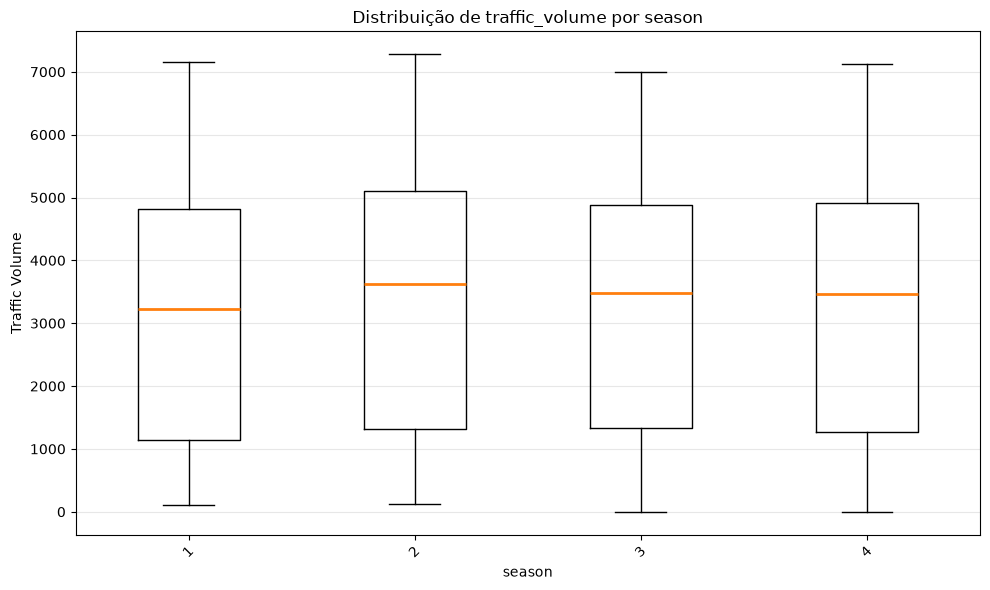

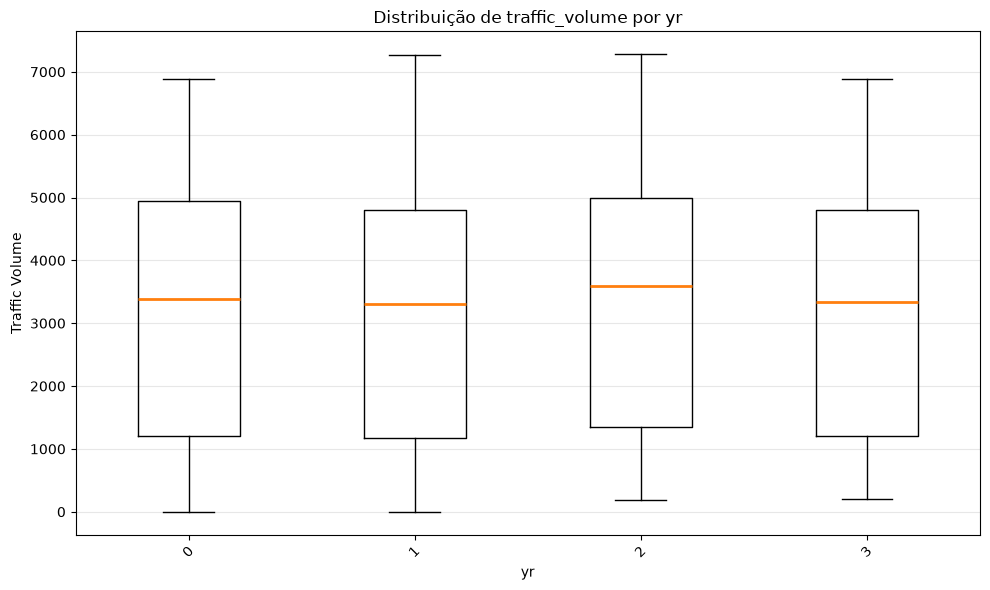

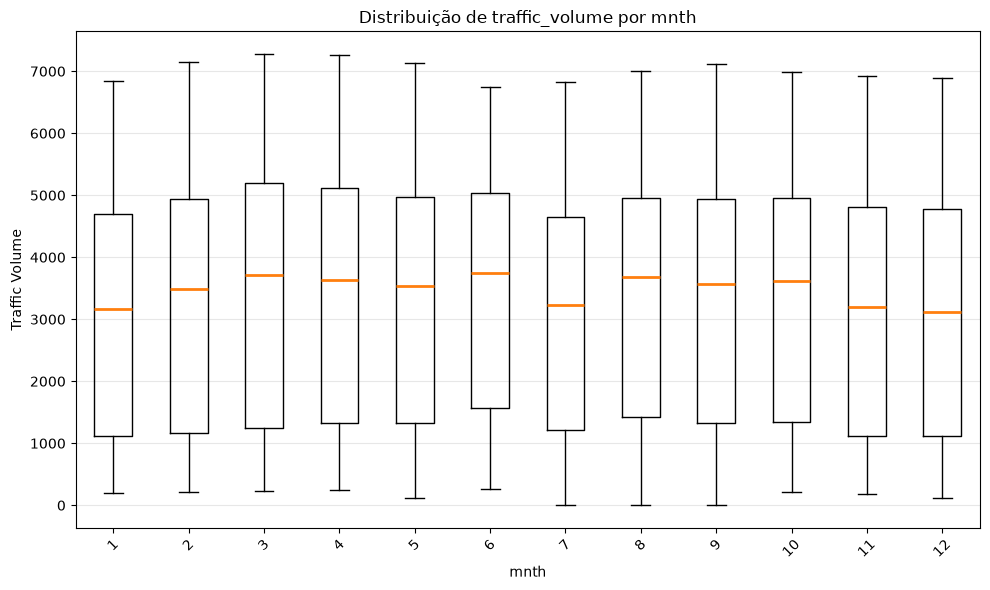

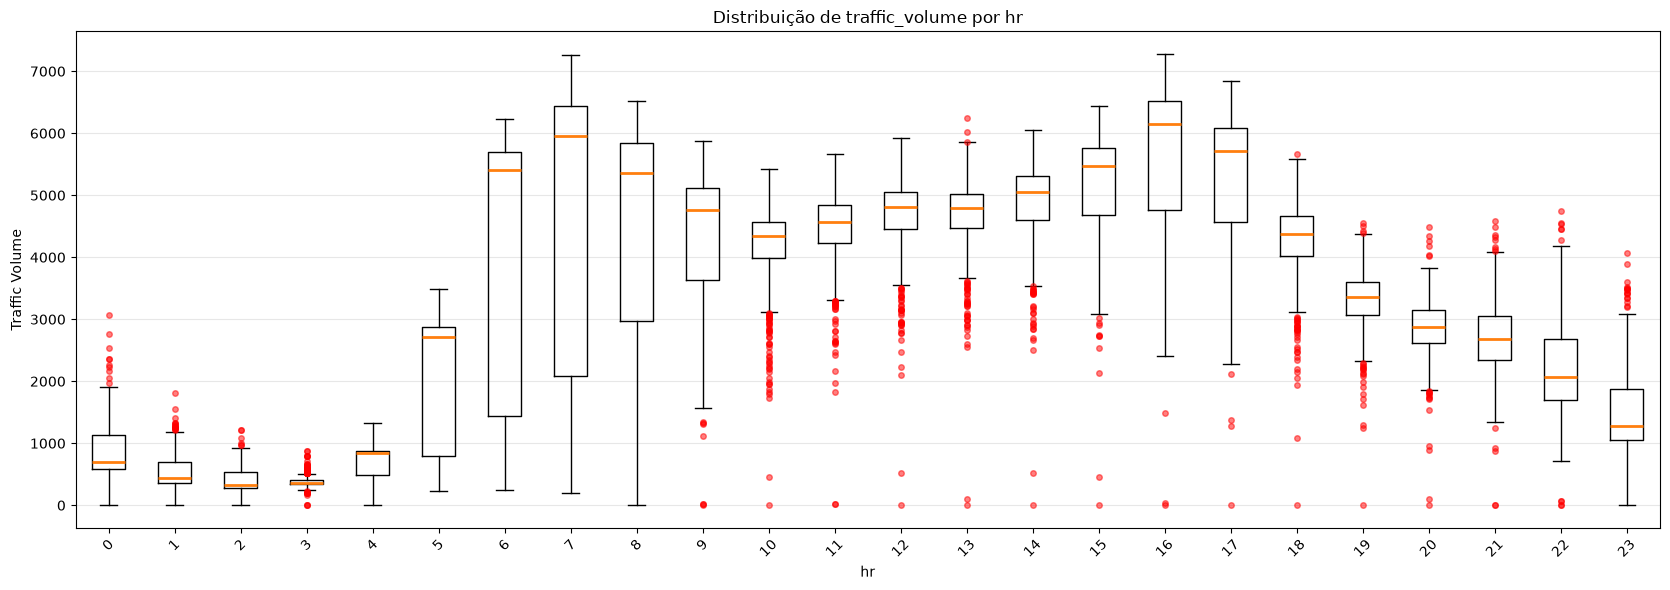

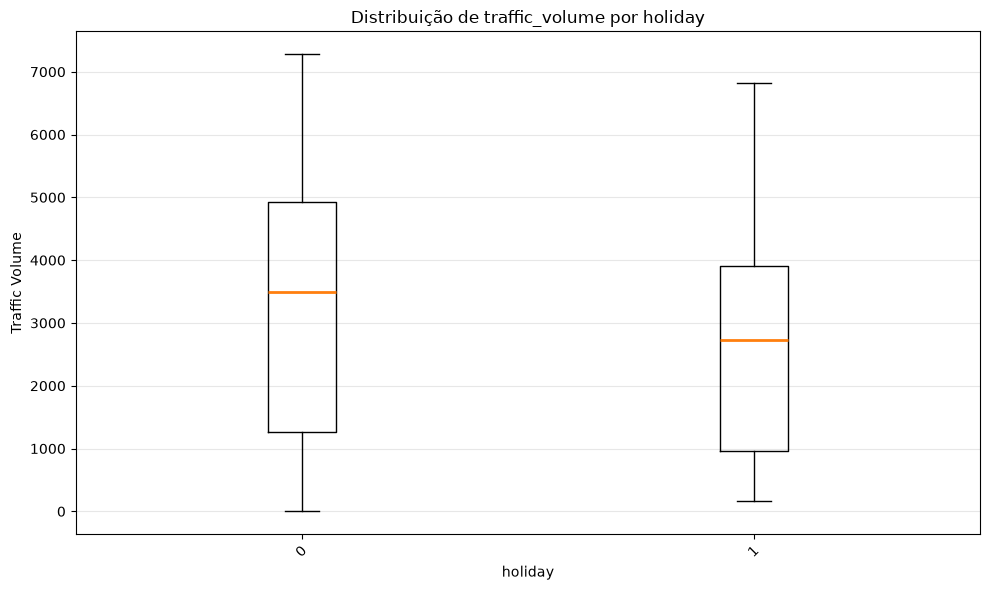

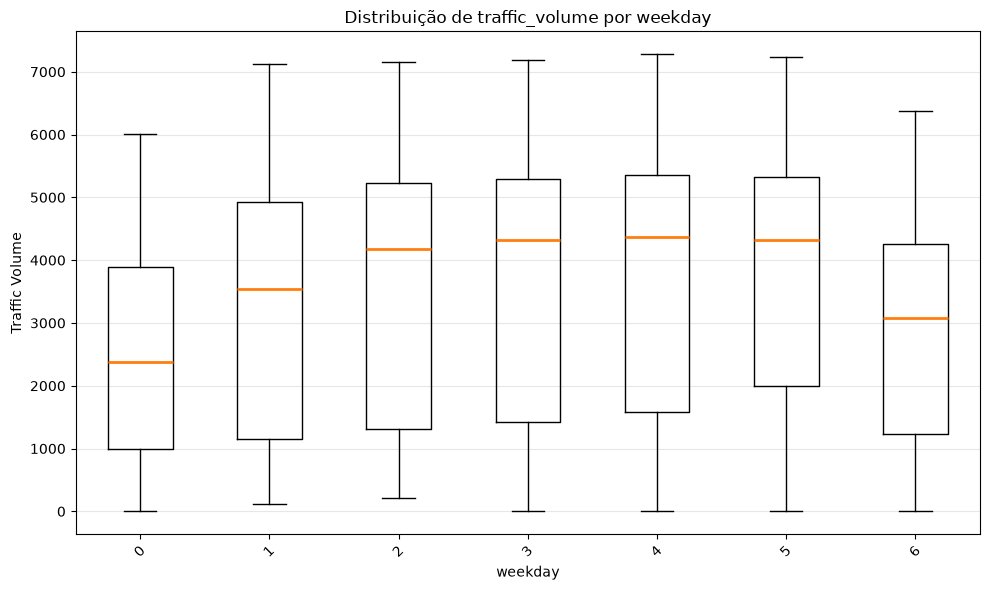

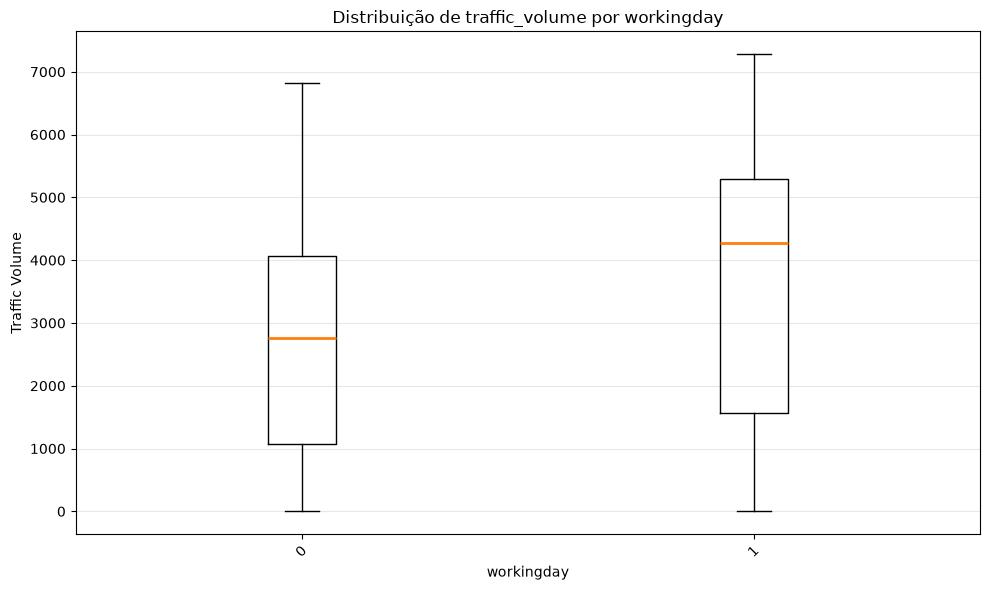

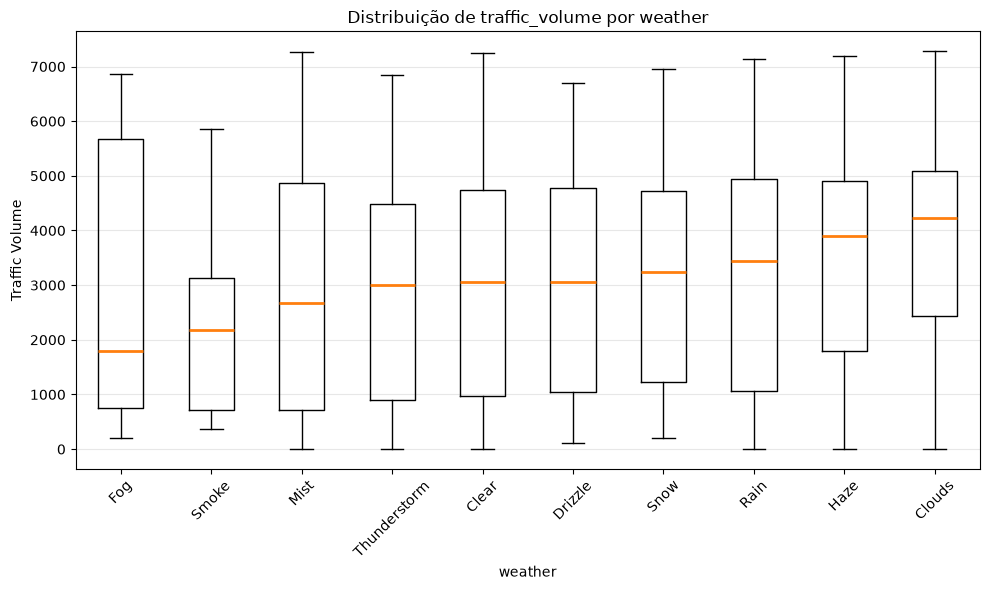

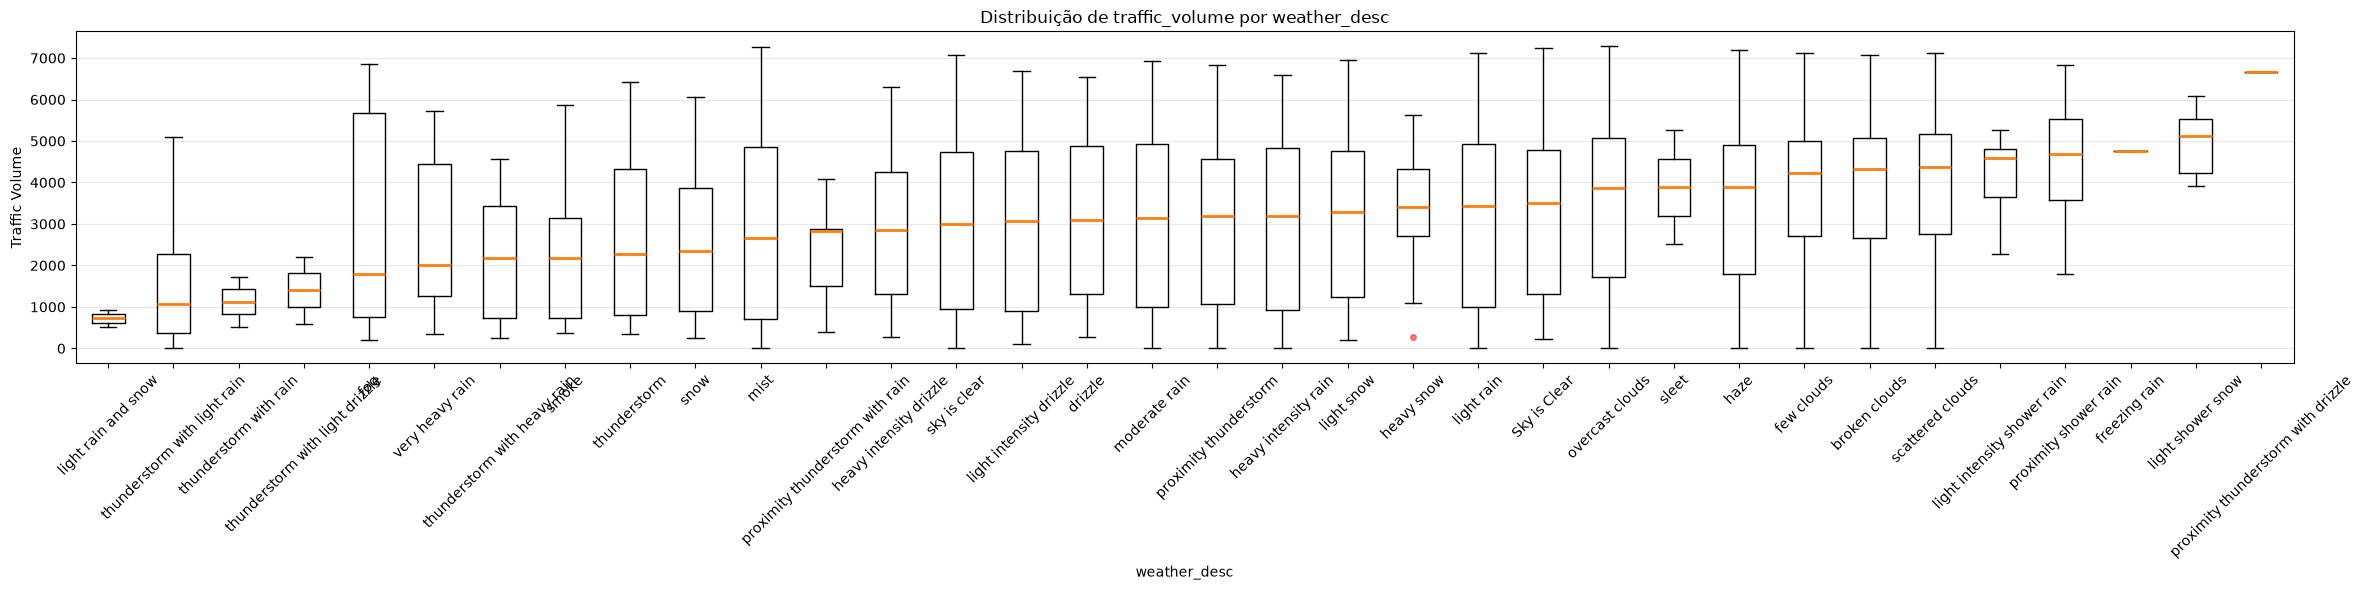

In [160]:
colunas_categoricas = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weather',
    'weather_desc'
]

for col in colunas_categoricas:

    # Categorias existentes na feature
    categorias = train_df[col].dropna().unique()

    # Para categorias numéricas, mantém uma ordem natural
    if pd.api.types.is_numeric_dtype(train_df[col]):
        categorias = sorted(categorias)

    # Para categorias textuais, ordenar pela mediana do trânsito
    # deixa a comparação visual mais fácil
    else:
        categorias = (
            train_df
            .groupby(col)['traffic_volume']
            .median()
            .sort_values()
            .index
            .tolist()
        )

    # Traffic volume correspondente a cada categoria
    dados = [
        train_df.loc[
            train_df[col] == categoria,
            'traffic_volume'
        ].dropna().values

        for categoria in categorias
    ]

    # Aumenta automaticamente a largura para variáveis
    # com muitas categorias, como hr e weather_desc
    largura = max(10, len(categorias) * 0.7)

    fig, ax = plt.subplots(figsize=(largura, 6))

    ax.boxplot(
        dados,
        tick_labels=[str(c) for c in categorias],
        whis=1.5,

        # Outliers do TRAFFIC_VOLUME dentro de cada categoria
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markeredgecolor': 'red',
            'markersize': 4,
            'alpha': 0.5
        },

        medianprops={
            'linewidth': 2
        }
    )

    ax.set_title(
        f'Distribuição de traffic_volume por {col}'
    )

    ax.set_xlabel(col)
    ax.set_ylabel('Traffic Volume')

    ax.tick_params(
        axis='x',
        rotation=45
    )

    ax.grid(
        axis='y',
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

#### Analisando correlação entre as features

In [161]:
# ============================================================
# MATRIZ DE ASSOCIAÇÃO ENTRE AS FEATURES
#
# contínua x contínua   -> |Spearman|
# categórica x contínua -> Correlation Ratio (eta)
# categórica x categórica -> Cramér's V
#
# date não entra aqui porque não é uma categoria comum.
# weather_desc já foi removida anteriormente.
# ============================================================


# ------------------------------------------------------------
# 1. Definição das variáveis
# ------------------------------------------------------------

colunas_continuas = [
    'temp',
    'rain_1h',
    'snow_1h',
    'clouds_all',
    'traffic_volume'
]

colunas_categoricas = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weather'
]

In [162]:
# ------------------------------------------------------------
# 2. Correlation Ratio (eta)
#    Para categórica x contínua
# ------------------------------------------------------------

def correlation_ratio(categories, values):

  dados = pd.DataFrame({
      'categoria': categories,
      'valor': values
  }).dropna()

  categories = dados['categoria']
  values = dados['valor']

  media_total = values.mean()

  numerador = 0

  for categoria in categories.unique():

      grupo = values[
          categories == categoria
      ]

      numerador += (
          len(grupo)
          * (grupo.mean() - media_total) ** 2
      )

  denominador = (
      (values - media_total) ** 2
  ).sum()

  if denominador == 0:
      return 0

  eta = np.sqrt(
      numerador / denominador
  )

  return eta

# ------------------------------------------------------------
# 3. Cramér's V
#    Para categórica x categórica
# ------------------------------------------------------------

def cramers_v(x, y):

    dados = pd.DataFrame({
        'x': x,
        'y': y
    }).dropna()

    tabela = pd.crosstab(
        dados['x'],
        dados['y']
    )

    observed = tabela.values
    n = observed.sum()

    if n == 0:
        return 0

    row_sum = observed.sum(axis=1)
    col_sum = observed.sum(axis=0)

    expected = np.outer(
        row_sum,
        col_sum
    ) / n

    # Evita divisão por zero
    mask = expected > 0

    chi2 = (
        ((observed - expected) ** 2 / expected)[mask]
    ).sum()

    phi2 = chi2 / n

    r, k = observed.shape

    denominador = min(
        r - 1,
        k - 1
    )

    if denominador == 0:
        return 0

    return np.sqrt(
        phi2 / denominador
    )


In [163]:
# ------------------------------------------------------------
# 4. Construção da matriz de associação
# ------------------------------------------------------------

colunas = (
    colunas_continuas
    + colunas_categoricas
)

matriz_associacao = pd.DataFrame(
    np.eye(len(colunas)),
    index=colunas,
    columns=colunas
)


for i, col1 in enumerate(colunas):

    for j in range(i + 1, len(colunas)):

        col2 = colunas[j]

        # ----------------------------------------------------
        # Contínua x Contínua
        # ----------------------------------------------------

        if (
            col1 in colunas_continuas
            and col2 in colunas_continuas
        ):

            associacao = abs(
                train_df[
                    [col1, col2]
                ]
                .corr(method='spearman')
                .iloc[0, 1]
            )

        # ----------------------------------------------------
        # Categórica x Categórica
        # ----------------------------------------------------

        elif (
            col1 in colunas_categoricas
            and col2 in colunas_categoricas
        ):

            associacao = cramers_v(
                train_df[col1],
                train_df[col2]
            )

        # ----------------------------------------------------
        # Categórica x Contínua
        # ----------------------------------------------------

        else:

            if col1 in colunas_categoricas:
                categorica = col1
                continua = col2

            else:
                categorica = col2
                continua = col1

            associacao = correlation_ratio(
                train_df[categorica],
                train_df[continua]
            )

        matriz_associacao.loc[
            col1,
            col2
        ] = associacao

        matriz_associacao.loc[
            col2,
            col1
        ] = associacao


# ------------------------------------------------------------
# 5. Mostrar matriz numericamente
# ------------------------------------------------------------

display(
    matriz_associacao.round(3)
)

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,season,yr,mnth,hr,holiday,weekday,workingday,weather
temp,1.000,0.125,0.039,0.133,0.130,0.810,0.409,0.869,0.207,0.040,0.032,0.006,0.374
rain_1h,0.125,1.000,0.001,0.110,0.022,0.082,0.090,0.098,0.034,0.007,0.029,0.015,0.248
snow_1h,0.039,0.001,1.000,0.046,0.007,0.049,0.044,0.068,0.027,0.005,0.020,0.015,0.098
clouds_all,0.133,0.110,0.046,1.000,0.100,0.177,0.094,0.202,0.131,0.029,0.080,0.042,0.805
traffic_volume,0.130,0.022,0.007,0.100,1.000,0.046,0.044,0.067,0.885,0.060,0.220,0.224,0.164
season,0.810,0.082,0.049,0.177,0.046,1.000,0.291,1.000,0.012,0.077,0.010,0.034,0.223
yr,0.409,0.090,0.044,0.094,0.044,0.291,1.000,0.377,0.018,0.042,0.010,0.012,0.118
mnth,0.869,0.098,0.068,0.202,0.067,1.000,0.377,1.000,0.012,0.108,0.027,0.051,0.156
hr,0.207,0.034,0.027,0.131,0.885,0.012,0.018,0.012,1.000,0.007,0.008,0.006,0.093
holiday,0.040,0.007,0.005,0.029,0.060,0.077,0.042,0.108,0.007,1.000,0.257,0.269,0.065


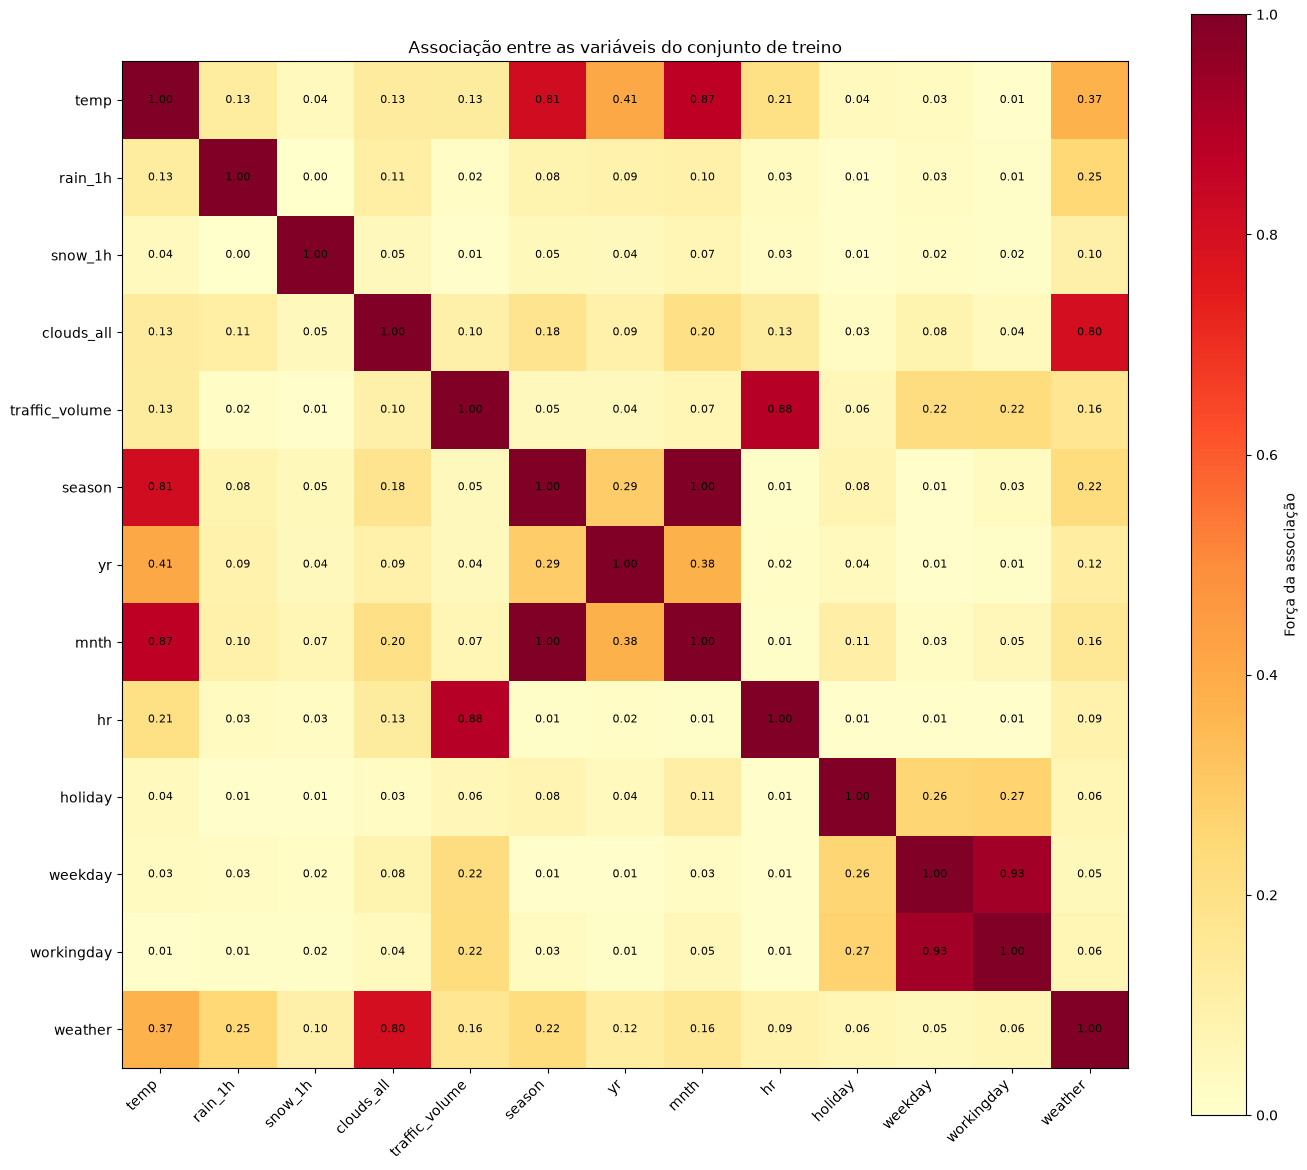

In [164]:
# ------------------------------------------------------------
# 6. Heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(14, 12)
)

im = ax.imshow(
    matriz_associacao,
    vmin=0,
    vmax=1,
    cmap='YlOrRd'
)

ax.set_xticks(
    range(len(colunas))
)

ax.set_yticks(
    range(len(colunas))
)

ax.set_xticklabels(
    colunas,
    rotation=45,
    ha='right'
)

ax.set_yticklabels(
    colunas
)


# Valores dentro de cada célula
for i in range(len(colunas)):

    for j in range(len(colunas)):

        valor = matriz_associacao.iloc[i, j]

        ax.text(
            j,
            i,
            f'{valor:.2f}',
            ha='center',
            va='center',
            fontsize=8
        )


fig.colorbar(
    im,
    ax=ax,
    label='Força da associação'
)

ax.set_title(
    'Associação entre as variáveis do conjunto de treino'
)

plt.tight_layout()
plt.show()


In [165]:
# ------------------------------------------------------------
# 7. Listar os pares mais associados
#    (ignorando a diagonal e duplicatas)
# ------------------------------------------------------------

pares = []

for i in range(len(colunas)):

    for j in range(i + 1, len(colunas)):

        pares.append({
            'variavel_1': colunas[i],
            'variavel_2': colunas[j],
            'associacao': matriz_associacao.iloc[i, j]
        })


pares_associacao = (
    pd.DataFrame(pares)
    .sort_values(
        'associacao',
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    pares_associacao.head(20)
)

,variavel_1,variavel_2,associacao
0,season,mnth,1.000000
1,weekday,workingday,0.929523
2,traffic_volume,hr,0.884823
3,temp,mnth,0.868594
4,temp,season,0.810198
5,clouds_all,weather,0.804603
6,temp,yr,0.408931
7,yr,mnth,0.377285
8,temp,weather,0.374463
9,season,yr,0.291233


#### Redundância entre `workingday` e a combinação `weekday` + `holiday`

Verificamos inicialmente que a variável `workingday` é deterministicamente derivável a partir das variáveis `weekday` e `holiday`.

Antes da aplicação do *one-hot encoding*, essa relação pode ser representada por uma regra lógica. Considerando a codificação observada no conjunto de dados:

\[
workingday =
\begin{cases}
1, & \text{se } weekday \in \{1,2,3,4,5\} \text{ e } holiday = 0 \\
0, & \text{caso contrário}
\end{cases}
\]

Assim, `workingday` assume valor 1 apenas quando o registro corresponde a um dia de semana que não é feriado. Logo, do ponto de vista estritamente informacional, `workingday` não acrescenta uma informação independente, pois pode ser completamente reconstruída a partir de `weekday` e `holiday`.

Após a aplicação do *one-hot encoding* em `weekday`, cada valor possível do dia da semana passa a ser representado por uma variável indicadora binária. Denotando por `weekday_k` a variável que assume valor 1 quando `weekday = k` e 0 caso contrário, a relação anterior pode ser escrita como:

\[
workingday =
weekday_1 +
weekday_2 +
weekday_3 +
weekday_4 +
weekday_5 -
holiday
\]

Portanto, após o *one-hot encoding*, `workingday` passa a ser uma combinação linear exata das variáveis indicadoras referentes aos dias úteis e da variável `holiday`. Como neste trabalho serão utilizados modelos lineares e modelos lineares generalizados, a inclusão simultânea de `workingday`, `weekday` e `holiday` introduziria redundância linear na matriz de atributos, podendo causar multicolinearidade e dificultar a interpretação dos coeficientes estimados.

Entretanto, também foi considerada a possibilidade inversa: remover `weekday` e `holiday` e utilizar apenas `workingday` como uma representação mais compacta da informação relacionada ao tipo de dia. Essa alternativa reduziria consideravelmente a dimensionalidade após o *one-hot encoding*, já que `workingday` é uma variável binária.

Para avaliar essa possibilidade, foram comparadas as distribuições de `traffic_volume` entre os diferentes dias da semana, separando dias efetivamente trabalhados, finais de semana e feriados.

Nos dias em que `workingday = 1`, as distribuições de `traffic_volume` para os diferentes valores de `weekday` mostraram-se bastante semelhantes. As medianas, intervalos interquartis e perfis horários apresentaram comportamento próximo entre segunda e sexta-feira, indicando que `workingday = 1` representa de forma satisfatória o comportamento agregado dos dias úteis não feriados.

Por outro lado, o grupo `workingday = 0` apresentou maior heterogeneidade. Essa categoria reúne situações distintas: sábados, domingos e feriados ocorridos em dias de semana. A análise dos boxplots mostrou, em particular, diferenças entre as distribuições de sábado e domingo, com deslocamentos perceptíveis na mediana e nos quartis. Os feriados em dias de semana também apresentaram comportamento distinto em relação aos finais de semana.

Dessa forma, embora `workingday` seja uma representação compacta e descreva adequadamente os dias úteis, utilizá-la isoladamente implicaria perda de informação relevante dentro da categoria `workingday = 0`. Em particular, o modelo deixaria de distinguir sábado de domingo e também não conseguiria representar explicitamente o efeito específico dos feriados.

Com base nas análises anteriores, foram consideradas duas possíveis representações para as informações relacionadas ao dia da semana, feriados e dias úteis.

1. **Manter `weekday` e `workingday`, removendo `holiday`.**

   Como `workingday` permite distinguir um dia de semana comum de um feriado que ocorre durante a semana, a informação mais relevante de `holiday` ainda pode ser recuperada pela combinação entre `weekday` e `workingday`. Por exemplo, um registro com `weekday` correspondente a uma terça-feira e `workingday = 0` indica que aquela terça-feira é um feriado.

   Essa abordagem preserva integralmente a informação do dia específico da semana, permitindo ao modelo distinguir, por exemplo, sábado de domingo e também diferentes dias úteis entre si.

   Entretanto, após a aplicação do *one-hot encoding*, `weekday`, que possui sete categorias, passa a ser representada por seis variáveis indicadoras caso uma categoria seja utilizada como referência. Somando-se `workingday`, essa representação necessita de sete dimensões para codificar essas informações. O principal *trade-off*, portanto, é a maior dimensionalidade do problema.

2. **Substituir `weekday`, `holiday` e `workingday` por uma variável categórica mais compacta, denominada, por exemplo, `day_type`.**

   A análise exploratória mostrou que os diferentes dias úteis não feriados apresentam distribuições de `traffic_volume` bastante semelhantes entre si e são bem representados pelo estado `workingday = 1`. Dessa forma, não parece necessário distinguir individualmente segunda-feira, terça-feira, quarta-feira, quinta-feira e sexta-feira quando estes são dias normais de trabalho.

   Por outro lado, a categoria `workingday = 0` mostrou-se excessivamente abrangente. Sábados, domingos e feriados apresentam distribuições distintas de tráfego e, portanto, não devem ser agrupados em uma única categoria.

   Dessa forma, propõe-se uma variável `day_type` com quatro possíveis estados:

   - `workingday`: dia útil não feriado;
   - `saturday`: sábado não feriado;
   - `sunday`: domingo não feriado;
   - `holiday`: feriado, independentemente do dia da semana em que ocorre.

   Essa representação preserva as principais diferenças observadas durante a análise exploratória, ao mesmo tempo em que elimina distinções entre dias úteis que parecem pouco relevantes para a variável resposta.

   Após o *one-hot encoding*, utilizando uma das quatro categorias como referência, `day_type` necessita de apenas três variáveis indicadoras. Dessa forma, a representação é consideravelmente mais compacta que `weekday + workingday`, que necessita de sete dimensões.

   Outra vantagem dessa abordagem é evitar a criação de categorias específicas para combinações raras, como "feriado em uma terça-feira" ou "feriado em uma quarta-feira". Como o número de observações de feriados para alguns dias da semana é pequeno, suas distribuições apresentam elevada variabilidade amostral. Agrupar todos os feriados em uma única categoria reduz a esparsidade e produz uma representação potencialmente mais robusta para os modelos lineares e lineares generalizados utilizados neste trabalho.

Assim, a segunda abordagem apresenta um compromisso interessante entre preservação de informação e redução de dimensionalidade. A decisão definitiva entre as duas representações pode ser realizada posteriormente por meio da comparação do desempenho dos modelos utilizando validação temporal.

> OBS: Haverá um parâmetro de controle no método que gera os conjuntos de treino, que mudam facilmente a abordagem.

In [166]:
# Para uma combinação de "holiday" + "weekday", "workingday" é único:
verificacao = (
    train_df
    .groupby(['weekday', 'holiday'])['workingday']
    .agg(
        valores='unique',
        quantidade='nunique'
    )
)

display(verificacao)

valores  quantidade
weekday holiday                    
0       0           [0]           1
1       0           [1]           1
        1           [0]           1
2       0           [1]           1
        1           [0]           1
3       0           [1]           1
        1           [0]           1
4       0           [1]           1
        1           [0]           1
5       0           [1]           1
        1           [0]           1
6       0           [0]           1

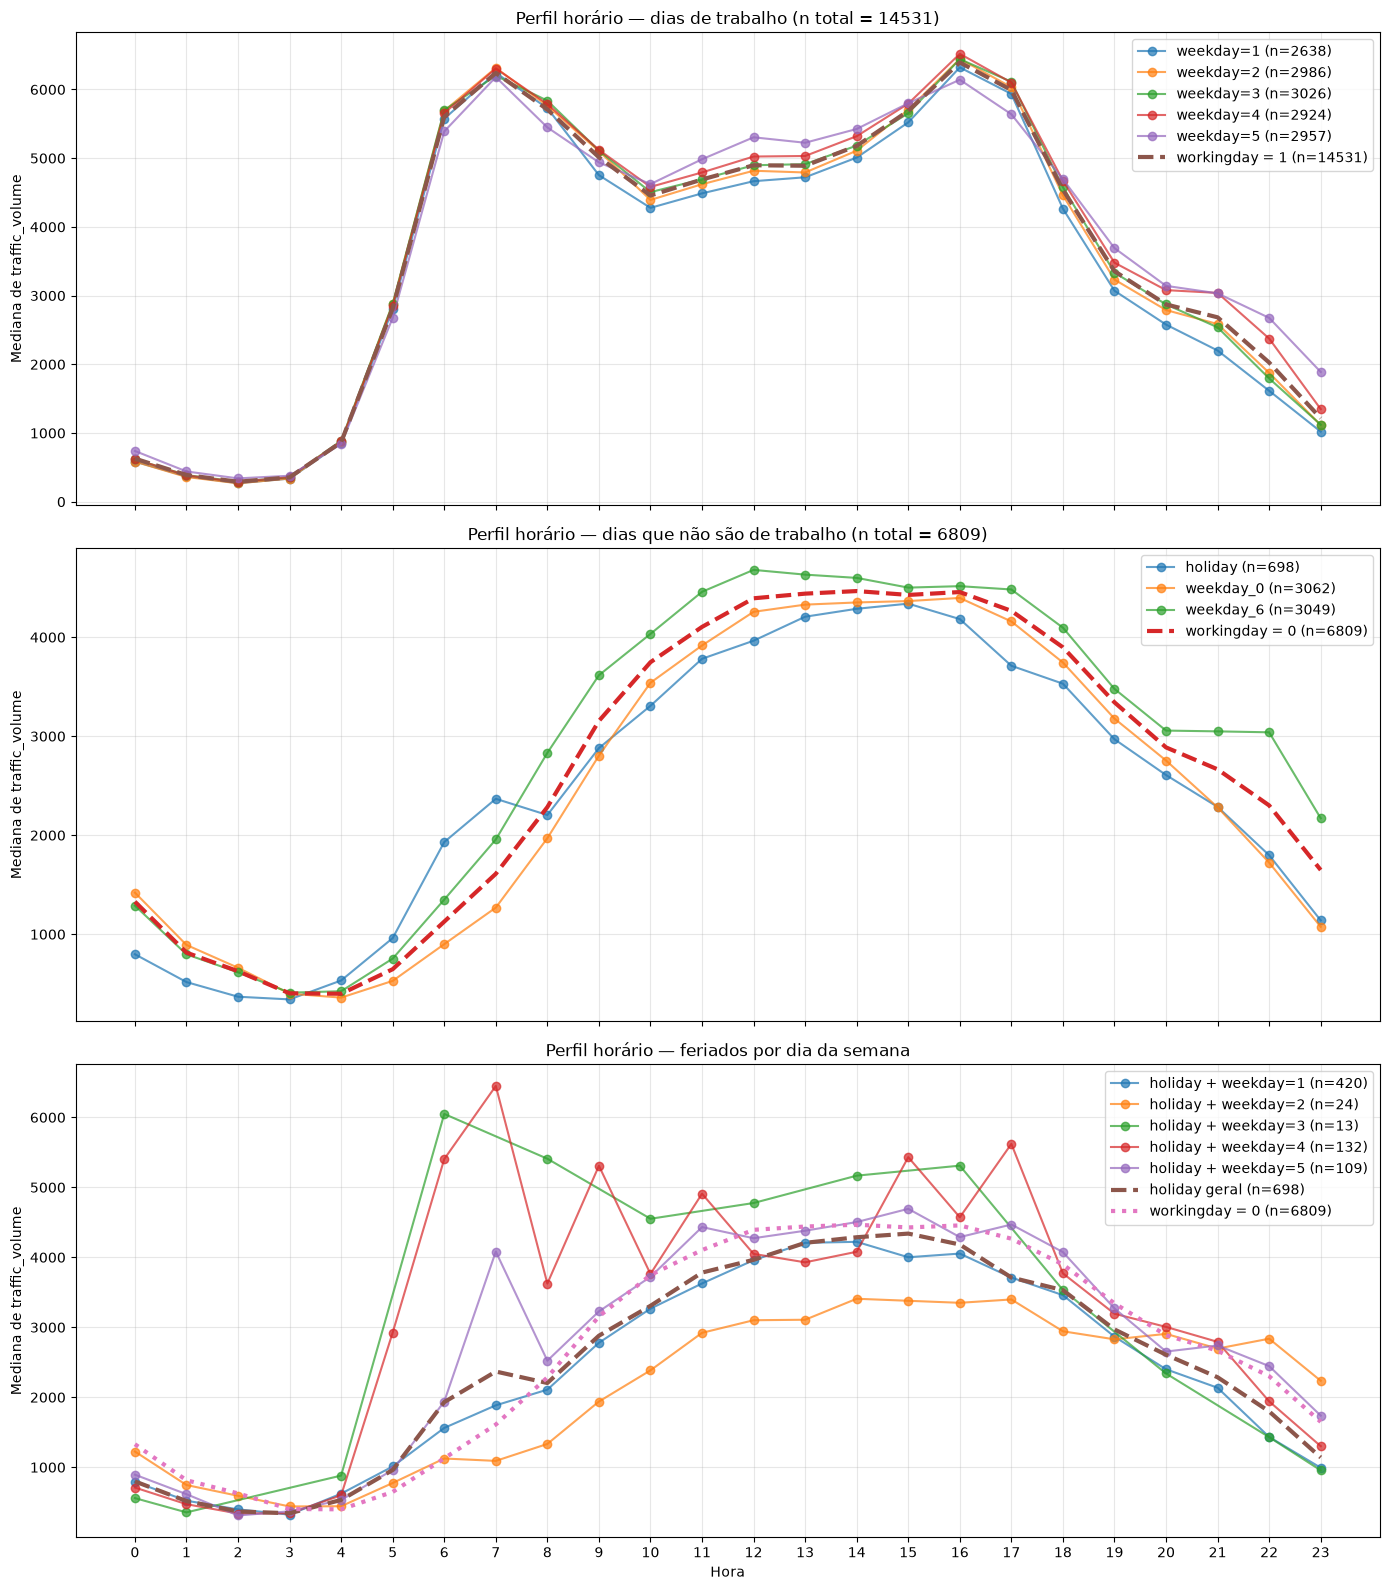

In [167]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 16),
    sharex=True
)

# ============================================================
# Preparação dos dados
# ============================================================

df_work = train_df[
    train_df['workingday'] == 1
].copy()

df_nonwork = train_df[
    train_df['workingday'] == 0
].copy()

df_holiday = train_df[
    train_df['holiday'] == 1
].copy()


# ============================================================
# GRÁFICO 1 — DIAS DE TRABALHO
# Separados por weekday
# ============================================================

for weekday in sorted(df_work['weekday'].unique()):

    df_dia = df_work[
        df_work['weekday'] == weekday
    ]

    dados = (
        df_dia
        .groupby('hr')['traffic_volume']
        .median()
    )

    axes[0].plot(
        dados.index,
        dados.values,
        marker='o',
        alpha=0.7,
        label=f'weekday={weekday} (n={len(df_dia)})'
    )


# Perfil agregado de workingday = 1
agregado_work = (
    df_work
    .groupby('hr')['traffic_volume']
    .median()
)

axes[0].plot(
    agregado_work.index,
    agregado_work.values,
    linestyle='--',
    linewidth=3,
    label=f'workingday = 1 (n={len(df_work)})'
)

axes[0].set_title(
    f'Perfil horário — dias de trabalho '
    f'(n total = {len(df_work)})'
)

axes[0].set_ylabel('Mediana de traffic_volume')
axes[0].grid(alpha=0.3)
axes[0].legend()


# ============================================================
# GRÁFICO 2 — DIAS QUE NÃO SÃO DE TRABALHO
#
# Separa apenas:
# - sábado
# - domingo
# - feriados (todos juntos)
# ============================================================

df_nonwork['tipo_dia'] = np.where(
    df_nonwork['holiday'] == 1,
    'holiday',
    'weekday_' + df_nonwork['weekday'].astype(str)
)

for tipo in sorted(df_nonwork['tipo_dia'].unique()):

    df_tipo = df_nonwork[
        df_nonwork['tipo_dia'] == tipo
    ]

    dados = (
        df_tipo
        .groupby('hr')['traffic_volume']
        .median()
    )

    axes[1].plot(
        dados.index,
        dados.values,
        marker='o',
        alpha=0.7,
        label=f'{tipo} (n={len(df_tipo)})'
    )


# Perfil agregado de workingday = 0
agregado_nonwork = (
    df_nonwork
    .groupby('hr')['traffic_volume']
    .median()
)

axes[1].plot(
    agregado_nonwork.index,
    agregado_nonwork.values,
    linestyle='--',
    linewidth=3,
    label=f'workingday = 0 (n={len(df_nonwork)})'
)

axes[1].set_title(
    f'Perfil horário — dias que não são de trabalho '
    f'(n total = {len(df_nonwork)})'
)

axes[1].set_ylabel('Mediana de traffic_volume')
axes[1].grid(alpha=0.3)
axes[1].legend()


# ============================================================
# GRÁFICO 3 — FERIADOS SEPARADOS PELO DIA DA SEMANA
#
# Compara:
# - feriado em cada weekday
# - todos os feriados agregados
# - todos os workingday = 0
# ============================================================

for weekday in sorted(df_holiday['weekday'].unique()):

    df_dia = df_holiday[
        df_holiday['weekday'] == weekday
    ]

    dados = (
        df_dia
        .groupby('hr')['traffic_volume']
        .median()
    )

    axes[2].plot(
        dados.index,
        dados.values,
        marker='o',
        alpha=0.7,
        label=(
            f'holiday + weekday={weekday} '
            f'(n={len(df_dia)})'
        )
    )


# Todos os feriados juntos
agregado_holiday = (
    df_holiday
    .groupby('hr')['traffic_volume']
    .median()
)

axes[2].plot(
    agregado_holiday.index,
    agregado_holiday.values,
    linestyle='--',
    linewidth=3,
    label=f'holiday geral (n={len(df_holiday)})'
)


# Todos os workingday = 0
axes[2].plot(
    agregado_nonwork.index,
    agregado_nonwork.values,
    linestyle=':',
    linewidth=3,
    label=f'workingday = 0 (n={len(df_nonwork)})'
)

axes[2].set_title(
    'Perfil horário — feriados por dia da semana'
)

axes[2].set_xlabel('Hora')
axes[2].set_ylabel('Mediana de traffic_volume')

axes[2].set_xticks(range(24))

axes[2].grid(alpha=0.3)
axes[2].legend()


# ============================================================
# Layout
# ============================================================

plt.tight_layout()
plt.show()

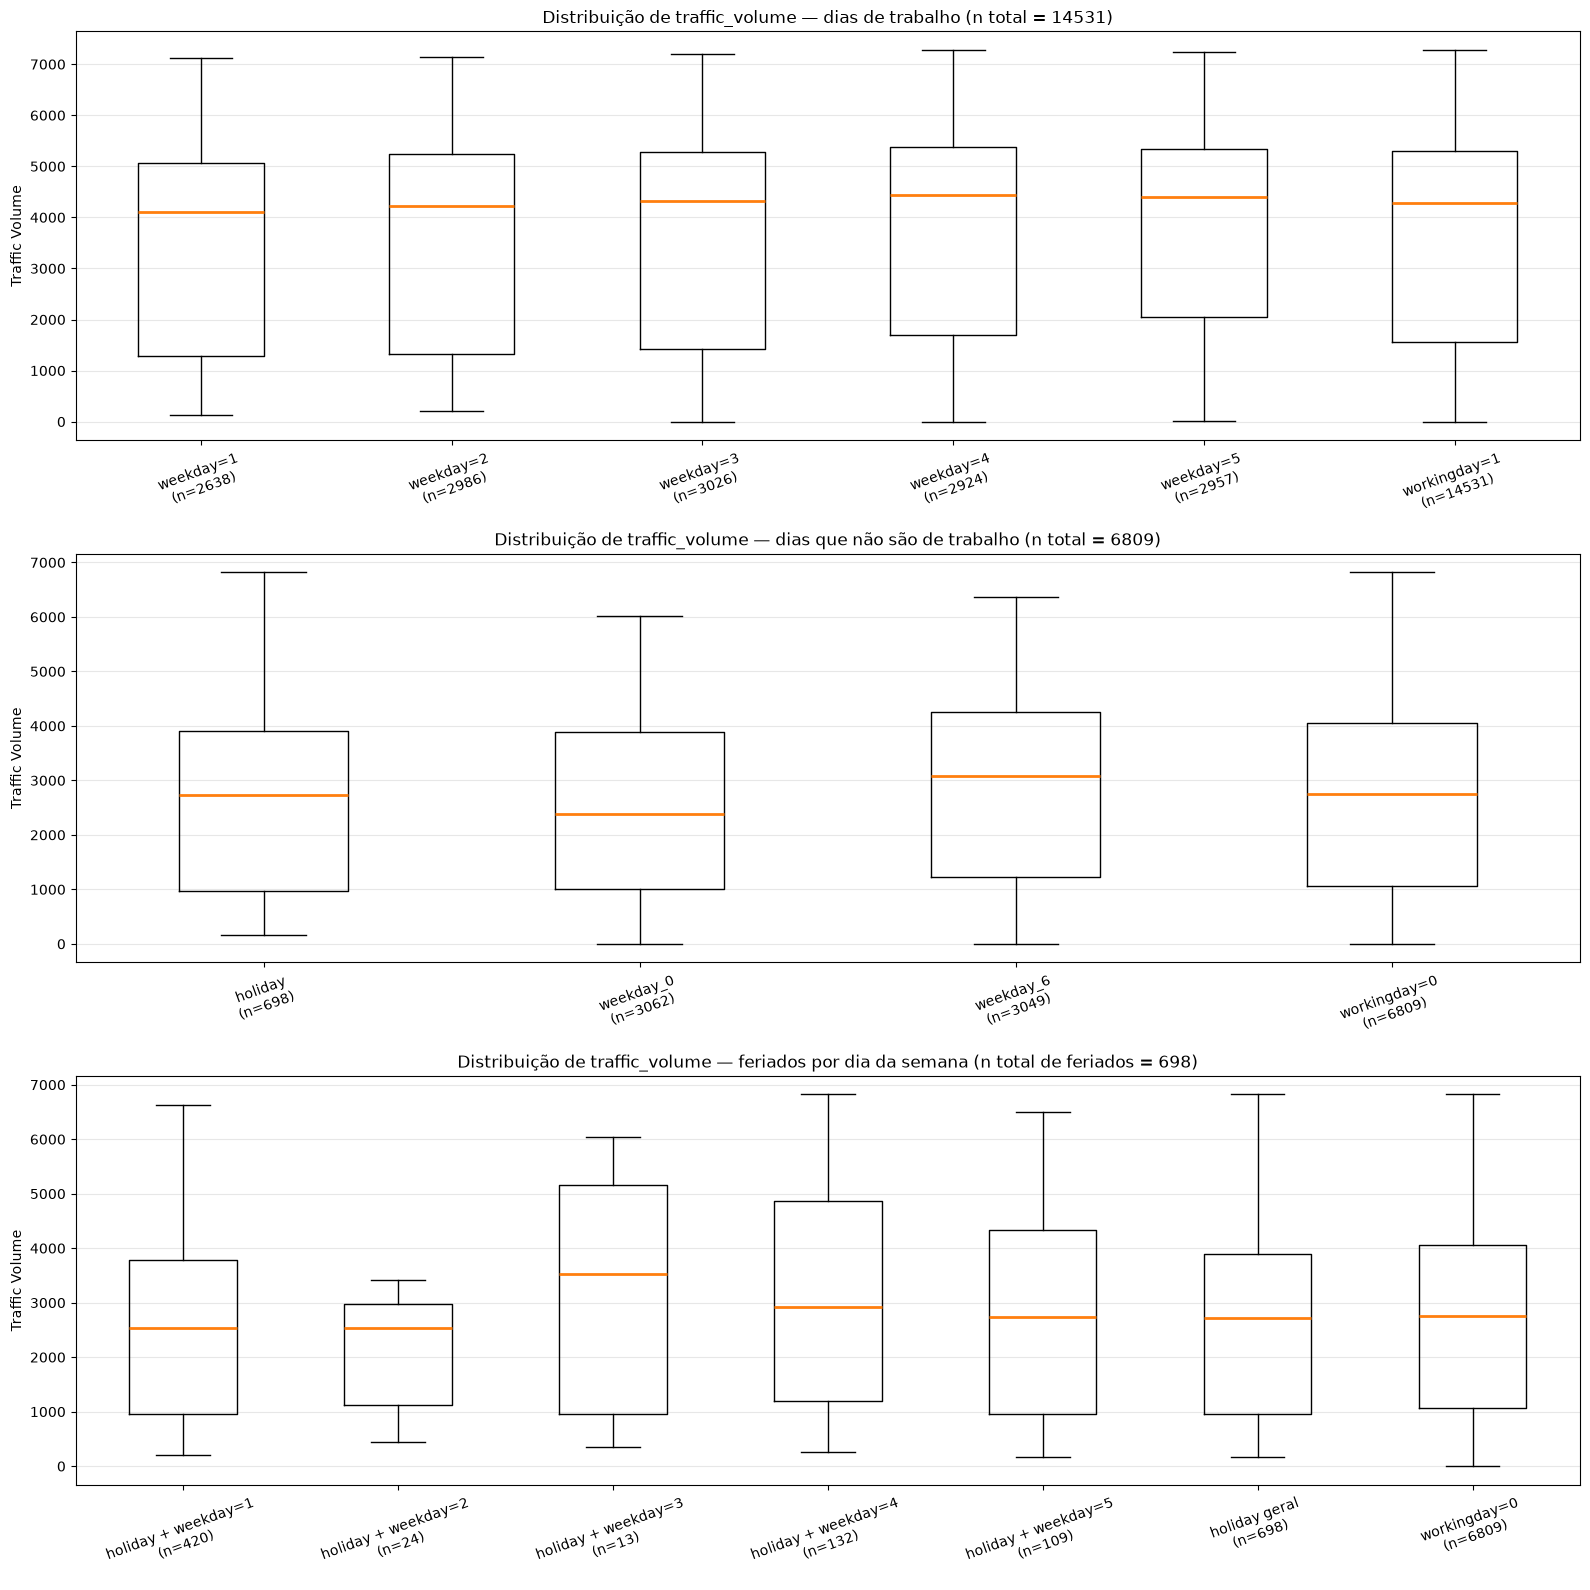

In [168]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(16, 16)
)

# ============================================================
# Preparação dos dados
# ============================================================

df_work = train_df[
    train_df['workingday'] == 1
].copy()

df_nonwork = train_df[
    train_df['workingday'] == 0
].copy()

df_holiday = train_df[
    train_df['holiday'] == 1
].copy()


# ============================================================
# GRÁFICO 1 — BOXPLOTS DOS DIAS DE TRABALHO
# weekday = 1..5 + workingday=1 agregado
# ============================================================

dados_1 = []
labels_1 = []

for weekday in sorted(df_work['weekday'].unique()):

    valores = df_work.loc[
        df_work['weekday'] == weekday,
        'traffic_volume'
    ].dropna()

    dados_1.append(valores.values)
    labels_1.append(
        f'weekday={weekday}\n(n={len(valores)})'
    )

# workingday = 1 agregado
valores_work = df_work['traffic_volume'].dropna()
dados_1.append(valores_work.values)
labels_1.append(
    f'workingday=1\n(n={len(valores_work)})'
)

axes[0].boxplot(
    dados_1,
    tick_labels=labels_1,
    whis=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'red',
        'markersize': 4,
        'alpha': 0.4
    },
    medianprops={
        'linewidth': 2
    }
)

axes[0].set_title(
    f'Distribuição de traffic_volume — dias de trabalho '
    f'(n total = {len(df_work)})'
)

axes[0].set_ylabel('Traffic Volume')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)


# ============================================================
# GRÁFICO 2 — BOXPLOTS DOS DIAS NÃO ÚTEIS
# holiday + weekday_0 + weekday_6 + workingday=0 agregado
# ============================================================

df_nonwork['tipo_dia'] = np.where(
    df_nonwork['holiday'] == 1,
    'holiday',
    'weekday_' + df_nonwork['weekday'].astype(str)
)

dados_2 = []
labels_2 = []

for tipo in sorted(df_nonwork['tipo_dia'].unique()):

    valores = df_nonwork.loc[
        df_nonwork['tipo_dia'] == tipo,
        'traffic_volume'
    ].dropna()

    dados_2.append(valores.values)
    labels_2.append(
        f'{tipo}\n(n={len(valores)})'
    )

# workingday = 0 agregado
valores_nonwork = df_nonwork['traffic_volume'].dropna()
dados_2.append(valores_nonwork.values)
labels_2.append(
    f'workingday=0\n(n={len(valores_nonwork)})'
)

axes[1].boxplot(
    dados_2,
    tick_labels=labels_2,
    whis=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'red',
        'markersize': 4,
        'alpha': 0.4
    },
    medianprops={
        'linewidth': 2
    }
)

axes[1].set_title(
    f'Distribuição de traffic_volume — dias que não são de trabalho '
    f'(n total = {len(df_nonwork)})'
)

axes[1].set_ylabel('Traffic Volume')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(axis='y', alpha=0.3)


# ============================================================
# GRÁFICO 3 — BOXPLOTS DOS FERIADOS POR DIA DA SEMANA
# holiday_weekday_k + holiday geral + workingday=0 agregado
# ============================================================

dados_3 = []
labels_3 = []

for weekday in sorted(df_holiday['weekday'].unique()):

    valores = df_holiday.loc[
        df_holiday['weekday'] == weekday,
        'traffic_volume'
    ].dropna()

    dados_3.append(valores.values)
    labels_3.append(
        f'holiday + weekday={weekday}\n(n={len(valores)})'
    )

# holiday geral
valores_holiday = df_holiday['traffic_volume'].dropna()
dados_3.append(valores_holiday.values)
labels_3.append(
    f'holiday geral\n(n={len(valores_holiday)})'
)

# workingday = 0 agregado
dados_3.append(valores_nonwork.values)
labels_3.append(
    f'workingday=0\n(n={len(valores_nonwork)})'
)

axes[2].boxplot(
    dados_3,
    tick_labels=labels_3,
    whis=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'red',
        'markersize': 4,
        'alpha': 0.4
    },
    medianprops={
        'linewidth': 2
    }
)

axes[2].set_title(
    f'Distribuição de traffic_volume — feriados por dia da semana '
    f'(n total de feriados = {len(df_holiday)})'
)

axes[2].set_ylabel('Traffic Volume')
axes[2].tick_params(axis='x', rotation=20)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

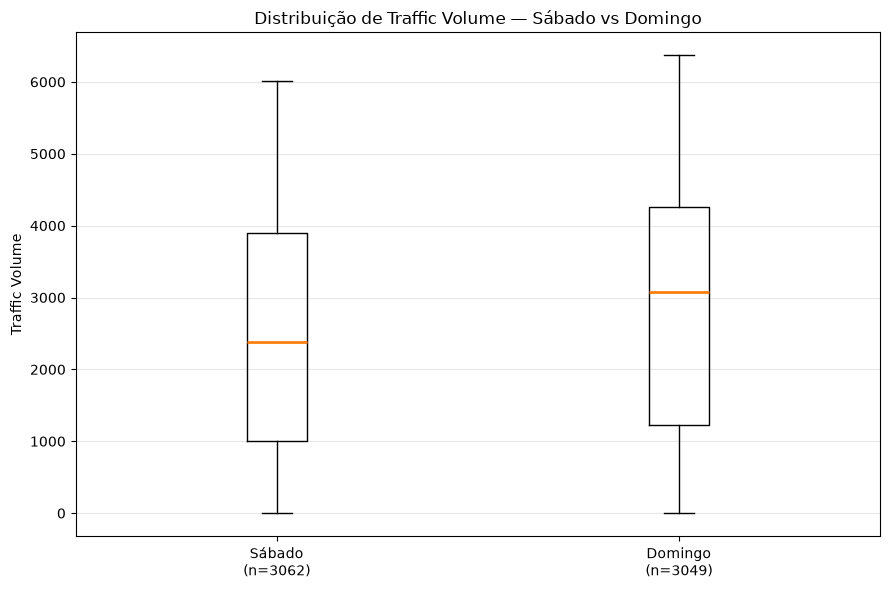

In [169]:
# Apenas sábado e domingo que NÃO são feriados
df_fim_semana = train_df[
    (train_df['weekday'].isin([0, 6])) &
    (train_df['holiday'] == 0)
].copy()

dados = []
labels = []

for weekday, nome in [
    (0, 'Sábado'),
    (6, 'Domingo')
]:

    valores = df_fim_semana.loc[
        df_fim_semana['weekday'] == weekday,
        'traffic_volume'
    ].dropna()

    dados.append(valores.values)

    labels.append(
        f'{nome}\n(n={len(valores)})'
    )

plt.figure(figsize=(9, 6))

plt.boxplot(
    dados,
    tick_labels=labels,
    whis=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'red',
        'markersize': 4,
        'alpha': 0.4
    },
    medianprops={
        'linewidth': 2
    }
)

plt.title(
    'Distribuição de Traffic Volume — Sábado vs Domingo'
)

plt.ylabel('Traffic Volume')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Redundância entre `mnth` e `season`
Dado que `mnth` e `season` representam aspectos fortemente relacionados da sazonalidade anual, optou-se por não utilizar ambas simultaneamente.

A análise exploratória mostrou que os meses pertencentes a uma mesma estação apresentam distribuições e perfis horários de `traffic_volume` bastante semelhantes, embora algumas diferenças tenham sido observadas, principalmente nas estações 1 e 3.

Dessa forma, foram definidas duas alternativas de modelagem:

- utilizar `mnth`, preservando maior granularidade temporal, mas com 9 dimensões a mais para o modelo após o OHE e descarte da outra;
- utilizar `season`, reduzindo a dimensionalidade da representação após o OHE, só adiciona 2 dimensões.

As duas alternativas serão avaliadas separadamente durante a etapa de modelagem, mantendo-se as demais variáveis e procedimentos de pré-processamento constantes. A escolha final será feita com base no desempenho obtido em validação temporal, permitindo avaliar empiricamente o trade-off entre maior granularidade e maior parcimônia do modelo.

In [170]:
tabela_season_month = pd.crosstab(
    train_df['mnth'],
    train_df['season'],
    margins=True,
    margins_name='Total'
)

display(tabela_season_month)

season,1,2,3,4,Total
mnth,,,,,
1,1947,0,0,0,1947
2,1621,0,0,0,1621
3,0,1212,0,0,1212
4,0,1312,0,0,1312
5,0,1464,0,0,1464
6,0,0,1582,0,1582
7,0,0,2215,0,2215
8,0,0,2216,0,2216
9,0,0,0,2079,2079


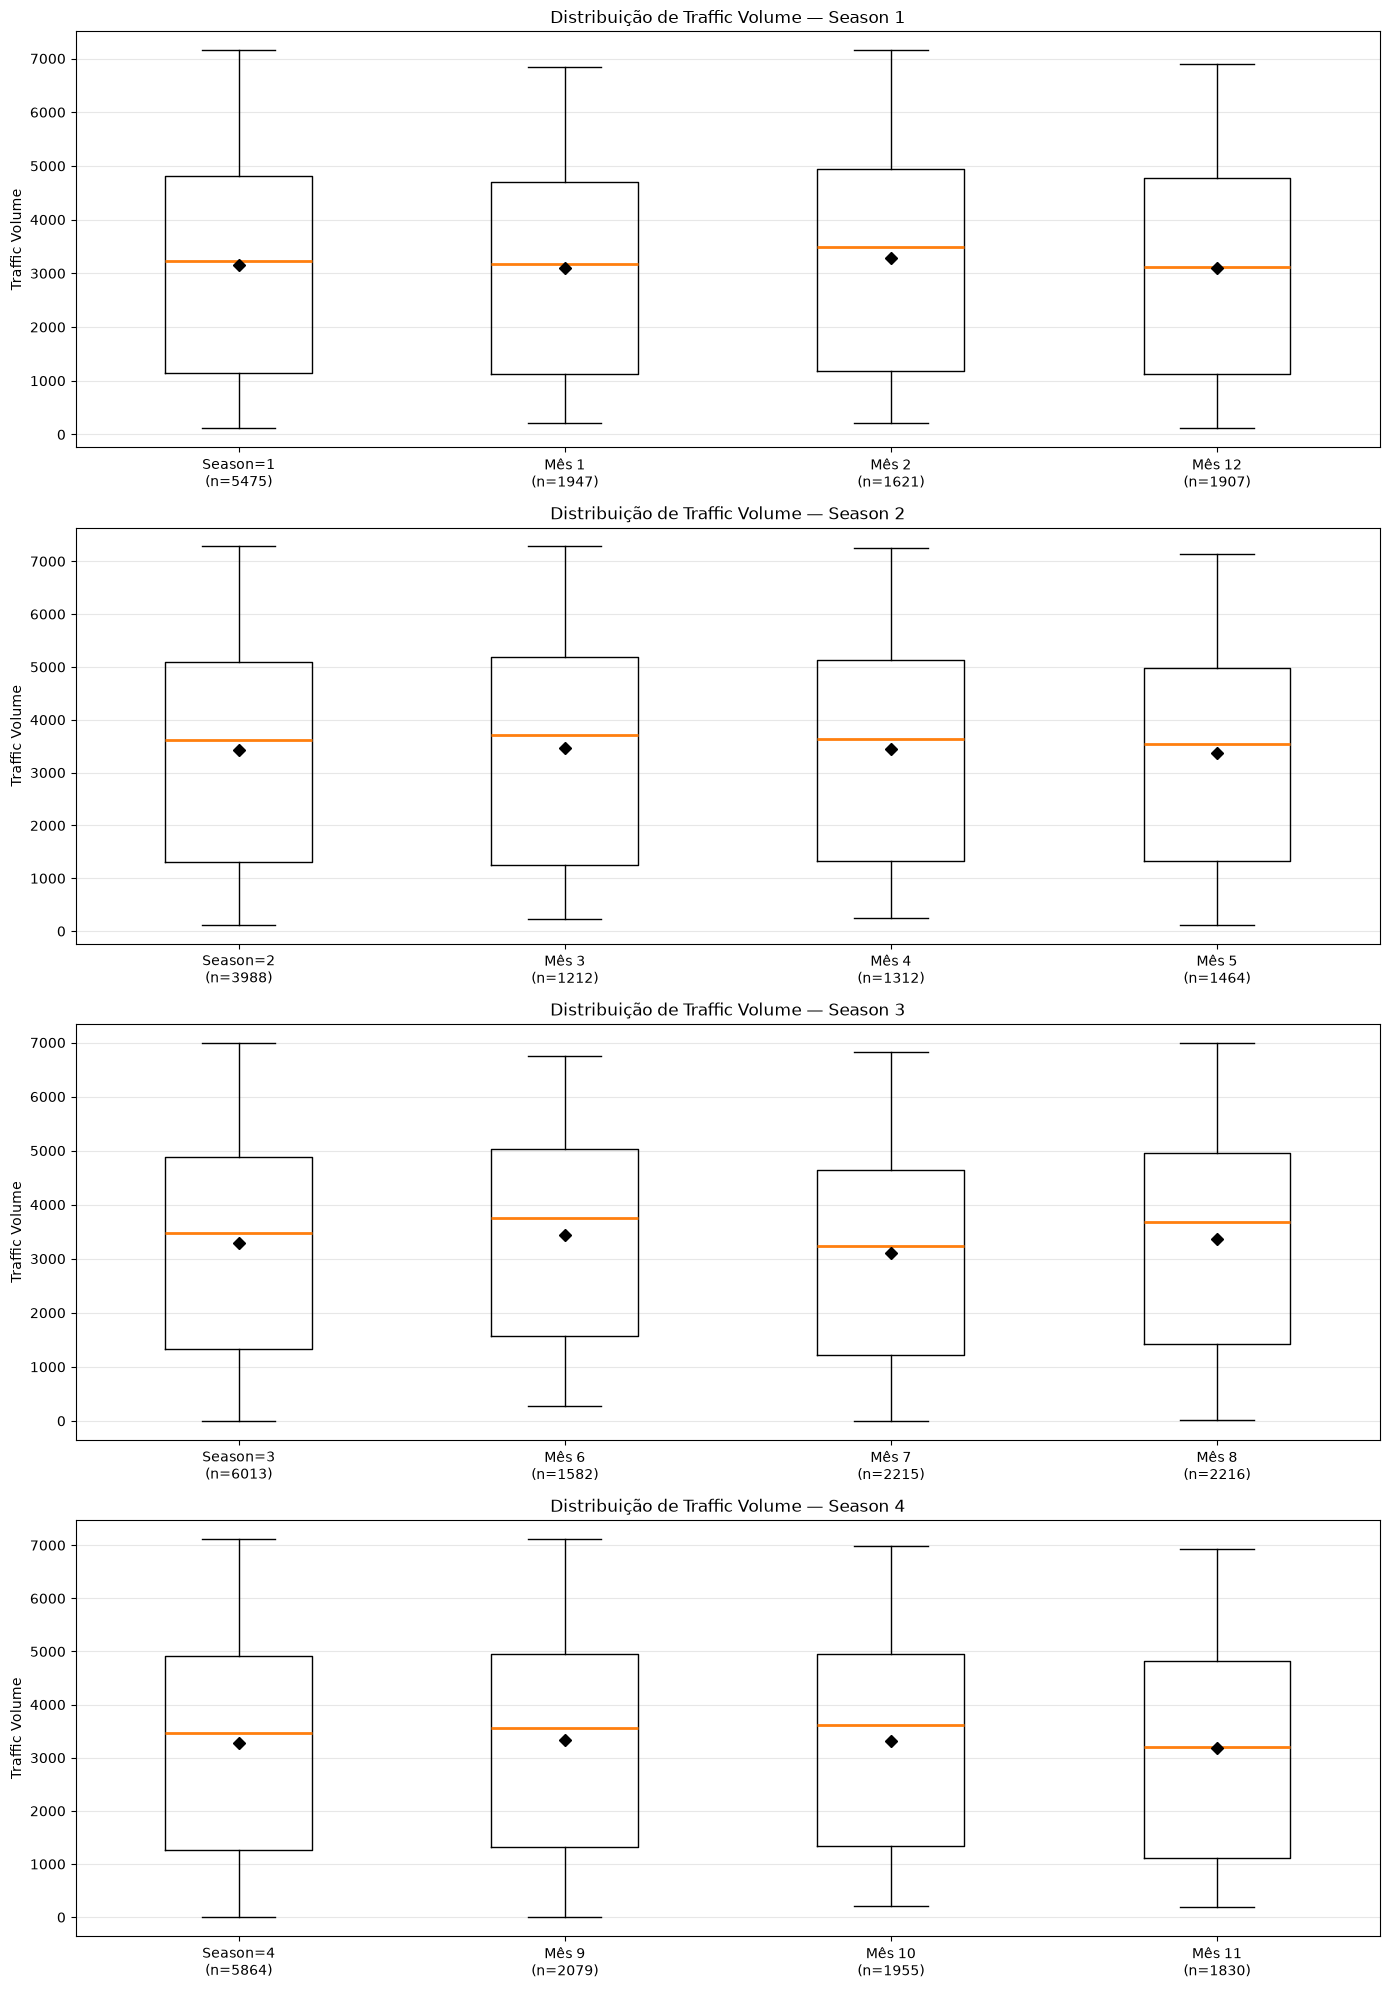

In [171]:
season_values = sorted(train_df['season'].dropna().unique())

fig, axes = plt.subplots(
    len(season_values),
    1,
    figsize=(14, 5 * len(season_values))
)

if len(season_values) == 1:
    axes = [axes]

for ax, season in zip(axes, season_values):

    df_season = train_df[
        train_df['season'] == season
    ]

    meses = sorted(
        df_season['mnth'].dropna().unique()
    )

    dados = []
    labels = []

    # ========================================================
    # Estação inteira
    # ========================================================

    valores_season = (
        df_season['traffic_volume']
        .dropna()
    )

    dados.append(valores_season.values)

    labels.append(
        f'Season={season}\n'
        f'(n={len(valores_season)})'
    )

    # ========================================================
    # Cada mês pertencente à estação
    # ========================================================

    for mes in meses:

        valores = df_season.loc[
            df_season['mnth'] == mes,
            'traffic_volume'
        ].dropna()

        dados.append(valores.values)

        labels.append(
            f'Mês {mes}\n'
            f'(n={len(valores)})'
        )

    # ========================================================
    # Boxplots
    # ========================================================

    ax.boxplot(
        dados,
        tick_labels=labels,
        whis=1.5,

        # Mostrar média
        showmeans=True,

        meanprops={
            'marker': 'D',
            'markerfacecolor': 'black',
            'markeredgecolor': 'black',
            'markersize': 6
        },

        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markeredgecolor': 'red',
            'markersize': 4,
            'alpha': 0.4
        },

        medianprops={
            'linewidth': 2
        }
    )

    ax.set_title(
        f'Distribuição de Traffic Volume — Season {season}'
    )

    ax.set_ylabel('Traffic Volume')

    ax.grid(
        axis='y',
        alpha=0.3
    )

plt.tight_layout()
plt.show()

In [172]:
resumo = (
    train_df
    .groupby(['season', 'mnth'])['traffic_volume']
    .agg(
        n='count',
        media='mean',
        desvio='std',
        q1=lambda x: x.quantile(0.25),
        mediana='median',
        q3=lambda x: x.quantile(0.75),
        minimo='min',
        maximo='max'
    )
)

display(resumo.round(2))

n    media   desvio       q1  mediana       q3  minimo  maximo
season mnth                                                                   
1      1     1947  3091.03  1903.81  1117.00   3169.0  4698.50     205    6838
       2     1621  3292.11  2001.45  1173.00   3496.0  4939.00     217    7154
       12    1907  3096.01  1907.83  1125.00   3125.0  4780.50     113    6893
2      3     1212  3464.40  2083.08  1251.75   3715.5  5192.25     223    7280
       4     1312  3445.12  2070.32  1334.75   3635.0  5124.75     251    7260
       5     1464  3370.61  1990.98  1323.00   3533.0  4977.75     123    7130
3      6     1582  3448.53  1921.49  1569.75   3746.5  5031.00     269    6747
       7     2215  3113.81  1867.64  1212.00   3230.0  4647.50       0    6827
       8     2216  3368.13  1936.87  1423.75   3678.5  4948.50       9    6997
4      9     2079  3328.89  1991.80  1329.50   3567.0  4946.50       1    7117
       10    1955  3315.04  1974.52  1348.50   3613.0  4948.50     210    6985
       11    1830  3177.35  1966.67  1112.25   3196.5  4813.50     186    6923

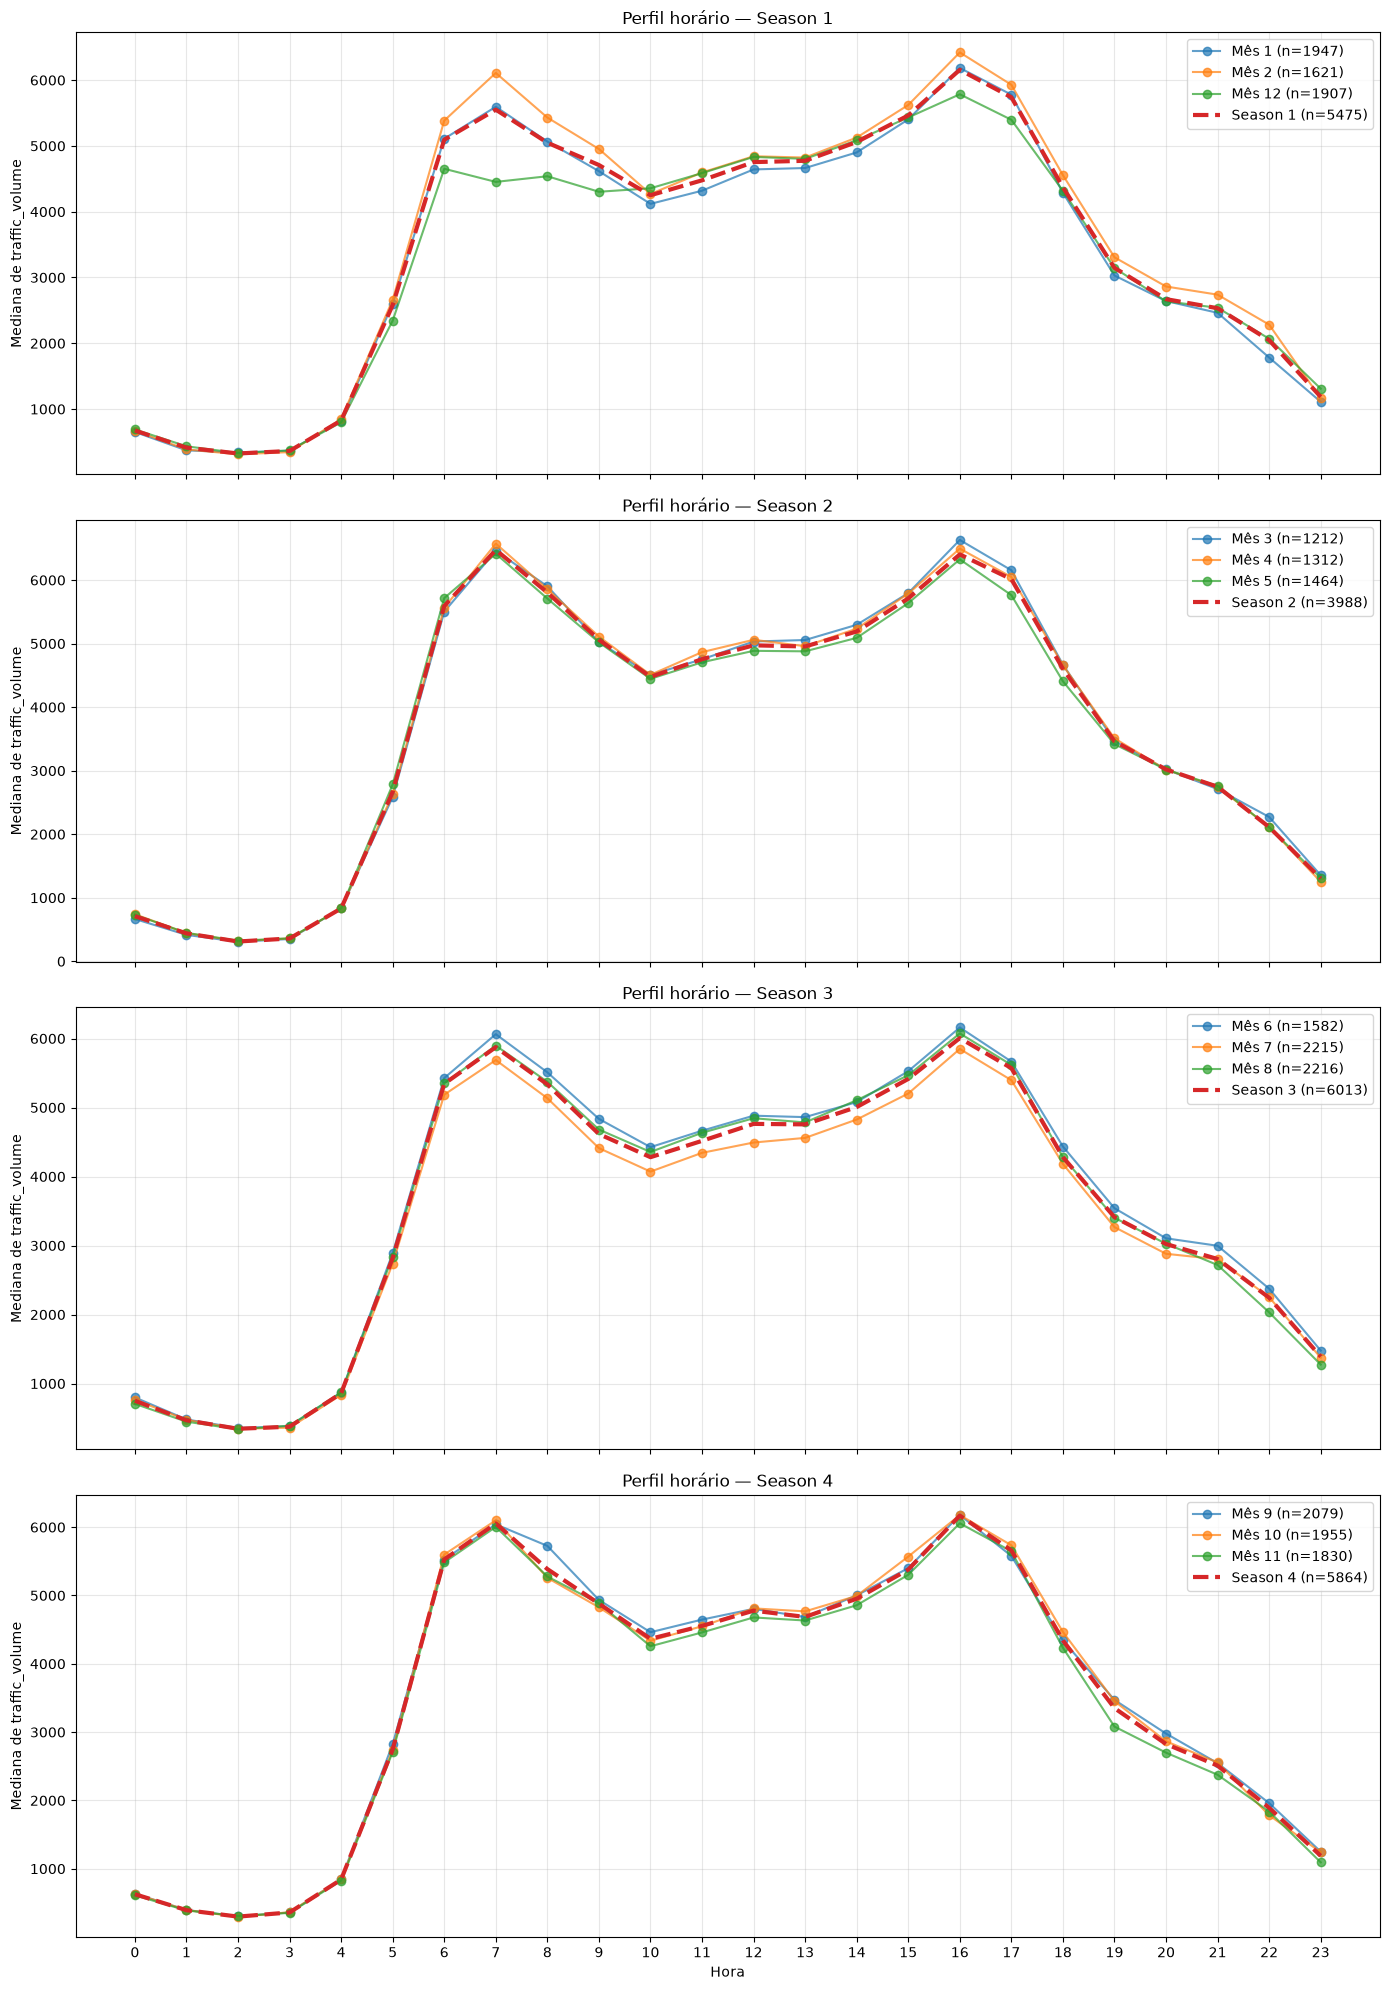

In [173]:
fig, axes = plt.subplots(
    len(season_values),
    1,
    figsize=(14, 5 * len(season_values)),
    sharex=True
)

if len(season_values) == 1:
    axes = [axes]

for ax, season in zip(axes, season_values):

    df_season = train_df[
        train_df['season'] == season
    ]

    meses = sorted(
        df_season['mnth'].unique()
    )

    # Cada mês
    for mes in meses:

        df_mes = df_season[
            df_season['mnth'] == mes
        ]

        perfil = (
            df_mes
            .groupby('hr')['traffic_volume']
            .median()
        )

        ax.plot(
            perfil.index,
            perfil.values,
            marker='o',
            alpha=0.7,
            label=f'Mês {mes} (n={len(df_mes)})'
        )

    # Estação agregada
    perfil_season = (
        df_season
        .groupby('hr')['traffic_volume']
        .median()
    )

    ax.plot(
        perfil_season.index,
        perfil_season.values,
        linestyle='--',
        linewidth=3,
        label=f'Season {season} (n={len(df_season)})'
    )

    ax.set_title(
        f'Perfil horário — Season {season}'
    )

    ax.set_ylabel(
        'Mediana de traffic_volume'
    )

    ax.set_xticks(range(24))
    ax.grid(alpha=0.3)
    ax.legend()

axes[-1].set_xlabel('Hora')

plt.tight_layout()
plt.show()

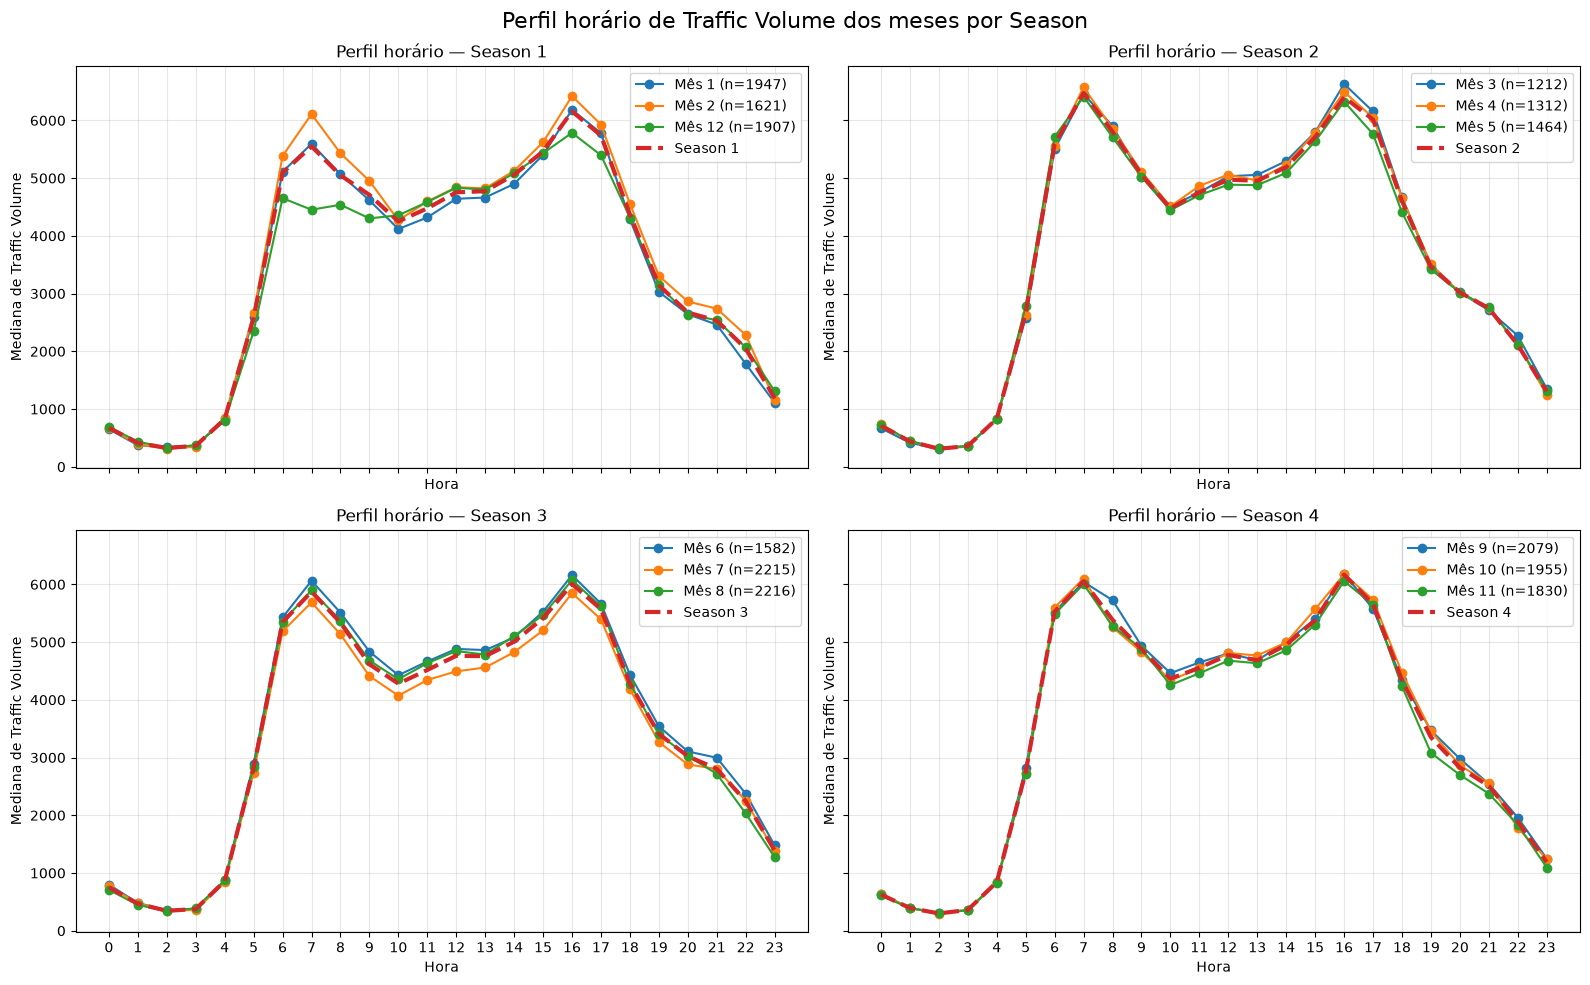

In [174]:
# ============================================================
# Perfil horário dos meses dentro de cada season
# ============================================================

season_values = sorted(train_df['season'].dropna().unique())

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 10),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, season in zip(axes, season_values):

    df_season = train_df[
        train_df['season'] == season
    ]

    meses = sorted(
        df_season['mnth'].dropna().unique()
    )

    # --------------------------------------------------------
    # Perfil de cada mês
    # --------------------------------------------------------

    for mes in meses:

        df_mes = df_season[
            df_season['mnth'] == mes
        ]

        perfil_mes = (
            df_mes
            .groupby('hr')['traffic_volume']
            .median()
        )

        ax.plot(
            perfil_mes.index,
            perfil_mes.values,
            marker='o',
            linewidth=1.5,
            label=f'Mês {mes} (n={len(df_mes)})'
        )

    # --------------------------------------------------------
    # Perfil agregado da season
    # --------------------------------------------------------

    perfil_season = (
        df_season
        .groupby('hr')['traffic_volume']
        .median()
    )

    ax.plot(
        perfil_season.index,
        perfil_season.values,
        linestyle='--',
        linewidth=3,
        label=f'Season {season}'
    )

    ax.set_title(
        f'Perfil horário — Season {season}'
    )

    ax.set_xlabel('Hora')
    ax.set_ylabel('Mediana de Traffic Volume')

    ax.set_xticks(range(24))

    ax.grid(
        alpha=0.3
    )

    ax.legend()

plt.suptitle(
    'Perfil horário de Traffic Volume dos meses por Season',
    fontsize=16
)

plt.tight_layout()
plt.show()

In [175]:
resultados = []

for season in sorted(train_df['season'].unique()):

    df_season = train_df[
        train_df['season'] == season
    ]

    perfil_season = (
        df_season
        .groupby('hr')['traffic_volume']
        .median()
    )

    for mes in sorted(df_season['mnth'].unique()):

        perfil_mes = (
            df_season[
                df_season['mnth'] == mes
            ]
            .groupby('hr')['traffic_volume']
            .median()
        )

        diferenca = perfil_mes - perfil_season

        resultados.append({
            'season': season,
            'mnth': mes,
            'MAE_perfil': diferenca.abs().mean(),
            'RMSE_perfil': np.sqrt((diferenca ** 2).mean()),
            'desvio_maximo': diferenca.abs().max()
        })

comparacao_perfis = pd.DataFrame(resultados)

display(
    comparacao_perfis.round(2)
)

,season,mnth,MAE_perfil,RMSE_perfil,desvio_maximo
0,1,1,71.10,94.27,264.0
1,1,2,149.77,200.55,558.0
2,1,12,171.21,302.12,1098.0
3,2,3,61.29,83.22,227.5
4,2,4,39.54,51.91,111.0
5,2,5,62.54,88.27,251.0
6,3,6,106.42,121.90,219.5
7,3,7,119.65,146.90,270.0
8,3,8,52.10,71.18,212.0
9,4,9,54.83,91.27,339.5


#### Representação da hora

Como

In [176]:
# ============================================================
# Representação cíclica da hora
# ============================================================

train_df['hr_sin'] = np.sin(
    2 * np.pi * train_df['hr'] / 24
)

train_df['hr_cos'] = np.cos(
    2 * np.pi * train_df['hr'] / 24
)

# ============================================================
# Representação cíclica do mês
# ============================================================

# -1 é opcional, mas faz janeiro começar no ângulo 0
train_df['mnth_sin'] = np.sin(
    2 * np.pi * (train_df['mnth'] - 1) / 12
)

train_df['mnth_cos'] = np.cos(
    2 * np.pi * (train_df['mnth'] - 1) / 12
)

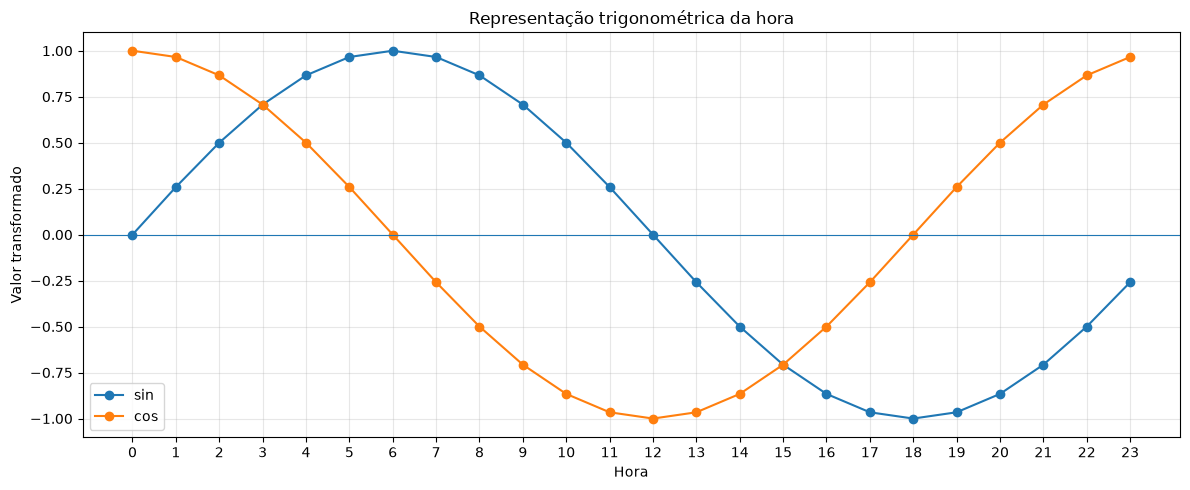

In [177]:
horas = np.arange(24)

hr_sin = np.sin(2 * np.pi * horas / 24)
hr_cos = np.cos(2 * np.pi * horas / 24)

plt.figure(figsize=(12, 5))

plt.plot(
    horas,
    hr_sin,
    marker='o',
    label='sin'
)

plt.plot(
    horas,
    hr_cos,
    marker='o',
    label='cos'
)

plt.axhline(0, linewidth=0.8)

plt.xticks(horas)

plt.xlabel('Hora')
plt.ylabel('Valor transformado')

plt.title(
    'Representação trigonométrica da hora'
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

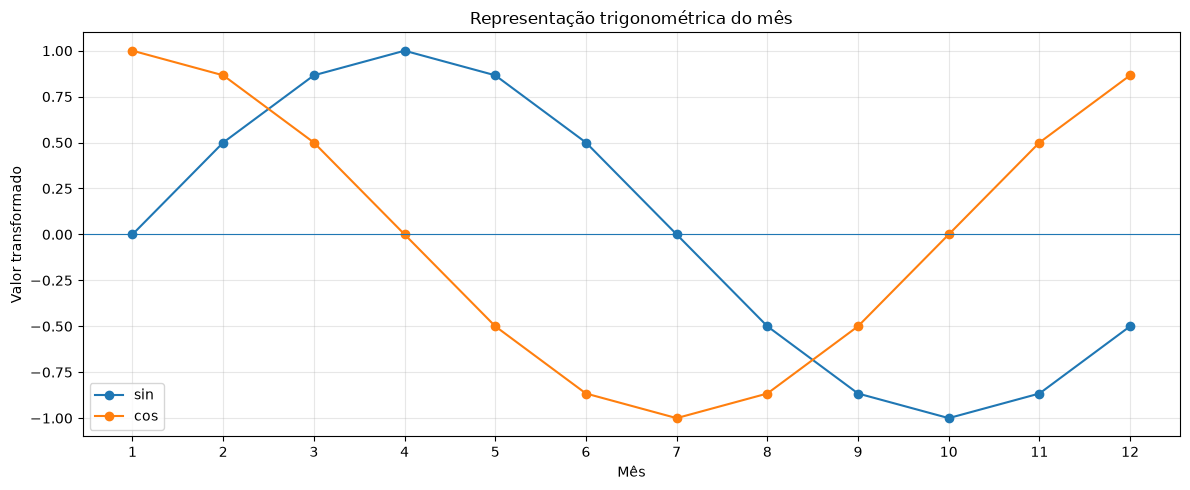

In [178]:
meses = np.arange(1, 13)

mnth_sin = np.sin(
    2 * np.pi * (meses - 1) / 12
)

mnth_cos = np.cos(
    2 * np.pi * (meses - 1) / 12
)

plt.figure(figsize=(12, 5))

plt.plot(
    meses,
    mnth_sin,
    marker='o',
    label='sin'
)

plt.plot(
    meses,
    mnth_cos,
    marker='o',
    label='cos'
)

plt.axhline(0, linewidth=0.8)

plt.xticks(meses)

plt.xlabel('Mês')
plt.ylabel('Valor transformado')

plt.title(
    'Representação trigonométrica do mês'
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,hr,media,mediana,q1,q3,n
0,0,869.29,695.5,587.75,1129.25,928
1,1,540.46,434.0,363.00,696.00,900
2,2,407.72,327.0,274.00,538.00,893
3,3,381.23,366.0,337.00,407.00,886
4,4,725.98,837.5,481.25,881.75,906
5,5,2131.81,2709.5,797.75,2867.50,880
6,6,4181.98,5400.0,1435.00,5704.00,905
7,7,4751.77,5957.0,2089.75,6432.50,880
8,8,4554.19,5354.0,2964.50,5847.50,887
9,9,4365.40,4759.0,3637.00,5124.00,857


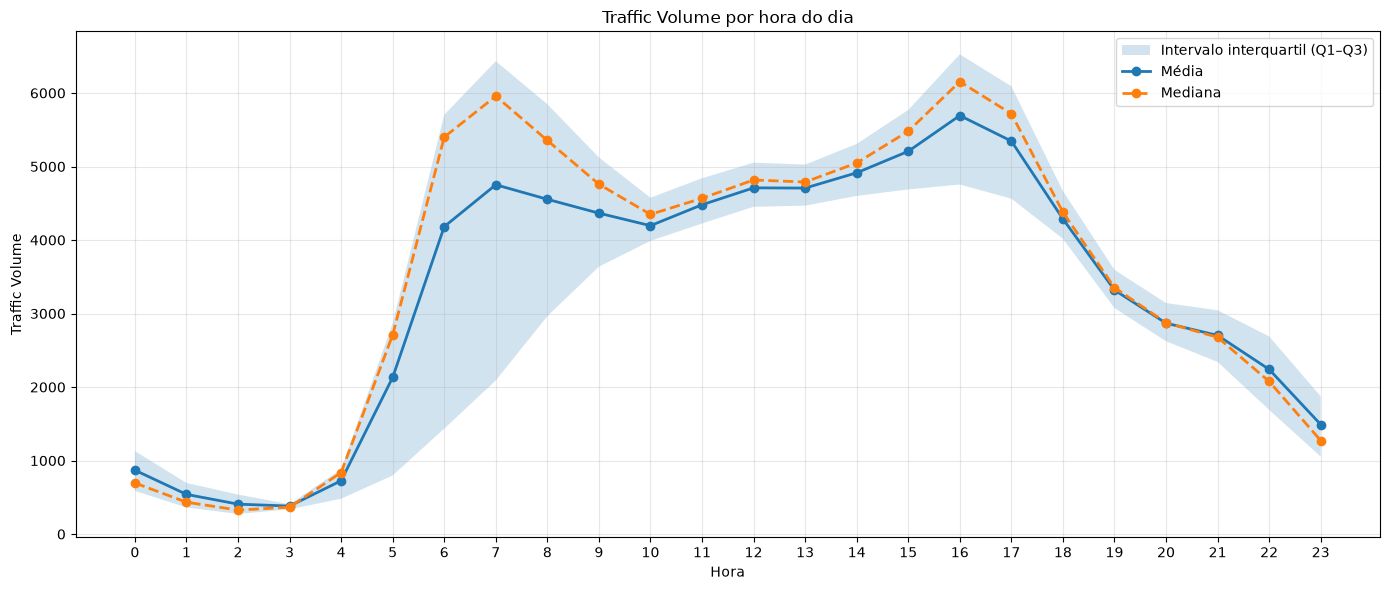

In [179]:
# ============================================================
# Estatísticas de traffic_volume por hora
# ============================================================

perfil_hr = (
    train_df
    .groupby('hr')['traffic_volume']
    .agg(
        media='mean',
        mediana='median',
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        n='count'
    )
    .reset_index()
)

display(perfil_hr.round(2))


# ============================================================
# Perfil horário
# ============================================================

plt.figure(figsize=(14, 6))

plt.fill_between(
    perfil_hr['hr'],
    perfil_hr['q1'],
    perfil_hr['q3'],
    alpha=0.2,
    label='Intervalo interquartil (Q1–Q3)'
)

plt.plot(
    perfil_hr['hr'],
    perfil_hr['media'],
    marker='o',
    linewidth=2,
    label='Média'
)

plt.plot(
    perfil_hr['hr'],
    perfil_hr['mediana'],
    marker='o',
    linestyle='--',
    linewidth=2,
    label='Mediana'
)

plt.xticks(range(24))
plt.xlabel('Hora')
plt.ylabel('Traffic Volume')

plt.title('Traffic Volume por hora do dia')

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

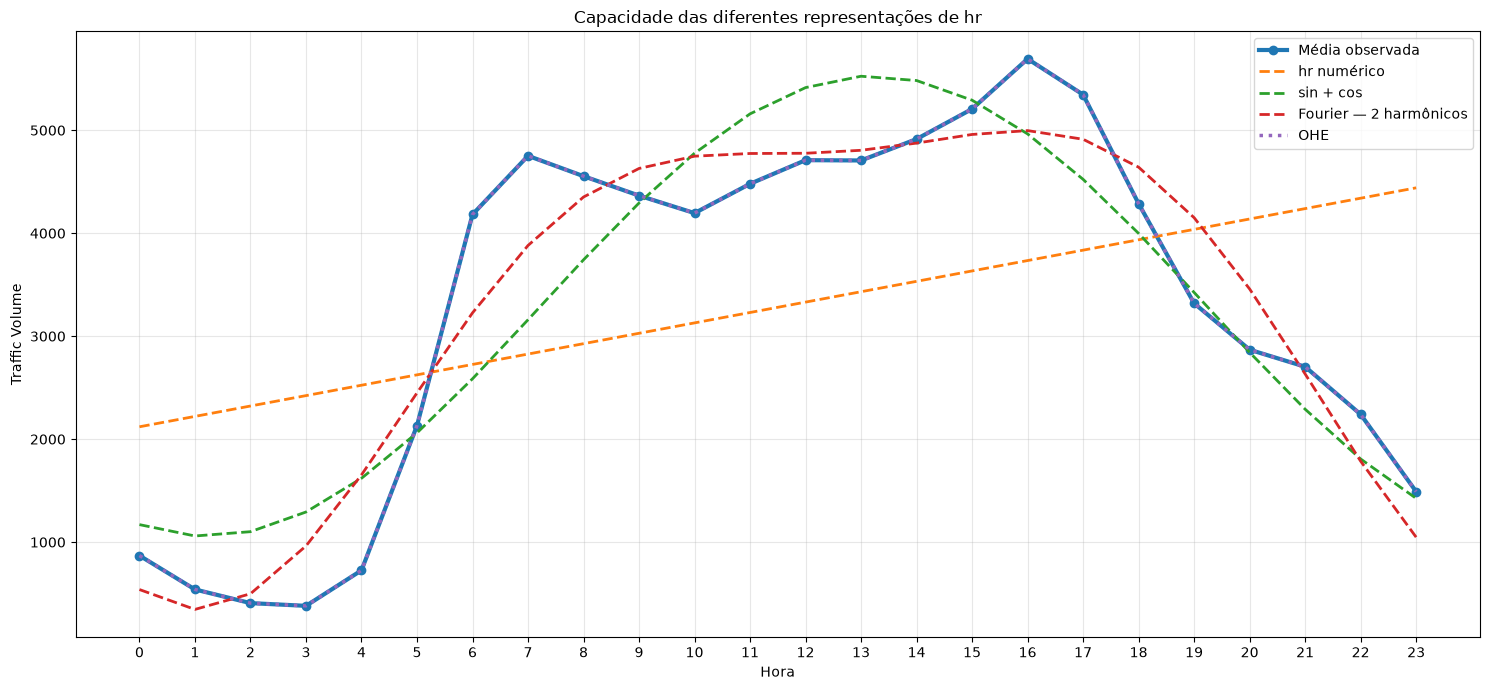

In [180]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

# ============================================================
# Dados
# ============================================================

X_hr = train_df[['hr']].copy()
y = train_df['traffic_volume'].values

horas = np.arange(24)

# Média observada por hora
media_real = (
    train_df
    .groupby('hr')['traffic_volume']
    .mean()
    .reindex(horas)
)


# ============================================================
# 1. Hora tratada diretamente como variável numérica
# ============================================================

modelo_linear = LinearRegression()

modelo_linear.fit(
    X_hr[['hr']],
    y
)

pred_linear = modelo_linear.predict(
    pd.DataFrame({'hr': horas})
)


# ============================================================
# 2. Seno + cosseno
# ============================================================

X_ciclico = np.column_stack([
    np.sin(2 * np.pi * train_df['hr'] / 24),
    np.cos(2 * np.pi * train_df['hr'] / 24)
])

horas_ciclico = np.column_stack([
    np.sin(2 * np.pi * horas / 24),
    np.cos(2 * np.pi * horas / 24)
])

modelo_ciclico = LinearRegression()

modelo_ciclico.fit(
    X_ciclico,
    y
)

pred_ciclico = modelo_ciclico.predict(
    horas_ciclico
)


# ============================================================
# 3. Fourier com dois harmônicos
# ============================================================

X_fourier2 = np.column_stack([
    np.sin(2 * np.pi * train_df['hr'] / 24),
    np.cos(2 * np.pi * train_df['hr'] / 24),

    np.sin(4 * np.pi * train_df['hr'] / 24),
    np.cos(4 * np.pi * train_df['hr'] / 24)
])

horas_fourier2 = np.column_stack([
    np.sin(2 * np.pi * horas / 24),
    np.cos(2 * np.pi * horas / 24),

    np.sin(4 * np.pi * horas / 24),
    np.cos(4 * np.pi * horas / 24)
])

modelo_fourier2 = LinearRegression()

modelo_fourier2.fit(
    X_fourier2,
    y
)

pred_fourier2 = modelo_fourier2.predict(
    horas_fourier2
)


# ============================================================
# 4. OHE
# ============================================================

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False
)

X_ohe = encoder.fit_transform(
    train_df[['hr']]
)

horas_ohe = encoder.transform(
    pd.DataFrame({'hr': horas})
)

modelo_ohe = LinearRegression()

modelo_ohe.fit(
    X_ohe,
    y
)

pred_ohe = modelo_ohe.predict(
    horas_ohe
)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(15, 7))

plt.plot(
    horas,
    media_real.values,
    marker='o',
    linewidth=3,
    label='Média observada'
)

plt.plot(
    horas,
    pred_linear,
    linestyle='--',
    linewidth=2,
    label='hr numérico'
)

plt.plot(
    horas,
    pred_ciclico,
    linestyle='--',
    linewidth=2,
    label='sin + cos'
)

plt.plot(
    horas,
    pred_fourier2,
    linestyle='--',
    linewidth=2,
    label='Fourier — 2 harmônicos'
)

plt.plot(
    horas,
    pred_ohe,
    linestyle=':',
    linewidth=2.5,
    label='OHE'
)

plt.xticks(range(24))

plt.xlabel('Hora')
plt.ylabel('Traffic Volume')

plt.title(
    'Capacidade das diferentes representações de hr'
)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [181]:
from sklearn.metrics import r2_score

# ============================================================
# Predições para TODAS as observações do treino
# ============================================================

pred_train_linear = modelo_linear.predict(
    train_df[['hr']]
)

pred_train_ciclico = modelo_ciclico.predict(
    X_ciclico
)

pred_train_fourier2 = modelo_fourier2.predict(
    X_fourier2
)

pred_train_ohe = modelo_ohe.predict(
    X_ohe
)


# ============================================================
# Comparação
# ============================================================

resultados = []

representacoes = {
    'hr numérico': {
        'dimensoes': 1,
        'pred_perfil': pred_linear,
        'pred_train': pred_train_linear
    },

    'sin + cos': {
        'dimensoes': 2,
        'pred_perfil': pred_ciclico,
        'pred_train': pred_train_ciclico
    },

    'Fourier 2': {
        'dimensoes': 4,
        'pred_perfil': pred_fourier2,
        'pred_train': pred_train_fourier2
    },

    'OHE': {
        'dimensoes': 23,
        'pred_perfil': pred_ohe,
        'pred_train': pred_train_ohe
    }
}


for nome, info in representacoes.items():

    r2_perfil = r2_score(
        media_real.values,
        info['pred_perfil']
    )

    r2_train = r2_score(
        y,
        info['pred_train']
    )

    resultados.append({
        'representacao': nome,
        'dimensoes': info['dimensoes'],
        'R2_perfil': r2_perfil,
        'R2_observacoes': r2_train
    })


comparacao_r2 = pd.DataFrame(resultados)

display(
    comparacao_r2.round(4)
)

,representacao,dimensoes,R2_perfil,R2_observacoes
0,hr numérico,1,0.1636,0.1276
1,sin + cos,2,0.8313,0.6512
2,Fourier 2,4,0.9176,0.7185
3,OHE,23,1.0000,0.7829


In [182]:
train_df

,instant,date,season,yr,mnth,hr,holiday,weekday,workingday,weather,weather_desc,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hr_sin,hr_cos,mnth_sin,mnth_cos
0,1,2015-06-11,3,0,6,20,0,4,1,Rain,light rain,14.44,0.0,0.0,92,2886,-0.866025,5.000000e-01,0.5,-0.866025
1,2,2015-06-12,3,0,6,18,0,5,1,Clear,Sky is Clear,24.39,0.0,0.0,0,4380,-1.000000,-1.836970e-16,0.5,-0.866025
2,3,2015-06-12,3,0,6,20,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3095,-0.866025,5.000000e-01,0.5,-0.866025
3,4,2015-06-12,3,0,6,21,0,5,1,Clear,sky is clear,18.91,0.0,0.0,8,3299,-0.707107,7.071068e-01,0.5,-0.866025
4,5,2015-06-13,3,0,6,21,0,6,0,Clouds,broken clouds,21.69,0.0,0.0,76,3040,-0.707107,7.071068e-01,0.5,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21336,21337,2018-02-19,1,3,2,18,1,1,0,Mist,mist,-6.07,0.0,0.0,90,2659,-1.000000,-1.836970e-16,0.5,0.866025
21337,21338,2018-02-19,1,3,2,19,1,1,0,Mist,mist,-6.43,0.0,0.0,90,2087,-0.965926,2.588190e-01,0.5,0.866025
21338,21339,2018-02-19,1,3,2,20,1,1,0,Mist,mist,-6.57,0.0,0.0,90,1821,-0.866025,5.000000e-01,0.5,0.866025
21339,21340,2018-02-19,1,3,2,21,1,1,0,Mist,mist,-6.86,0.0,0.0,90,1593,-0.707107,7.071068e-01,0.5,0.866025


### Questão 3

> Question:
> 
> How did the visualization help in understanding the data? Which questions were answered and what hypothesis are left to be tested?
> 
> Have you decided to remove some feature from the dataset? Why?

As visualizações mostraram que o volume de tráfego possui uma estrutura temporal forte e não linear. A variável `hr` separa claramente a madrugada, os períodos de pico e o restante do dia; por isso, tratá-la como número contínuo imporia uma relação inadequada. A comparação entre as representações indicou o uso de *one-hot encoding* para `hr`, pois ele reproduz o perfil horário com maior flexibilidade. Os gráficos também mostraram que o efeito das variáveis meteorológicas é menor quando analisado isoladamente, mas não necessariamente irrelevante quando combinado com horário e tipo de dia.

Foram tomadas as seguintes decisões:

- remover `instant`, pois é apenas um identificador;
- usar `date` somente para ordenação e divisão temporal, sem fornecê-la diretamente ao modelo;
- remover `weather_desc` e manter `weather`, evitando redundância, categorias raras e dimensionalidade excessiva;
- remover a leitura fisicamente implausível de `rain_1h = 9831.3` somente do treinamento;
- padronizar `temp`, `rain_1h`, `snow_1h` e `clouds_all` com parâmetros calculados exclusivamente no treino;
- substituir `weekday`, `holiday` e `workingday` pela variável `day_type`, com as categorias `workingday`, `saturday`, `sunday` e `holiday`;
- permitir a comparação entre `mnth` e `season`, sem utilizá-las simultaneamente; a configuração padrão mantém `mnth`, que preserva maior granularidade;
- aplicar *one-hot encoding* às variáveis categóricas, utilizando no teste exatamente as categorias aprendidas no treino.

Ainda devem ser testadas hipóteses sobre interações — principalmente `hr × day_type` — e sobre relações não lineares. Essas limitações serão investigadas pelos modelos polinomiais e pelos diagnósticos dos resíduos.

----
### **Preprocessing**
> (1.0 point) Now that you have a deeper insight about the problem, let's preprocess
the raw data with the necessary transformations and turn the data into an array,
ready to be fed into a model.
>
> Create a function `preprocess_data` and make all required transformation, the
output must be a tuple (X, y) of numpy arrays, where X has shape (n_samples, n_features)
and y is a column array of shape (n_samples,).
>
> Note that the distributions on the features in the test set may not coincide
with the ones in the train set, your preprocessing must take that into account
without peeking at test samples.

O pré-processamento abaixo implementa as decisões da análise exploratória. Ele é ajustado exclusivamente com o conjunto de treinamento e reutiliza no teste as mesmas médias, desvios, categorias e ordem das colunas. As opções `day_representation` e `seasonal_representation` tornam reproduzíveis as alternativas discutidas na EDA; a configuração principal usa `day_type` e `mnth`.

In [183]:
NUMERIC_FEATURES = ['temp', 'rain_1h', 'snow_1h', 'clouds_all']


def _add_day_type(data: pd.DataFrame) -> pd.DataFrame:
    """Cria a representação compacta proposta na EDA."""
    data = data.copy()
    data['day_type'] = 'workingday'
    data.loc[(data['holiday'] == 0) & (data['weekday'] == 6), 'day_type'] = 'saturday'
    data.loc[(data['holiday'] == 0) & (data['weekday'] == 0), 'day_type'] = 'sunday'
    data.loc[data['holiday'] == 1, 'day_type'] = 'holiday'
    return data


def fit_preprocessor(
    df: pd.DataFrame,
    day_representation: str = 'day_type',
    seasonal_representation: str = 'mnth',
) -> dict:
    """Aprende parâmetros apenas no treino, sem consultar o conjunto de teste."""
    if day_representation not in {'day_type', 'weekday_workingday'}:
        raise ValueError("day_representation deve ser 'day_type' ou 'weekday_workingday'")
    if seasonal_representation not in {'mnth', 'season'}:
        raise ValueError("seasonal_representation deve ser 'mnth' ou 'season'")

    data = _add_day_type(df) if day_representation == 'day_type' else df.copy()
    categorical = ['hr', seasonal_representation, 'yr', 'weather']
    binary = []
    if day_representation == 'day_type':
        categorical.append('day_type')
    else:
        categorical.append('weekday')
        binary.append('workingday')  # holiday é redundante com weekday + workingday

    means = data[NUMERIC_FEATURES].mean()
    stds = data[NUMERIC_FEATURES].std(ddof=0).replace(0, 1.0)
    categories = {col: sorted(data[col].dropna().unique()) for col in categorical}

    return {
        'means': means,
        'stds': stds,
        'categories': categories,
        'categorical_features': categorical,
        'binary_features': binary,
        'day_representation': day_representation,
        'seasonal_representation': seasonal_representation,
    }


def preprocess_data(
    df: pd.DataFrame,
    preprocessor: dict,
) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """Transforma um DataFrame sem alterar o objeto recebido."""
    data = df.copy()
    if preprocessor['day_representation'] == 'day_type':
        data = _add_day_type(data)

    X_num = (data[NUMERIC_FEATURES] - preprocessor['means']) / preprocessor['stds']
    X_bin = data[preprocessor['binary_features']].astype(float)
    X_cat = data[preprocessor['categorical_features']].copy()

    for col in preprocessor['categorical_features']:
        X_cat[col] = pd.Categorical(X_cat[col], categories=preprocessor['categories'][col])

    X_cat = pd.get_dummies(
        X_cat,
        columns=preprocessor['categorical_features'],
        drop_first=True,
        dtype=float,
    )

    X_df = pd.concat([X_num, X_bin, X_cat], axis=1)
    X = X_df.to_numpy(dtype=np.float64)
    y = data['traffic_volume'].to_numpy(dtype=np.float64)
    return X, y


# O valor absurdo é removido somente do treino. Nenhum limiar é aprendido no teste.
train_df_clean = train_df.loc[train_df['rain_1h'] != 9831.3].copy().reset_index(drop=True)

preprocessor = fit_preprocessor(
    train_df_clean,
    day_representation='day_type',
    seasonal_representation='mnth',
)
X, y = preprocess_data(train_df_clean, preprocessor)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Representação do dia:', preprocessor['day_representation'])
print('Representação sazonal:', preprocessor['seasonal_representation'])


X shape: (21340, 53)
y shape: (21340,)
Representação do dia: day_type
Representação sazonal: mnth


---

## **Linear Regression**

Linear regression is a simple model that assumes a linear relationship between
the observed features and the target.
Specifically, given an observation $(x_1, x_2, \dots, x_n)$, we assume there exist
a set of weights $\beta_0, \beta_1, \beta_2, \dots, \beta_n$ such that

$$y \approx \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n.$$

Each weight $\beta_i$ measures the marginal contribution of $x_i$ to the
prediction while keeping other variables fixed.
The model assumes additive effects, meaning the influence of multiple variables
is the sum of their individual contributions unless interaction terms are
explicitly included.

For example, if raining decreases the traffic volume, but the morning rush hour
increases it, a rainy rush hour contribution is no different than the contribution
of rainy plus the contribution of the rush hour.

We can estimate the weights $\beta_i$ by measuring a discrepancy score between
predicted values $\hat{y}$ obtained with some weight $\beta$ and the ground-truth
value $y$, and minimizing this score.

A natural way to achieve this is by defining a distance between targets that is
differentiable. However, choosing a distance that is statistical relevant is not
trivial. Instead, we could measure what is the probability that, when given
a sample $x$ and a current weight $\beta$, the ground-truth $y$ is observed, *i.e.*

$$p(y \mid x, \beta).$$

This measures what is the probability of the ground-truth given that the model
with weights $\beta$ is the true estimator.

If we tweak the weights $\beta$ so that the probability of all ground-truths is
maximized, we obtain a well-fit model.
This is achieved by the likelihood function, under the assumption of independent
samples in the dataset.

$$\mathcal{L}(\beta) = \prod_{i=1}^n p(y^i \mid x^i, \beta).$$

Indicating that an estimator $\beta$ is only good if the ground-truth probabilities
are high across all the samples. As this criteria can be very small due to the
multiplication of small quantities, a common trick is to use the log likelihood
function instead, using the log properties,

$$\log \mathcal{L}(\beta) = \sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
and then minimizing $-\log \mathcal{L}(\beta)$.

This method is called Maximum Likelihood Estimation (MLE) and it is a very commonly
used estimator in Machine Learning, as we are going to see.

### **Gaussian assumption**
We cannot directly measure $p(y \mid x, \beta)$ at the moment, as we do not have
a probability distribution that links $y$ with $x$ and $\beta$ yet, but a
deterministic relationship (linear).

To introduce this probabilistic aspect, we can suppose that the approximation
between the ground-truth $y$ and the linear term $\hat{y} = \beta_0 + \beta_1 x_1 + \dots$
is only wrong by an unpredictable "error" $\epsilon$, also called a *residual*.
A common way of introducing this error is by supposing that $\epsilon$ comes from
a zero-centered normal (or Gaussian) distribution,
*i.e.* $\epsilon \sim \mathcal{N}(0, \sigma^2)$.

The relationship between $y$, $x$ and $\beta$ are now intermediated by $\epsilon$,

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon.$$

This makes $y$ to be a random variable centered at our linear predicition, deviated
by a random quantity, with fixed standard deviation $\sigma$ (homoscedastic).
This assumption is called **Gaussian assumption**, and has interesting properties
that intersect with the Ordinary Least Squares method, including the criterion.

With this assumption, we can measure $p(y \mid x, \beta)$ directly using the
Normal probability distribution function

$$p(y \mid x, \beta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(- \frac{(y - x^T\beta)^2}{2\sigma^2}\right),$$

$$\log p(y \mid x, \beta) =  - \frac{(y - x^T\beta)^2}{2\sigma^2} - \log(\sqrt{2\pi\sigma^2}).$$

Thus, minimizing $-\log \mathcal{L}(\beta)$, yield to

$$-\log \mathcal{L}(\beta) \propto \sum_{i=1}^n (y^i - {x^i}^T\beta)^2 = \sum_{i=1}^n (y^i - \hat{y}^i)^2 $$

Which is equivalent to the Mean Squared Error (MSE) criterion.

### **Implementation**

> (0.5 points) Under the statistical lens of Linear Regression, we have also
derived the same loss function as ordinary least squares method. Now it's time to
implement the `fit` method using **gradient descent** without using any machine
learning library.
>
>
> Also, complete the following metric functions with their implementations and run
your model for different learning rates

In [184]:
def mse(
    y_true: NDArray[np.float64],
    y_pred: NDArray[np.float64]
) -> float:
    return float(np.mean((y_true - y_pred) ** 2))


def r2_score(
    y_true: NDArray[np.float64],
    y_pred: NDArray[np.float64]
) -> float:
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))

    if ss_tot == 0.0:
        return 0.0

    return float(1.0 - (ss_res / ss_tot))


def mae(
    y_true: NDArray[np.float64],
    y_pred: NDArray[np.float64]
) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))


class LinearRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None

    def fit(
        self,
        X: NDArray[np.float64],
        y: NDArray[np.float64]
    ) -> None:

        n_samples, n_features = X.shape

        weights = np.zeros(
            n_features,
            dtype=np.float64
        )

        bias = 0.0

        for _ in range(self.n_iterations):

            # Evita que warnings de overflow interrompam
            # visualmente a execução durante testes de LRs altos
            with np.errstate(
                over="ignore",
                invalid="ignore"
            ):
                # Predição atual
                y_pred = X @ weights + bias

                # Erro
                error = y_pred - y

                # Gradientes do MSE
                dw = (
                    (2.0 / n_samples)
                    * (X.T @ error)
                )

                db = (
                    (2.0 / n_samples)
                    * np.sum(error)
                )

            # Detecta divergência numérica
            if (
                not np.isfinite(y_pred).all()
                or not np.isfinite(dw).all()
                or not np.isfinite(db)
            ):
                weights = np.full(
                    n_features,
                    np.nan,
                    dtype=np.float64
                )

                bias = np.nan
                break

            # Gradient Descent
            weights -= self.learning_rate * dw
            bias -= self.learning_rate * db

        self.weights = weights
        self.bias = float(bias)

    def predict(
        self,
        X: NDArray[np.float64]
    ) -> NDArray[np.float64]:

        assert (
            self.weights is not None
            and self.bias is not None
        ), "Model is not trained yet"

        return X @ self.weights + self.bias

In [185]:
def plot_results(lrs: list[float], performances: dict[str, list[float]]) -> None:
    n_metrics = len(performances)

    fig, ax = plt.subplots(figsize=(5 * n_metrics, 5), ncols=n_metrics)

    for i, (metric_name, metric_values) in enumerate(performances.items()):
        ax[i].plot(lrs, metric_values, marker="o")
        ax[i].set_xlabel("Learning Rate")
        ax[i].set_title(metric_name)
        ax[i].grid()

        ax[i].set_xscale("log")

    plt.tight_layout()
    plt.show()


lr=0.000100 | MSE=8258239.96 | R²=-1.1405 | MAE=2388.21
lr=0.000316 | MSE=4197193.52 | R²=-0.0879 | MAE=1782.47
lr=0.001000 | MSE=3156330.79 | R²=0.1819 | MAE=1540.43
lr=0.003162 | MSE=2452014.81 | R²=0.3645 | MAE=1343.57
lr=0.010000 | MSE=1372950.43 | R²=0.6441 | MAE=963.06
lr=0.031623 | MSE=833878.90 | R²=0.7839 | MAE=677.32
lr=0.100000 | MSE=735049.53 | R²=0.8095 | MAE=623.85
lr=0.316228 | MSE=640308.37 | R²=0.8340 | MAE=592.92
lr=1.000000 -> divergiu


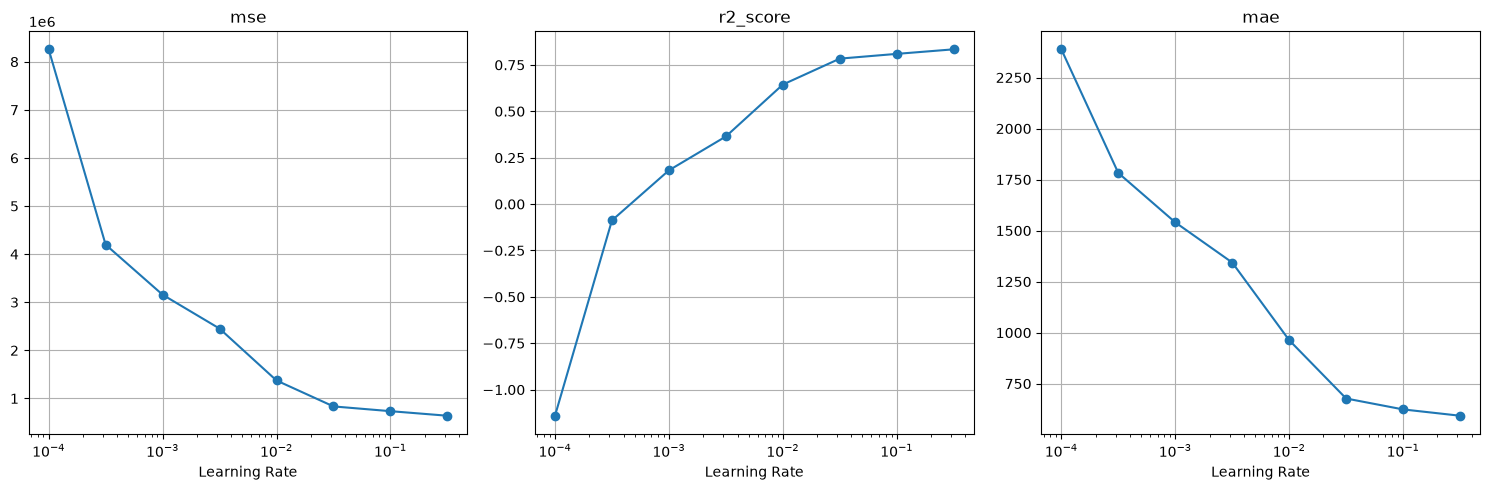


Best configuration:
Learning rate: 0.316228
MSE: 640308.37
R²: 0.8340
MAE: 592.92

Diverged learning rates: [1.0]


In [186]:
# Reutiliza o pré-processador já ajustado exclusivamente no treino
X, y = preprocess_data(
    train_df_clean,
    preprocessor
)

# Testa learning rates entre 10^-4 e 10^0
# com espaçamento logarítmico
lrs = np.logspace(-4, 0, 9).tolist()

performances = {
    "mse": [],
    "r2_score": [],
    "mae": [],
}

diverged_lrs: list[float] = []

for lr in lrs:

    model = LinearRegression(
        learning_rate=lr,
        n_iterations=1000
    )

    model.fit(X, y)

    y_pred = model.predict(X)

    # Caso o Gradient Descent tenha divergido
    if not np.isfinite(y_pred).all():

        performances["mse"].append(np.nan)
        performances["r2_score"].append(np.nan)
        performances["mae"].append(np.nan)

        diverged_lrs.append(lr)

        print(f"lr={lr:.6f} -> divergiu")

        continue

    mse_score = mse(y, y_pred)
    r2 = r2_score(y, y_pred)
    mae_score = mae(y, y_pred)

    performances["mse"].append(mse_score)
    performances["r2_score"].append(r2)
    performances["mae"].append(mae_score)

    print(
        f"lr={lr:.6f} | "
        f"MSE={mse_score:.2f} | "
        f"R²={r2:.4f} | "
        f"MAE={mae_score:.2f}"
    )


# Visualização dos resultados
plot_results(lrs, performances)


# Seleciona automaticamente o melhor learning rate
# com base no menor MSE finito
mse_array = np.array(
    performances["mse"],
    dtype=np.float64
)

finite_mask = np.isfinite(mse_array)

if finite_mask.any():

    best_idx = int(np.nanargmin(mse_array))
    best_lr = lrs[best_idx]

    print("\nBest configuration:")
    print(f"Learning rate: {best_lr:.6f}")
    print(f"MSE: {performances['mse'][best_idx]:.2f}")
    print(f"R²: {performances['r2_score'][best_idx]:.4f}")
    print(f"MAE: {performances['mae'][best_idx]:.2f}")

else:
    print("No finite model found in tested learning rates.")


if diverged_lrs:
    print(
        "\nDiverged learning rates:",
        diverged_lrs
    )

> **Question:**
>
> How did the model perform for different learning rates?
> What happened when the learning rate was too small or too large?
>
> Interpret the metric values obtained.
Is the prediction error small relative to the scale of the target variable?
>
> Propose at least one hypothesis explaining the observed error.


The model performance improved consistently as the learning rate increased from very small values up to approximately `0.316`. With very small learning rates, such as `0.0001`, the gradient descent updates were too small, so the model had not converged sufficiently after 1000 iterations. This resulted in high MSE and MAE values and even a negative R². As the learning rate increased, convergence became faster and all three metrics improved. The best tested configuration was `learning_rate = 0.316228`, with **MSE = 640,308.37**, **R² = 0.8340**, and **MAE = 592.92**. When the learning rate reached `1.0`, the optimization diverged because the parameter updates became too large and overshot the minimum.

The R² value of **0.834** indicates that the linear model explains approximately **83.4% of the variability** in traffic volume in the training data. The MAE of about **593 vehicles** means that, on average, predictions differ from the observed traffic volume by roughly 593 vehicles. The corresponding RMSE is approximately **800 vehicles**, showing that some larger errors have an important effect on the MSE.

Considering that traffic volume ranges approximately from **0 to more than 7,000 vehicles**, an MAE of about 593 is relatively moderate, corresponding to less than 10% of the full target range. However, it is still substantial, particularly during periods of low traffic, where an error of several hundred vehicles can represent a large relative error.

One likely explanation for the remaining prediction error is that the linear regression model assumes mainly **linear and additive relationships** between the predictors and traffic volume. The exploratory analysis showed more complex behavior, such as different hourly traffic patterns on working and non-working days and nonlinear relationships with variables such as temperature. Without interaction or nonlinear terms, the linear model cannot fully represent these patterns, which limits its predictive accuracy.


---
### **Visualizing Predictions**

(1.0 points) Numerical metrics summarize model quality, but visual diagnostics reveal structural problems that scalar measures may hide. Two standard visual tools are the predicted vs. observed plot and the Q–Q plot of residuals.

Choose a model from the previous session to analyse further here.

#### **Predicted vs. Observed Plot**

A direct way to evaluate prediction quality is to compare the predicted values with the true observations.
For each sample, plot the pair `(y, y_pred)`, the ideal predictor would have
perfectly match predictions, yielding all points in the line y = x in the graph.

However, this is often not the case, as prediction can go wrong.
This plot help us interpret points that are closer to the x=y line as better
predictions, and points further from this line as bad predictions.

If the overall shape of the points does not follow the line, we may have a
**systematic error**, indicating model misspecification.

By coloring each point by some other characteristic, we can also see if the error
is systematic with respect to that characteristic.
For example, the model mispredicts some seasons more than others.

You can explore more plots to get an insight on why and how is your model fit.

In [187]:
def pred_vs_true_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    _, ax = plt.subplots(figsize=(10, 6))

    ax.grid()
    ax.scatter(y_true, y_pred, alpha=0.5)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', label='Ideal Fit')
    ax.set_xlabel("True Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title("Predicted vs True Values")
    ax.legend()
    plt.show()

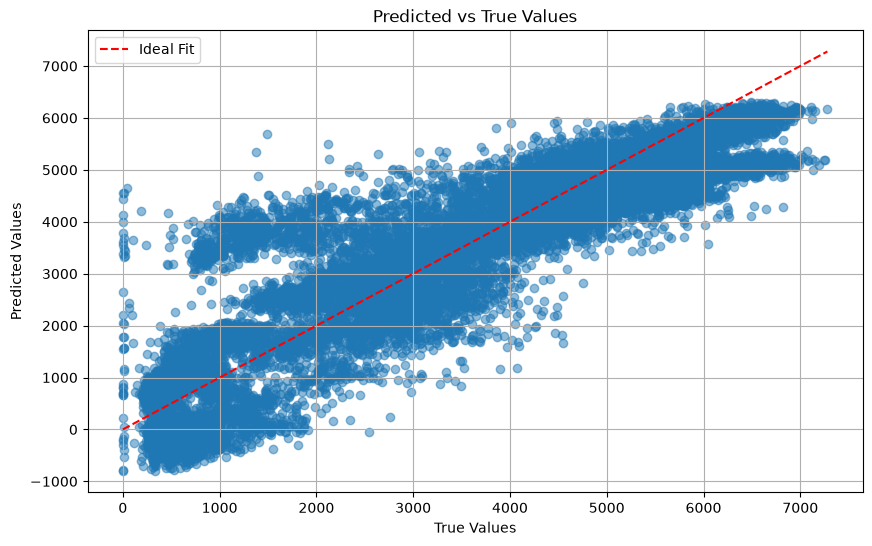

In [188]:
best_lr = 0.3162280 # Choose the best learning rate based on the previous graphs

best_linear_model = LinearRegression(learning_rate=best_lr, n_iterations=10000)
best_linear_model.fit(X, y)
y_pred = best_linear_model.predict(X)

pred_vs_true_plot(y, y_pred)

In [189]:
# Explore more plots to analyze the predictions, e.g., predictions vs time, contribution of each feature to the predictions, etc.

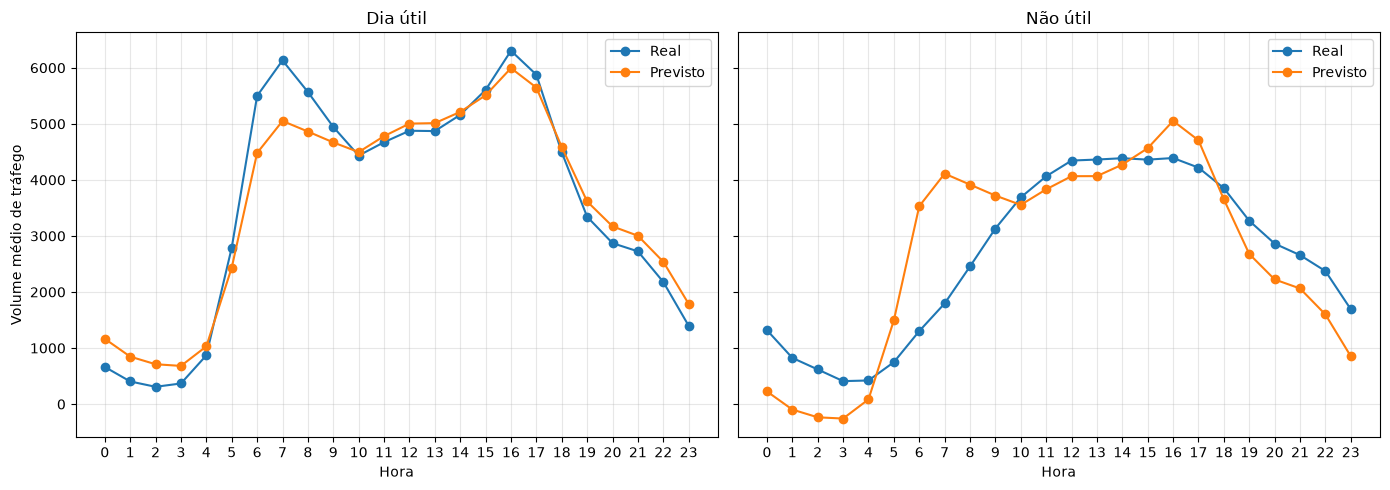

In [190]:
diagnostic_df = train_df_clean.copy()

diagnostic_df['y_true'] = y
diagnostic_df['y_pred'] = y_pred

hourly_comparison = (
    diagnostic_df
    .groupby(['hr', 'workingday'])[['y_true', 'y_pred']]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, workingday in zip(axes, [1, 0]):
    data = hourly_comparison.xs(workingday, level='workingday')

    ax.plot(data.index, data['y_true'], marker='o', label='Real')
    ax.plot(data.index, data['y_pred'], marker='o', label='Previsto')

    ax.set_title('Dia útil' if workingday == 1 else 'Não útil')
    ax.set_xlabel('Hora')
    ax.set_xticks(range(24))
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel('Volume médio de tráfego')

plt.tight_layout()
plt.show()

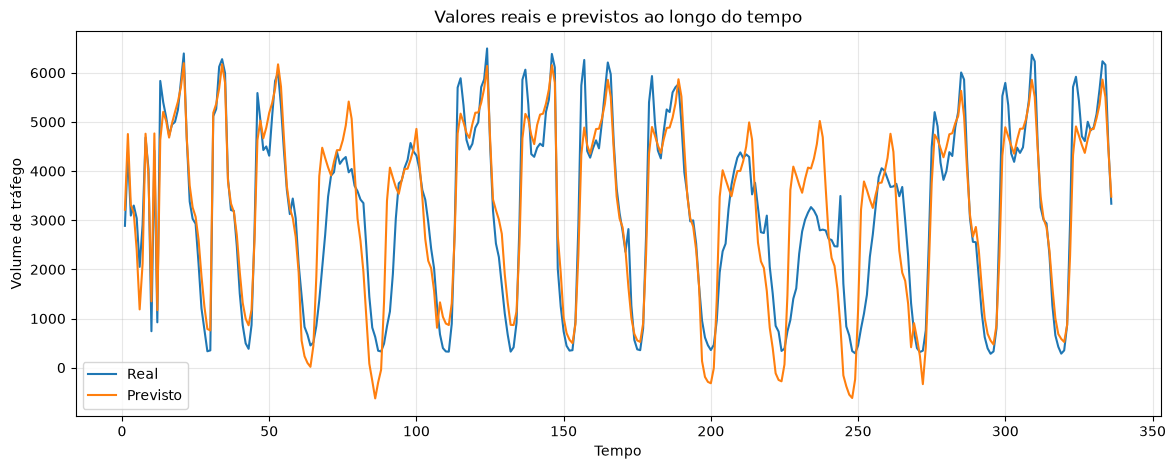

In [191]:
n = 24 * 14  # aproximadamente duas semanas

plt.figure(figsize=(14, 5))

plt.plot(
    train_df_clean['instant'].iloc[:n],
    y[:n],
    label='Real'
)

plt.plot(
    train_df_clean['instant'].iloc[:n],
    y_pred[:n],
    label='Previsto'
)

plt.xlabel('Tempo')
plt.ylabel('Volume de tráfego')
plt.title('Valores reais e previstos ao longo do tempo')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

> **Question:**
>
> Based on your visualizations, do you observe systematic deviations
(for example curvature or clusters)?
>
> If systematic patterns exist, what do they suggest about the relationship between the predictors and the target?
>
> Does this visualization support or contradict the hypotheses you proposed earlier?

Yes. The visualizations show clear systematic deviations rather than purely random prediction errors. In the predicted-versus-true plot, the observations form several bands or clusters around the ideal line instead of a single tight cloud. The model also tends to compress the predictions toward intermediate values, with larger errors at some low and high traffic volumes.

The hourly plots make the source of some of these errors clearer. On working days, the model captures the general daily pattern reasonably well, but it underestimates some important rush-hour peaks, especially around the morning and afternoon commuting periods. On non-working days, the deviations are stronger: the model substantially overestimates traffic during some morning hours and underestimates it during parts of the evening. The time-series visualization confirms that the model captures the overall daily cycle but still misses some peaks and troughs.

These patterns suggest that the relationship between the predictors and traffic volume is not purely additive. In particular, the effect of hour of the day depends on whether the day is a working day. Although `hr` is represented using one-hot encoding, the linear model assigns one hourly effect that is shared across working and non-working days. Without an interaction such as `hr × workingday`, it cannot fully represent the different traffic profiles of these two types of days. Other nonlinear relationships and interactions may also contribute to the remaining error.

Therefore, these visualizations support the hypothesis proposed earlier: the remaining error is partly caused by nonlinear relationships and interactions that a purely additive linear model cannot capture. This provides motivation for exploring polynomial features, particularly interaction terms, to increase the model's flexibility.

---
#### **Residual Analysis**
(1.0 points) As discussed above, a main assumption we have made is the nature of $\epsilon$ to
be Gaussian.

These error values are now computable by the difference between the ground-truth and
the predicted values

$$r_i = y - \hat{y} \sim \mathcal{N}(0, \sigma)$$

Therefore, if our linear regression model is correct, we can observe normally
distributed residuals across the dataset.
One way of checking how normally is distributed our distribution is by a
quantile–quantile (Q–Q) plot.

This plot compares the empirical distribution of residuals with the theoretical quantiles of a reference distribution (usually the normal distribution).

To do this, we sort the residuals, compute the theoretical quantiles and plot they along
so each point (r_i, q_i) compares the observed residual and the quantile if the
distribution were normally distributed.

Similarly to the previous plot, if the points follow the line y=x, the quantiles
are well aligned with the empirical distribution, suggesting a good fit.
However, curvatures may represent skews in the distribution, usually indicating
that the distribution is not normal.

In [192]:
def q_q_plot(y_true: NDArray[np.float64], y_pred: NDArray[np.float64]) -> None:
    residuals = y_true - y_pred

    sorted_residuals = np.sort(residuals)
    theoretical_quantiles = np.sort(np.random.normal(loc=0, scale=np.std(residuals), size=len(residuals)))

    plt.figure(figsize=(10, 6))
    plt.grid()
    plt.scatter(theoretical_quantiles, sorted_residuals, alpha=0.5, s=10, label='Residuals')
    plt.plot([theoretical_quantiles.min(), theoretical_quantiles.max()], [theoretical_quantiles.min(), theoretical_quantiles.max()], color='red', linestyle='--', label='Ideal Fit')
    plt.xlabel("Theoretical Quantiles")
    plt.ylabel("Ordered Residuals")
    plt.title("Q-Q Plot of Residuals")
    plt.legend()
    plt.show()

def plot_residuals_distribution(y, y_pred):
    """
    Visualize the distribution of residuals.
    Should look approximately normal if model assumptions are met.
    """
    residuals = y - y_pred
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram with KDE
    axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, density=True)
    from scipy import stats
    mu, sigma = residuals.mean(), residuals.std()
    x = np.linspace(residuals.min(), residuals.max(), 100)
    axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal fit')
    axes[0].set_xlabel("Residuals")
    axes[0].set_ylabel("Density")
    axes[0].set_title("Distribution of Residuals")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residuals over time (index)
    axes[1].plot(residuals, linewidth=0.5, alpha=0.7)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].fill_between(range(len(residuals)), -2*sigma, 2*sigma, alpha=0.2, color='red', label='±2σ')
    axes[1].set_xlabel("Sample Index")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Residuals Over Time")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

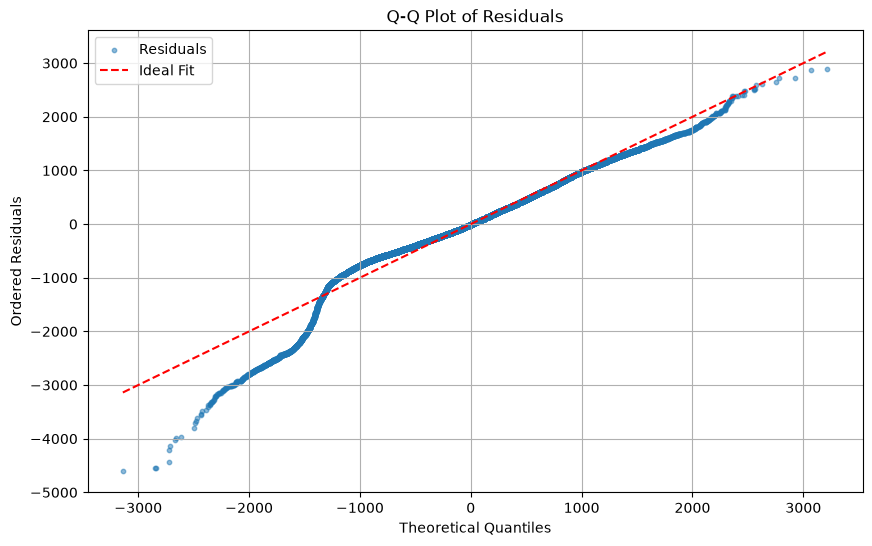

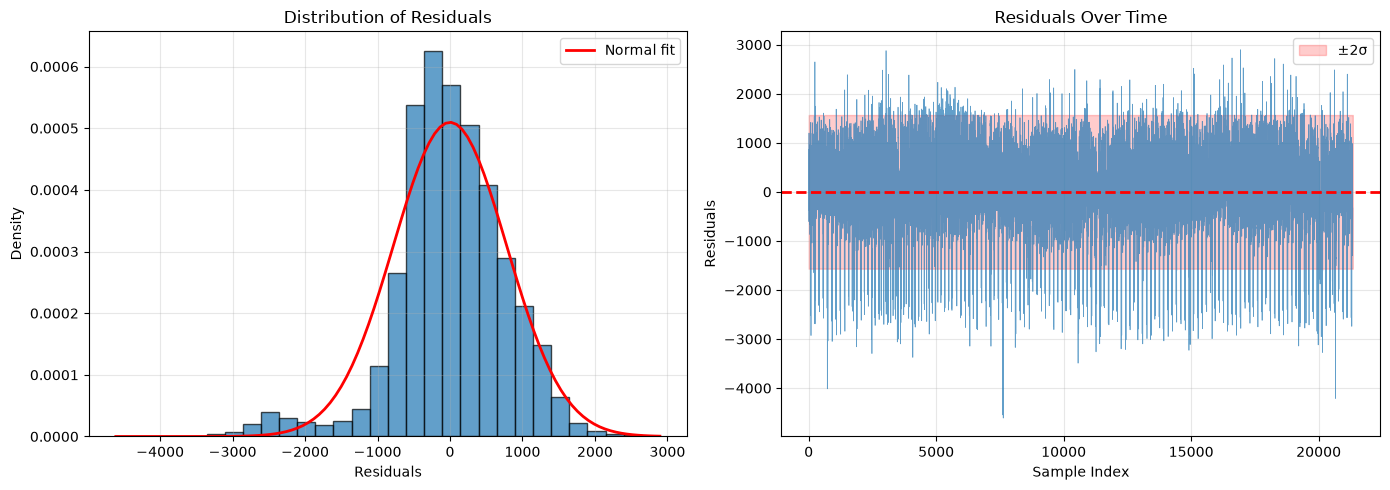

In [193]:
q_q_plot(y, y_pred)
plot_residuals_distribution(y, y_pred)

> **Question:**
>
> Are the points approximately aligned along a straight line?
>
> What does this indicate about the Gaussian noise assumption used to derive
the MSE objective?
>
> Based on the evidence from the metrics and plots,
> is linear regression an appropriate model for this dataset?
>
> Justify your conclusion.

The Q-Q plot shows that the residuals are approximately aligned with the reference line in the central region, but there are substantial deviations in the tails, especially in the negative tail. The residual distribution also shows some asymmetry and heavier tails than the fitted Gaussian distribution. Therefore, the residuals cannot be considered well approximated by a normal distribution.

This means that the Gaussian noise assumption used to derive the MSE objective is not fully satisfied. Under the Gaussian assumption, minimizing MSE is equivalent to maximizing the likelihood of the observations. Since the residuals show clear departures from normality, this probabilistic interpretation is not completely supported by the data. However, MSE can still be used as a valid optimization criterion even when the residuals are not perfectly Gaussian.

Overall, linear regression provides a reasonable baseline, but it does not appear to be fully adequate for this dataset. The model achieved an R² of approximately 0.834, meaning that it explains about **83.4%** of the variability in the training data, with an MAE of approximately **593 vehicles**. Nevertheless, the diagnostic plots reveal systematic errors: the model has difficulty reproducing some traffic peaks and valleys, the hourly behavior differs substantially between working and non-working days, and the residuals contain several large deviations.

These results suggest that the relationship between the predictors and traffic volume is not purely linear and additive. In particular, interactions such as `hour × workingday` and other nonlinear relationships are likely important. Therefore, **linear regression is useful as an interpretable baseline, but a more flexible model, such as polynomial regression with interaction terms, may be more appropriate for capturing the remaining structure in the data**.

---

## **Polynomial Models**


Linear regression assumes that the relationship between the features and the
target is linear.
However, in many real-world situations the relationship between
a variable and the output may be curved or more complex.

For example, suppose that the traffic volume grows as the temperature rises from
a freezing morning up to a comfortable level, but then stops growing (or even
decreases) once the weather becomes too hot.
A straight line would not be able to capture this behavior.

One way to increase the flexibility of linear regression is to transform the
input features.
Instead of using raw variables $x_i$, we can include higher
powers of it, creating new features such as $x_i^2$, $x_i \cdot x_j$, and so on.

For instance, a quadratic model can be written as

$$y \approx \beta_0 + \beta_1 x + \beta_2 x^2.$$

Although this model is nonlinear with respect to the original variables,
it is still **linear in the parameters** $\beta$.
Because of this, the same training methods used for linear regression can still
be applied.

The effect is an increased set of possible models that can describe the relationship
between $x$ and $y$ via parameters $\beta$.

In practice, polynomial regression is implemented by **expanding the feature
space**.
For example, if the original input is $(x_1, x_2)$, a polynomial expansion of
degree two could produce the new feature vector

$$(x_1, x_2, x_1^2, x_2^2, x_1 x_2).$$

The regression model is then applied to this expanded set of features.
This transformation allows the model to capture nonlinear relationships while
keeping the optimization problem simple.

### **Model Capacity and Overfitting**

Increasing the polynomial degree increases the **capacity** of the model. A
higher-degree polynomial can represent more complex relationships in the data.

However, a model that is too flexible may start fitting the noise present in
the training data instead of the underlying relationship. This phenomenon is
called **overfitting**.

As the polynomial degree increases:

- The training error usually decreases.
- The test error may start increasing after a certain point.

This happens because the model becomes too specialized to the training dataset.

### **Implementation**

(1.0 points) Implement the `polynomial_expansion` function that expands the input features
to polynomial features of degree at most $d$.

Instead of using only the original variables, now include polynomial terms with
different degree values, for example, $d = 2, 3, \dots$.
This makes the model more flexible and can represent non-linear relationships
between the predictors and the target.

Remember to test for different learning rates, similar to what was done previously.

In [194]:
from itertools import combinations_with_replacement
from typing import Optional, Tuple

def polynomial_expansion(
    X: NDArray[np.float64],
    d: int,
    scaling_stats: Optional[dict] = None
) -> Tuple[NDArray[np.float64], dict]:

    if d < 1:
        raise ValueError("The polynomial degree must be at least 1.")

    n_samples, n_features = X.shape
    expanded_features = []

    # ============================================================
    # 1. Polynomial expansion
    # ============================================================

    for degree in range(1, d + 1):

        for combination in combinations_with_replacement(
            range(n_features),
            degree
        ):
            term = np.prod(
                X[:, combination],
                axis=1
            )

            expanded_features.append(term)

    X_expanded = np.column_stack(
        expanded_features
    ).astype(np.float64)

    # ============================================================
    # 2. Scale polynomial features
    # ============================================================

    X_scaled = X_expanded.copy()

    # FIT MODE:
    # Compute statistics using training data
    if scaling_stats is None:

        scaling_stats = {}

        for j in range(X_expanded.shape[1]):

            col = X_expanded[:, j]

            unique_values = np.unique(col)

            is_binary = np.all(
                np.isin(unique_values, [0.0, 1.0])
            )

            mean = np.mean(col)
            std = np.std(col)

            if std == 0:
                std = 1.0

            scaling_stats[j] = {
                "mean": mean,
                "std": std,
                "is_binary": is_binary
            }

            # Keep binary variables as 0/1
            if not is_binary:
                X_scaled[:, j] = (
                    col - mean
                ) / std

    # TRANSFORM MODE:
    # Reuse statistics learned from training data
    else:

        if len(scaling_stats) != X_expanded.shape[1]:
            raise ValueError(
                "The supplied scaling statistics do not match "
                "the number of polynomial features."
            )

        for j in range(X_expanded.shape[1]):

            col = X_expanded[:, j]

            mean = scaling_stats[j]["mean"]
            std = scaling_stats[j]["std"]
            is_binary = scaling_stats[j]["is_binary"]

            if not is_binary:
                X_scaled[:, j] = (
                    col - mean
                ) / std

    return X_scaled, scaling_stats


Degree = 1
Shape: (21340, 53) -> (21340, 53)
lr=0.000100 | MSE=8258239.96 | R²=-1.1405 | MAE=2388.21
lr=0.000316 | MSE=4197193.52 | R²=-0.0879 | MAE=1782.47
lr=0.001000 | MSE=3156330.79 | R²=0.1819 | MAE=1540.43
lr=0.003162 | MSE=2452014.81 | R²=0.3645 | MAE=1343.57
lr=0.010000 | MSE=1372950.43 | R²=0.6441 | MAE=963.06
lr=0.031623 | MSE=833878.90 | R²=0.7839 | MAE=677.32
lr=0.100000 | MSE=735049.53 | R²=0.8095 | MAE=623.85
lr=0.316228 | MSE=640308.37 | R²=0.8340 | MAE=592.92
lr=1.000000 -> diverged


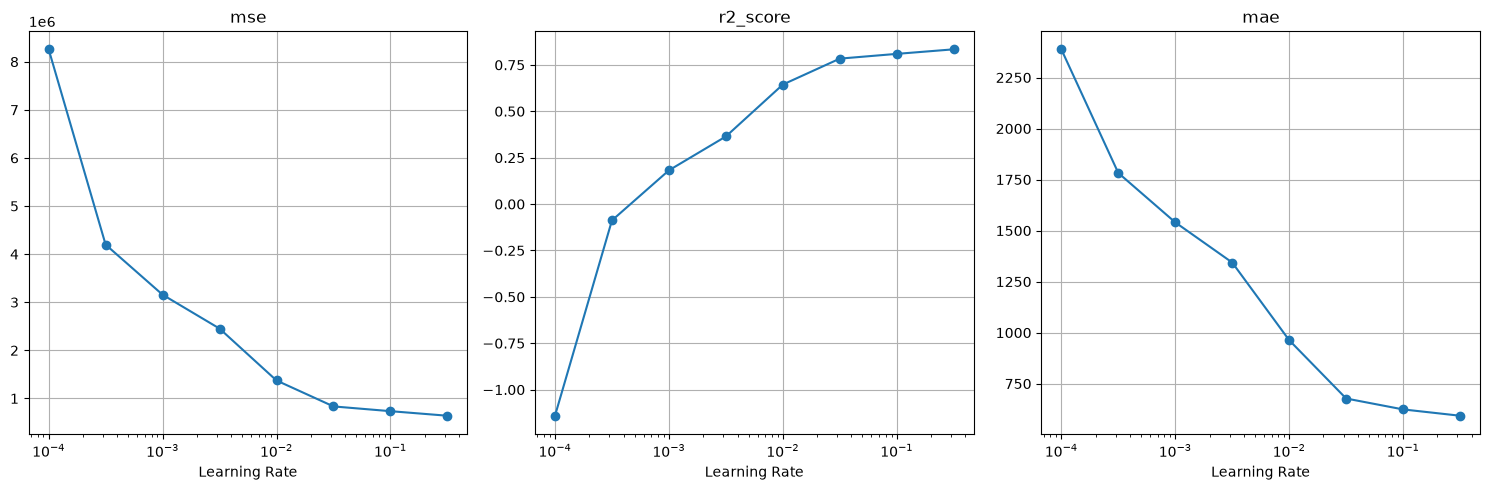


Best configuration for degree 1:
Learning rate: 0.316228
MSE: 640308.37
R²: 0.8340
MAE: 592.92
Diverged learning rates for degree 1: [1.0]

Degree = 2
Shape: (21340, 53) -> (21340, 1484)
lr=0.000100 | MSE=5771210.43 | R²=-0.4959 | MAE=2019.54
lr=0.000316 | MSE=2909195.14 | R²=0.2460 | MAE=1450.19
lr=0.001000 | MSE=2055443.81 | R²=0.4672 | MAE=1179.00
lr=0.003162 | MSE=1179489.75 | R²=0.6943 | MAE=866.82
lr=0.010000 | MSE=616840.91 | R²=0.8401 | MAE=564.22
lr=0.031623 | MSE=372093.59 | R²=0.9036 | MAE=419.47
lr=0.100000 | MSE=208981.10 | R²=0.9458 | MAE=311.61
lr=0.316228 -> diverged
lr=1.000000 -> diverged


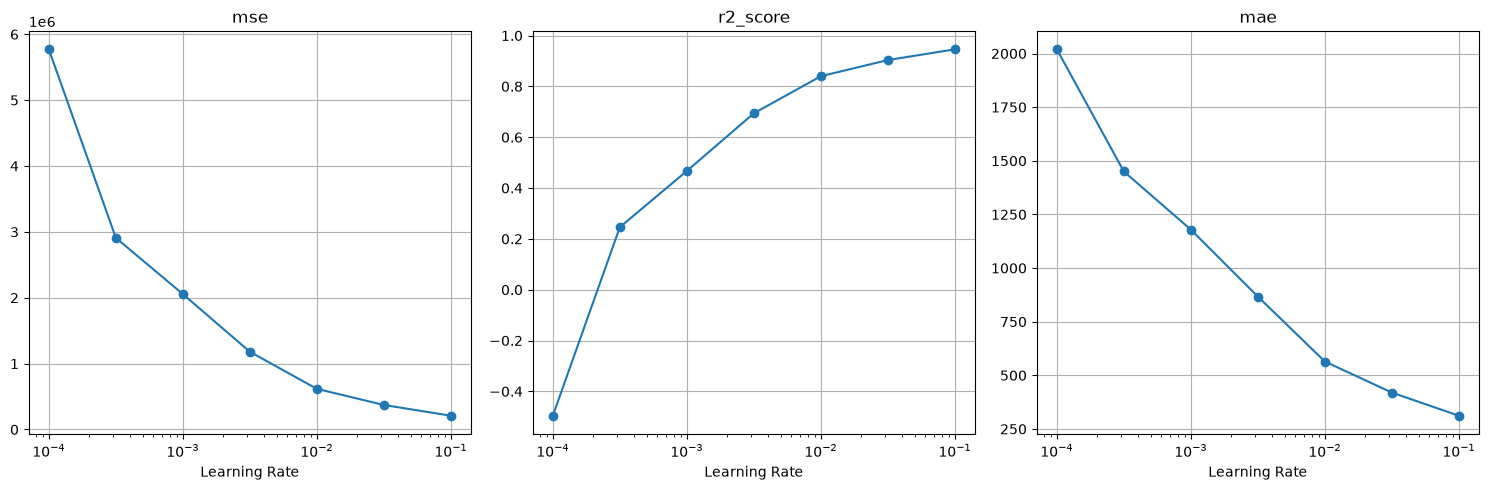


Best configuration for degree 2:
Learning rate: 0.100000
MSE: 208981.10
R²: 0.9458
MAE: 311.61
Diverged learning rates for degree 2: [0.31622776601683794, 1.0]

Summary of best configurations
Degree 1 | LR=0.316228 | MSE=640308.37 | R²=0.8340 | MAE=592.92
Degree 2 | LR=0.100000 | MSE=208981.10 | R²=0.9458 | MAE=311.61


In [ ]:
# Implement and train the polynomial regression models here using the
# polynomial_expansion function to transform the features before training the linear regression model.

# Experiment with different degrees and analyze the results to choose the best combination
# of learning rate and degree for the polynomial regression model.

degrees = [1, 2]

# Logarithmic learning-rate grid
lrs = np.logspace(-4, 0, 9).tolist()

poly_results = []
best_poly_configs = {}

# Stores the scaling statistics learned for each degree
polynomial_scaling_stats = {}

for degree in degrees:

    print(f"\nDegree = {degree}")

    # ============================================================
    # Polynomial expansion + scaling
    # ============================================================

    X_poly, scaling_stats = polynomial_expansion(
        X,
        degree
    )

    # Store statistics for future use on test data
    polynomial_scaling_stats[degree] = scaling_stats

    print(
        f"Shape: {X.shape} -> {X_poly.shape}"
    )

    performances = {
        "mse": [],
        "r2_score": [],
        "mae": [],
    }

    diverged_lrs = []

    # ============================================================
    # Search learning rates
    # ============================================================

    for lr in lrs:

        model = LinearRegression(
            learning_rate=lr,
            n_iterations=1000
        )

        model.fit(
            X_poly,
            y
        )

        y_pred_poly = model.predict(
            X_poly
        )

        # Checks for numerical divergence
        if not np.isfinite(y_pred_poly).all():

            performances["mse"].append(np.nan)
            performances["r2_score"].append(np.nan)
            performances["mae"].append(np.nan)

            diverged_lrs.append(lr)

            print(
                f"lr={lr:.6f} -> diverged"
            )

            continue

        # ========================================================
        # Metrics
        # ========================================================

        mse_score = mse(
            y,
            y_pred_poly
        )

        r2 = r2_score(
            y,
            y_pred_poly
        )

        mae_score = mae(
            y,
            y_pred_poly
        )

        performances["mse"].append(
            mse_score
        )

        performances["r2_score"].append(
            r2
        )

        performances["mae"].append(
            mae_score
        )

        poly_results.append({
            "degree": degree,
            "learning_rate": lr,
            "mse": mse_score,
            "r2_score": r2,
            "mae": mae_score
        })

        print(
            f"lr={lr:.6f} | "
            f"MSE={mse_score:.2f} | "
            f"R²={r2:.4f} | "
            f"MAE={mae_score:.2f}"
        )

    # ============================================================
    # Plot results
    # ============================================================

    plot_results(
        lrs,
        performances
    )

    # ============================================================
    # Select best LR for this degree
    # ============================================================

    mse_array = np.array(
        performances["mse"],
        dtype=np.float64
    )

    finite_mask = np.isfinite(
        mse_array
    )

    if finite_mask.any():

        best_idx = int(
            np.nanargmin(mse_array)
        )

        best_lr = lrs[best_idx]

        best_poly_configs[degree] = {
            "learning_rate": best_lr,q
            "mse": performances["mse"][best_idx],
            "r2_score": performances["r2_score"][best_idx],
            "mae": performances["mae"][best_idx],
        }

        print(
            f"\nBest configuration for degree {degree}:"
        )

        print(
            f"Learning rate: {best_lr:.6f}"
        )

        print(
            f"MSE: "
            f"{performances['mse'][best_idx]:.2f}"
        )

        print(
            f"R²: "
            f"{performances['r2_score'][best_idx]:.4f}"
        )

        print(
            f"MAE: "
            f"{performances['mae'][best_idx]:.2f}"
        )

    if diverged_lrs:

        print(
            f"Diverged learning rates for degree {degree}: "
            f"{diverged_lrs}"
        )


# ================================================================
# Summary
# ================================================================

print("\nSummary of best configurations")

for degree, config in best_poly_configs.items():

    print(
        f"Degree {degree} | "
        f"LR={config['learning_rate']:.6f} | "
        f"MSE={config['mse']:.2f} | "
        f"R²={config['r2_score']:.4f} | "
        f"MAE={config['mae']:.2f}"
    )

> **Question:**
>
> How does the training error of the polynomial model compare with the
training error of the linear regression model?
>
> Does this result indicate that it is better than the linear
model for this problem?
>
> Which degree would you select to explore?

The degree-2 polynomial model achieved a substantially lower training error than the linear model. The linear model obtained an MSE of 640,308.37, an R² of 0.8340, and an MAE of 592.92, whereas the degree-2 polynomial model obtained an MSE of 208,981.10, an R² of 0.9458, and an MAE of 311.61. Therefore, the quadratic model fits the training data considerably better.

However, a lower training error alone does not prove that the polynomial model is better for this prediction problem. The degree-2 model has many more features and therefore greater flexibility, including squared terms and pairwise interactions. This additional capacity can reduce training error but may also increase the risk of overfitting. Its ability to generalize must therefore be evaluated on unseen data.

I would select **degree 2** for further exploration. It provides a clear improvement over degree 1 while introducing only second-order nonlinearities and interactions. This is also consistent with the earlier diagnostic plots, which suggested that the relationship between the predictors and traffic volume is not purely additive and that interactions, such as those involving hour and working-day status, may be important. Higher degrees would increase model complexity much more rapidly and would introduce a greater risk of overfitting without first establishing that this additional flexibility is necessary.

Therefore, degree 2 represents a reasonable compromise between model flexibility and complexity, but its final superiority over the linear model should be determined using the test set rather than training performance alone.

---
### **Visualizing Predictions**

> (1.5 points) Inspect the predicted vs observed plot, compare with the same plots used in the
> linear model, are they different?
>
> Explore how the results change and link them with training error in the polynomial
model.

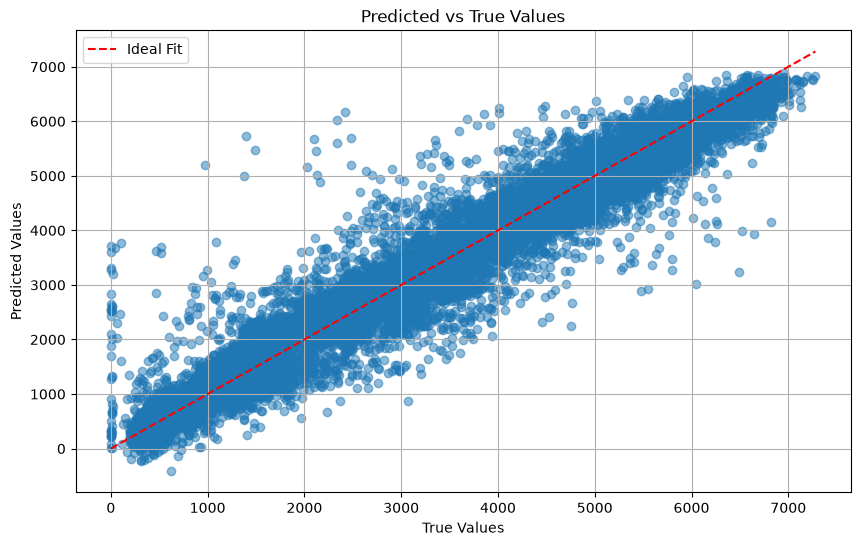

In [196]:
best_lr = 0.100000 # Choose the best learning rate based on the previous graphs
best_degree = 2 # Choose the best degree based on experimentation with different degrees and analyzing the results

X_poly, best_poly_scaling_stats = polynomial_expansion(X, best_degree)

best_poly_model = LinearRegression(best_lr, n_iterations=10000)
best_poly_model.fit(X_poly, y)
y_pred = best_poly_model.predict(X_poly)

pred_vs_true_plot(y, y_pred)

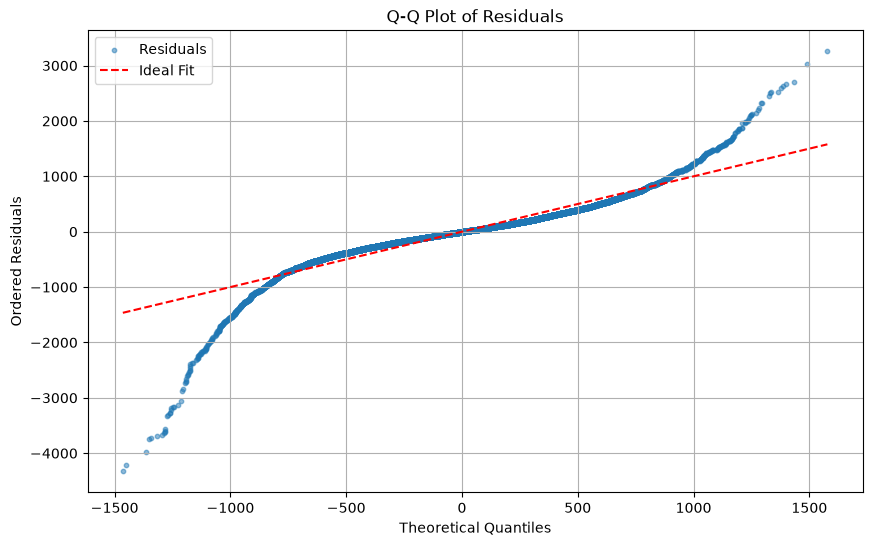

In [197]:
q_q_plot(y, y_pred)

In [198]:
# Plot other visualizations too to better analyze the predictions.

In [199]:
diagnostic_df = train_df_clean.copy()

diagnostic_df["y_true"] = y
diagnostic_df["y_pred"] = y_pred
diagnostic_df["residual"] = y - y_pred
diagnostic_df["abs_error"] = np.abs(y - y_pred)

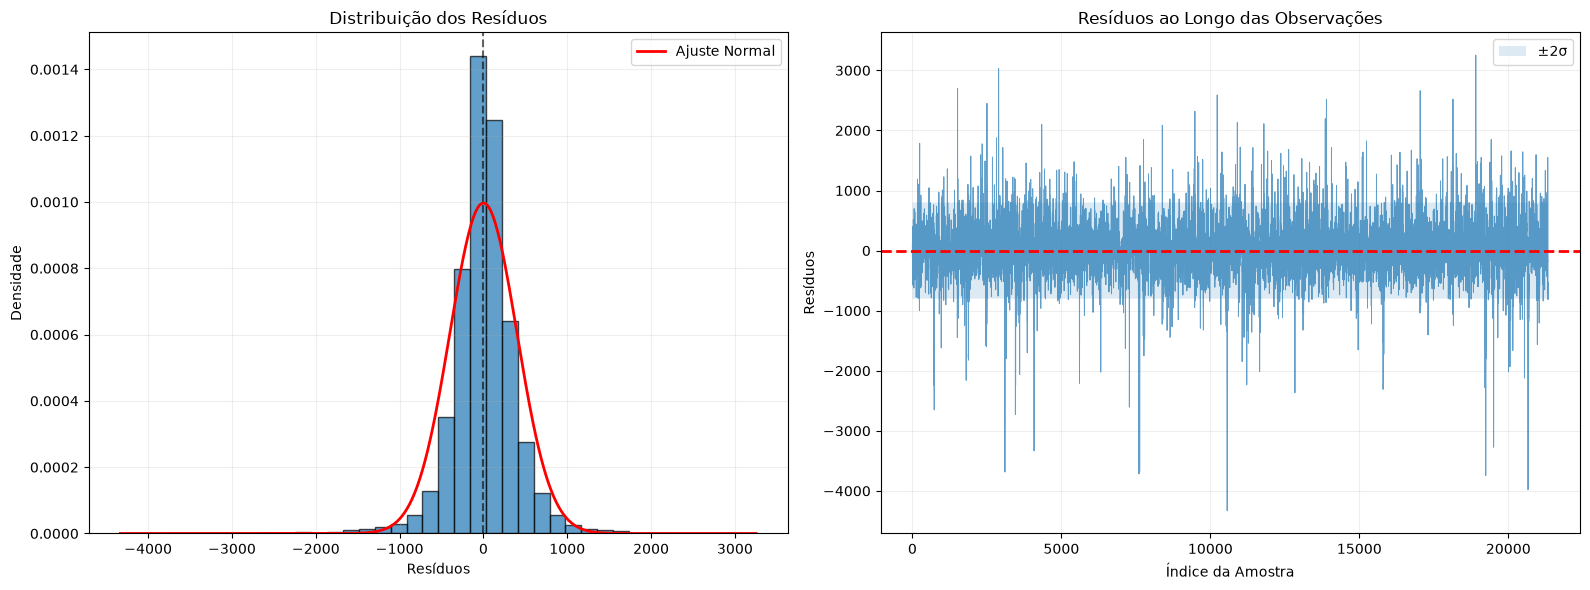

In [200]:
def residual_diagnostics_plot(
    y_true: NDArray[np.float64],
    y_pred: NDArray[np.float64]
) -> None:

    residuals = y_true - y_pred

    # Estatísticas dos resíduos
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # =========================================================
    # 1. Distribuição dos resíduos
    # =========================================================
    ax[0].hist(
        residuals,
        bins=40,
        density=True,
        alpha=0.7,
        edgecolor="black"
    )

    # Curva Normal com mesma média e desvio-padrão dos resíduos
    x = np.linspace(
        residuals.min(),
        residuals.max(),
        500
    )

    normal_density = (
        1 / (std_residual * np.sqrt(2 * np.pi))
        * np.exp(
            -0.5
            * ((x - mean_residual) / std_residual) ** 2
        )
    )

    ax[0].plot(
        x,
        normal_density,
        color="red",
        linewidth=2,
        label="Ajuste Normal"
    )

    ax[0].axvline(
        0,
        color="black",
        linestyle="--",
        alpha=0.6
    )

    ax[0].set_title("Distribuição dos Resíduos")
    ax[0].set_xlabel("Resíduos")
    ax[0].set_ylabel("Densidade")
    ax[0].legend()
    ax[0].grid(alpha=0.2)

    # =========================================================
    # 2. Resíduos ao longo das observações
    # =========================================================
    sample_index = np.arange(len(residuals))

    ax[1].plot(
        sample_index,
        residuals,
        linewidth=0.7,
        alpha=0.7
    )

    # Linha de resíduo zero
    ax[1].axhline(
        0,
        color="red",
        linestyle="--",
        linewidth=2
    )

    # Faixa de ±2 desvios-padrão
    upper_limit = mean_residual + 2 * std_residual
    lower_limit = mean_residual - 2 * std_residual

    ax[1].fill_between(
        sample_index,
        lower_limit,
        upper_limit,
        alpha=0.15,
        label="±2σ"
    )

    ax[1].set_title("Resíduos ao Longo das Observações")
    ax[1].set_xlabel("Índice da Amostra")
    ax[1].set_ylabel("Resíduos")
    ax[1].legend()
    ax[1].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

residual_diagnostics_plot(y, y_pred)

> **Question:**
>
> Does the polynomial model appear to capture relationships that the linear model could not?
>
> Did this choice fix the systematic deviations previously observed?


The degree-2 polynomial model provides a visibly better fit than the linear model. In the predicted-versus-true plot, the points are more tightly concentrated around the ideal $y=x$ line, especially over the middle and higher traffic-volume ranges. This suggests that the added quadratic terms and pairwise interactions are capturing nonlinear relationships and interactions that were not represented by the purely additive linear model.

The previously observed systematic deviations were therefore **reduced, but not completely removed**. Some structure is still visible. In particular, very low traffic volumes still show considerable dispersion and some strong overprediction, and there are isolated observations throughout the range where the model substantially over- or underpredicts the target.

The residual diagnostics support the same conclusion. Most residuals are concentrated closer to zero than before, indicating an improved fit, but the Q-Q plot shows strong deviations from the reference line in both tails. The residual distribution is more sharply concentrated around zero and has heavier tails than a Gaussian distribution. Large residual spikes also remain across the observations.

Therefore, the polynomial model improves the systematic errors observed with linear regression and captures additional structure in the data, but **it does not fully solve the model-misspecification problem**. Some nonlinear behavior, unusual observations, or interactions are still not adequately represented by a second-degree polynomial model.

---
## **Count Data and Model Assumptions**

> **IMPORTANT:** This section is optional and will yield **additional 1.0 points**
> to your assignment.
> We recommend you finish the mandatory sections above before attempting to
> switch to additional assumptions and model decisions this section introduces.
>
> Despite this section being optional, we strongly advise you on exploring
> the following models, not only as an additional model to your toolbox, but
> from the modeling perspective of statistical learning.

\
In the previous sections we used linear regression and polynomial models
to predict the hourly traffic volume.
However, the target variable in this dataset has a particular characteristic,
it represents a **count**.

This is important because, when we were stating the assumptions in the linear model,
we had no hard assumption on the target nature, it was a real number.
In counting problems, the target is a positive integer number with specific
characteristics that are ignored.

Therefore, a possible direction of improvement is choosing the model that best
aligns with our problem, exploiting the domain knowledge we have to produce better
estimators.

In this section, we are going to use a new linear model with a different
probabilistic assumption for the target variable.

### **Poisson distribution**

A common model for count data is the **Poisson distribution**.
This distribution describes the probability of observing a number of events
during a fixed interval.

For example, the number of students achieving a low and high mark in an exam,
the number of meteorites that strike Earth in a year, or the number of vehicles
crossing a sensor in one hour.

The Poisson distribution is parameterized by a rate parameter $\lambda > 0$,
which represents the expected number of events in a time unit.

The probability of observing a value $y$ is

$$p(y \mid \lambda) = \frac{\lambda^y e^{-\lambda}}{y!}.$$

In this model, both the mean and the variance are equal to $\lambda$.
Therefore, when predicting, returning the expected count value $\hat{y}$ is
equivalent to returning $\lambda$ itself.

### **Poisson Regression**
Poisson regression is a special case of the Generalized Linear Models along with
Linear and Logistic regression.
The idea here is to model $\lambda$ as a function of the input $x$ and parameters
$\beta$ and describe $p(y \mid x, \beta) = p(y \mid \lambda)$.

Again, as a linear model, we want to relate the linear combination
$\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n$ to this new parameter $\lambda$,
that is strictly positive.

To make this to happen, we define a **link function** $g$ such that $g(\lambda)$
can vary from -$\infty$ to $\infty$, thus allowing that

$$g(\lambda) = \beta_0 + \beta_1 x_1 + \dots + \beta_n x_n,$$
as $\beta$ and $x$ are unconstrained.

A common link function used in Poisson regression is the $\log$, making

$$\hat{y} = \lambda = \exp(\beta_0 + \beta_1 x_1 + \dots + \beta_n x_n),$$
turning the previously unconstrained prediction in a strictly positive count
parameter, and then addressing a probability using the Poisson distribution.

#### **Implementation**

(1.0 points) Derive the loss function of the Poisson Regression,

$$-\log \mathcal{L}(\beta) = -\sum_{i=1}^n \log p(y^i \mid x^i, \beta),$$
using the Poisson distribution instead of the Gaussian distribution for $p(y^i \mid x^i, \beta)$.

**Hint:** You can ignore constant terms and scales in the objective function to
obtain a MSE-like gradient.

> **Question:**
>
> Is the negative log-likelihood the same?
>
> Is it equivalent to a Linear regressor predicting $\log y$ instead of $y$?

The Poisson probability of a count $y$ given rate $\lambda > 0$ is

$$p(y \mid \lambda) = \frac{\lambda^y e^{-\lambda}}{y!}.$$

With the log link, $\lambda = \exp(\eta)$ and $\eta = x^\top\beta$, including the intercept in $x$. The negative log-likelihood of one observation is

$$-\log p(y \mid x, \beta) = -y\log\lambda + \lambda + \log(y!) = -y\,\eta + \exp(\eta) + \log(y!).$$

Summing over the training set and dropping $\log(y!)$, which does not depend on $\beta$, the training objective is

$$L(\beta) = \sum_{i=1}^{n}\left[\exp(x_i^\top\beta) - y_i\, x_i^\top\beta\right].$$

Its gradient has the same shape as the linear-regression gradient, with residual $\lambda_i - y_i$ instead of $\hat y_i - y_i$:

$$\nabla_\beta L(\beta) = \sum_{i=1}^{n}\left(\exp(x_i^\top\beta) - y_i\right) x_i.$$

The factor $2$ from the squared error does not appear. The prediction returned by the model is $\lambda = \exp(x^\top\beta)$, which is strictly positive, not the linear score $x^\top\beta$.

---
Implement this regression using the same pattern as the `LinearRegression` and
train a Poisson regression model using the same training dataset used
previously, selecting appropriate learning rates.

> **Hint:** the counts in this dataset are large, so $\exp(x^T\beta)$ can easily
> overflow during the first iterations. If you run into `inf`/`nan`, think about
> the scale of your features and of the initial prediction before blaming the
> learning rate alone.

In [209]:
class PoissonRegression:
    def __init__(
        self,
        learning_rate: float = 0.01,
        n_iterations: int = 1000,
    ) -> None:
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights: NDArray[np.float64] | None = None
        self.bias: float | None = None

    def fit(self, X: NDArray[np.float64], y: NDArray[np.float64]) -> None:
        n_samples, n_features = X.shape
        weights = np.zeros(n_features, dtype=np.float64)
        # lambda inicial = media do treino, para exp(x^T beta) nao estourar na primeira iteracao
        bias = float(np.log(max(float(np.mean(y)), 1.0)))

        for _ in range(self.n_iterations):
            eta = X @ weights + bias

            # Contagens grandes: um passo grande empurra eta para a regiao em que exp estoura.
            if (not np.isfinite(eta).all()) or float(np.max(eta)) > 40.0:
                weights[:] = np.nan
                bias = np.nan
                break

            lam = np.exp(eta)
            residual = lam - y
            dw = (X.T @ residual) / n_samples
            db = float(np.mean(residual))

            if (not np.isfinite(dw).all()) or (not np.isfinite(db)):
                weights[:] = np.nan
                bias = np.nan
                break

            weights -= self.learning_rate * dw
            bias -= self.learning_rate * db

        self.weights = weights
        self.bias = float(bias)

    def predict(self, X: NDArray[np.float64]) -> NDArray[np.float64]:
        assert self.weights is not None and self.bias is not None, "Model is not trained yet"
        eta = X @ self.weights + self.bias
        return np.exp(eta)



lr=0.000010 | MSE=1050829.12 | R2=0.7276 | MAE=830.55
lr=0.000017 | MSE=799534.69 | R2=0.7928 | MAE=691.67
lr=0.000031 | MSE=674414.30 | R2=0.8252 | MAE=607.52
lr=0.000054 | MSE=610224.89 | R2=0.8418 | MAE=563.73
lr=0.000094 | MSE=570246.37 | R2=0.8522 | MAE=542.13
lr=0.000164 | MSE=540640.33 | R2=0.8599 | MAE=527.84
lr=0.000287 | MSE=2898402.25 | R2=0.2488 | MAE=1397.05
lr=0.000501 | MSE=31432066.24 | R2=-7.1470 | MAE=4102.88


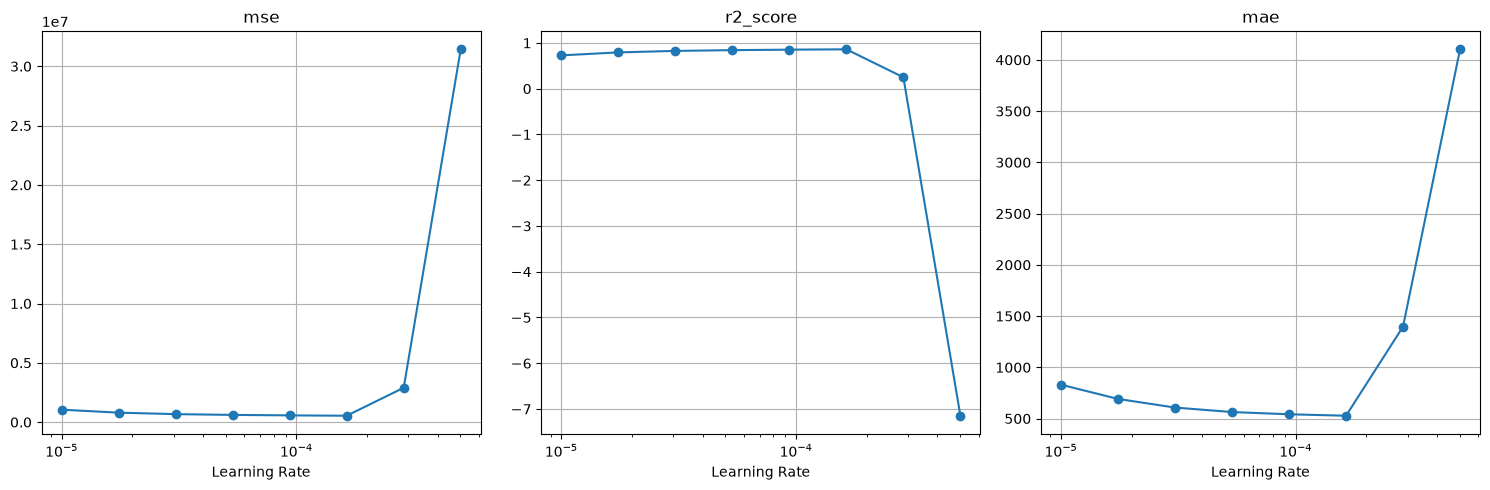


Best configuration:
Learning rate: 0.000164
MSE: 540640.33
R2: 0.8599
MAE: 527.84


In [210]:
# A curvatura da loss de Poisson e da ordem de lambda (~milhares).
# Learning rates da regressao linear (ate 0.3) divergem aqui.
lrs = np.logspace(-5, -3.3, 8).tolist()

performances = {
    "mse": [],
    "r2_score": [],
    "mae": [],
}
diverged_lrs: list[float] = []

for lr in lrs:
    model = PoissonRegression(learning_rate=lr, n_iterations=1000)
    model.fit(X, y)
    y_pred = model.predict(X)

    if not np.isfinite(y_pred).all():
        performances["mse"].append(np.nan)
        performances["r2_score"].append(np.nan)
        performances["mae"].append(np.nan)
        diverged_lrs.append(lr)
        print(f"lr={lr:.6f} -> divergiu")
        continue

    mse_score = mse(y, y_pred)
    r2 = r2_score(y, y_pred)
    mae_score = mae(y, y_pred)
    performances["mse"].append(mse_score)
    performances["r2_score"].append(r2)
    performances["mae"].append(mae_score)
    print(
        f"lr={lr:.6f} | "
        f"MSE={mse_score:.2f} | "
        f"R2={r2:.4f} | "
        f"MAE={mae_score:.2f}"
    )

plot_results(lrs, performances)

mse_array = np.array(performances["mse"], dtype=np.float64)
finite_mask = np.isfinite(mse_array)
if finite_mask.any():
    best_idx = int(np.nanargmin(mse_array))
    best_lr = lrs[best_idx]
    print("\nBest configuration:")
    print(f"Learning rate: {best_lr:.6f}")
    print(f"MSE: {performances['mse'][best_idx]:.2f}")
    print(f"R2: {performances['r2_score'][best_idx]:.4f}")
    print(f"MAE: {performances['mae'][best_idx]:.2f}")
else:
    best_lr = 1e-4
    print("No finite model found; falling back to lr=1e-4")



> **Question:**
>
> Compare the performance of the Poisson models with the Linear Regression model.
> Even though both models rely on a linear combination of the features,
> their predictions are not computed in the same way.
>
> $\hat{y}=x^T\beta$
>
> $\lambda=\exp(x^T\beta)$
>
> Are the predictive performances equivalent?
> Which model appears to produce predictions that better match the data?
>
> Explain why two models that both use a linear predictor can still behave
> very differently. Consider the distributional assumptions and the
> transformation applied to the output.

* **Are the predictive performances equivalent? Which model matches the data better?**

    They are not equivalent. On the training data, with 8,000 iterations and `learning_rate = 1.66e-4`, Poisson regression reaches an MSE of about 496,434, an R² of 0.871, and an MAE of 504. The linear model, trained for 10,000 iterations, reaches an MSE of about 612,923, an R² of 0.841, and an MAE of 579. Every Poisson prediction is positive (about 253 to 6,811). The linear model can predict negative counts.

* **Why can two models with a linear predictor still behave differently?**

    Both models form a linear score $x^\top\beta$, but they do not treat that score as the prediction. Linear regression returns $\hat y = x^\top\beta$ and minimizes squared error, which is the loss implied by Gaussian noise of constant variance. Poisson regression returns $\lambda = \exp(x^\top\beta)$ and minimizes $\sum_i(\exp(x_i^\top\beta) - y_i x_i^\top\beta)$. A change in a feature therefore multiplies the expected count instead of adding a fixed number of vehicles, and the variance is tied to $\lambda$ rather than assumed constant. The same features can then fit the hourly cycle better and cannot cross into negative traffic.


---
### **Visualizing Predictions**

Check how the predictions change when moving from the **Gaussian assumption**
used in linear regression to the **Poisson assumption** used in Poisson regression.

Plot the predicted values against the observed values and compare the
distribution of points with the plots obtained previously.

Pay attention to how the **shape of the point cloud** changes under the
different modeling assumptions.


Poisson train | MSE=496466.55 | R2=0.8713 | MAE=503.95 | min=252.5 | max=6811.1


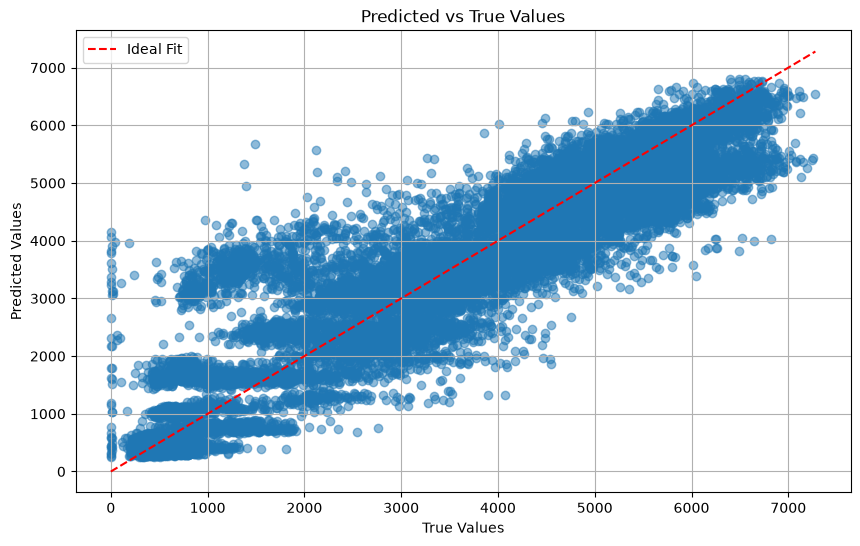

In [211]:
# best_lr vem da busca na celula anterior. 1.0 diverge: a loss de Poisson tem curvatura da ordem de lambda.
best_poisson_model = PoissonRegression(learning_rate=best_lr, n_iterations=8000)
best_poisson_model.fit(X, y)
y_pred = best_poisson_model.predict(X)

print(
    f"Poisson train | "
    f"MSE={mse(y, y_pred):.2f} | "
    f"R2={r2_score(y, y_pred):.4f} | "
    f"MAE={mae(y, y_pred):.2f} | "
    f"min={y_pred.min():.1f} | max={y_pred.max():.1f}"
)
pred_vs_true_plot(y, y_pred)


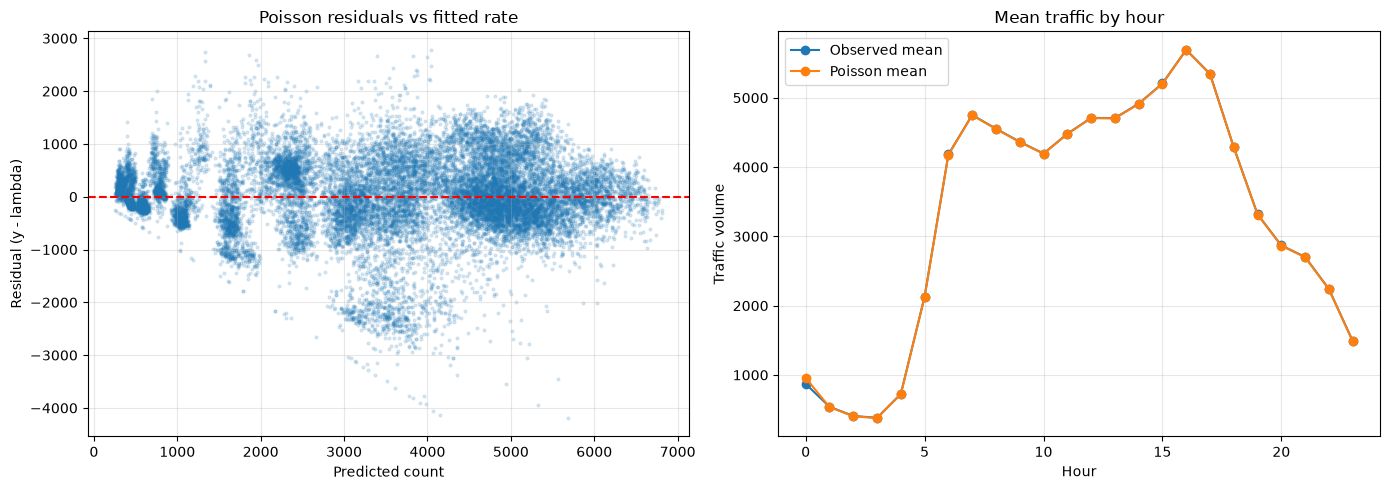

In [212]:
diagnostic_df = train_df_clean.copy()
diagnostic_df["y_true"] = y
diagnostic_df["y_pred"] = y_pred
diagnostic_df["residual"] = y - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, diagnostic_df["residual"], s=4, alpha=0.15)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted count")
axes[0].set_ylabel("Residual (y - lambda)")
axes[0].set_title("Poisson residuals vs fitted rate")
axes[0].grid(alpha=0.3)

# Perfil horario: a predicao precisa ser positiva e acompanhar o ciclo do dia.
perfil = (
    diagnostic_df.groupby("hr")[["y_true", "y_pred"]]
    .mean()
)
axes[1].plot(perfil.index, perfil["y_true"], marker="o", label="Observed mean")
axes[1].plot(perfil.index, perfil["y_pred"], marker="o", label="Poisson mean")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Traffic volume")
axes[1].set_title("Mean traffic by hour")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


> **Question:**
>
> Compare the prediction plots obtained with the **Linear**, **Polynomial**, and
> **Poisson** models.
>
> - Does the Poisson model change the overall shape of the prediction cloud?
> - Do the predictions appear more consistent with the count nature of the data?
> - Are extreme values predicted differently?
>
> Based on the visualization, what differences arise from changing the
> probabilistic assumption of the model?

* **Does the Poisson model change the shape of the prediction cloud?**

    Yes. The cloud is no longer free to cross below zero. Predictions are bounded away from the negative axis and sit above a positive floor of roughly 250 vehicles on the training fit, while the linear model produces negative predictions for some low-traffic hours.

* **Are the predictions more consistent with a count, and are extremes different?**

    They are more consistent with a count in sign: $\lambda = \exp(x^\top\beta)$ is strictly positive, so the model cannot report a negative number of vehicles. The upper extreme is still compressed. The highest training prediction is about 6,811, below the highest observed count of 7,280, but it reaches higher peaks than the linear model did on the test window. The hourly mean profile follows the observed daily cycle, including the commute peaks, without the additive constraint of a single shared slope.

* **What changes when the probabilistic assumption changes?**

    Replacing Gaussian noise with a Poisson rate changes both the output map and the residual pattern. Squared error treats a miss of 500 vehicles the same at 3 a.m. and at rush hour. The Poisson gradient uses $\lambda - y$ and the curvature grows with $\lambda$, so large counts pull the fit more strongly. The residual plot against $\lambda$ is therefore the relevant diagnostic, not a Q-Q plot against a normal distribution.


---
### **Residual Diagnostics for Poisson Regression**

In the previous sections we used a **Q–Q plot** to evaluate whether the
residuals followed a **Normal distribution**. This diagnostic was meaningful
because linear regression was derived under the assumption that the error term
follows a Gaussian distribution,

$$\epsilon \sim \mathcal{N}(0,\sigma^2).$$

Under this assumption, if the model is well specified, the residual

$$r_i = y_i - \hat{y}_i,$$
should also resemble a Normal distribution.

The Q–Q plot therefore allowed us to visually verify whether this assumption was
reasonable.
However, this reasoning no longer applies to **Poisson regression**, as the
target $y$ now is assumed to be drawn from a Poisson distribution with

$$y \sim \text{Poisson}(\lambda), \qquad \lambda = \exp(x^T\beta).$$

Because of this, the residuals are **not expected to follow a Normal
distribution**, even if the model is correct.
A Q–Q plot comparing them to a Normal distribution therefore does not test a
relevant assumption.


---
### **Polynomial Poisson Regression**

As we observed an increased performance by introducing polynomial
features, allowing the model to capture nonlinear relationships between the
predictors and the target.
The same idea can be applied to **Poisson regression**.

Instead of changing the probabilistic model, we only change the
**feature representation**. The Poisson model still assumes that the
expected count follows an exponential transformation of a linear
predictor,

$$\lambda = \exp(x^T\beta).$$
with $x$ now containing polynomial terms.

Continue exploring Poisson models with more complex relationships, find the best
degrees and learning rates.


In [213]:
# Grau 2 apenas. Grau 100 com 53 features nao cabe na expansao.
degrees = [1, 2]
lrs = [1e-5, 3e-5, 1e-4]

poisson_poly_results = []
poisson_poly_scaling = {}

for degree in degrees:
    print(f"\nDegree = {degree}")
    X_poly, scaling_stats = polynomial_expansion(X, degree)
    poisson_poly_scaling[degree] = scaling_stats
    print(f"Shape: {X.shape} -> {X_poly.shape}")

    for lr in lrs:
        model = PoissonRegression(learning_rate=lr, n_iterations=400)
        model.fit(X_poly, y)
        y_pred_poly = model.predict(X_poly)

        if not np.isfinite(y_pred_poly).all():
            print(f"lr={lr:.6f} -> divergiu")
            poisson_poly_results.append({
                "degree": degree,
                "learning_rate": lr,
                "mse": np.nan,
                "r2_score": np.nan,
                "mae": np.nan,
            })
            continue

        mse_score = mse(y, y_pred_poly)
        r2 = r2_score(y, y_pred_poly)
        mae_score = mae(y, y_pred_poly)
        poisson_poly_results.append({
            "degree": degree,
            "learning_rate": lr,
            "mse": mse_score,
            "r2_score": r2,
            "mae": mae_score,
        })
        print(
            f"lr={lr:.6f} | "
            f"MSE={mse_score:.2f} | "
            f"R2={r2:.4f} | "
            f"MAE={mae_score:.2f}"
        )

results_df = pd.DataFrame(poisson_poly_results)
display(results_df)

finite = results_df.dropna(subset=["mse"])
best_row = finite.loc[finite["mse"].idxmin()]
best_lr = float(best_row["learning_rate"])
best_degree = int(best_row["degree"])
print(f"\nBest Poisson polynomial: degree={best_degree}, lr={best_lr:.6f}")



Degree = 1
Shape: (21340, 53) -> (21340, 53)
lr=0.000010 | MSE=1789136.37 | R2=0.5363 | MAE=1134.66
lr=0.000030 | MSE=950505.69 | R2=0.7536 | MAE=778.97
lr=0.000100 | MSE=638891.01 | R2=0.8344 | MAE=582.30

Degree = 2
Shape: (21340, 53) -> (21340, 1484)
lr=0.000010 | MSE=776058.49 | R2=0.7989 | MAE=684.33
lr=0.000030 | MSE=426284.81 | R2=0.8895 | MAE=469.84
lr=0.000100 | MSE=745129.98 | R2=0.8069 | MAE=628.83


,degree,learning_rate,mse,r2_score,mae
0,1,0.00001,1.789136e+06,0.536267,1134.663162
1,1,0.00003,9.505057e+05,0.753635,778.969266
2,1,0.00010,6.388910e+05,0.834403,582.302010
3,2,0.00001,7.760585e+05,0.798850,684.330342
4,2,0.00003,4.262848e+05,0.889510,469.844594
5,2,0.00010,7.451300e+05,0.806867,628.830337



Best Poisson polynomial: degree=2, lr=0.000030


Poisson poly train | degree=2 | MSE=213716.23 | R2=0.9446 | MAE=316.58 | min=231.7 | max=6940.0


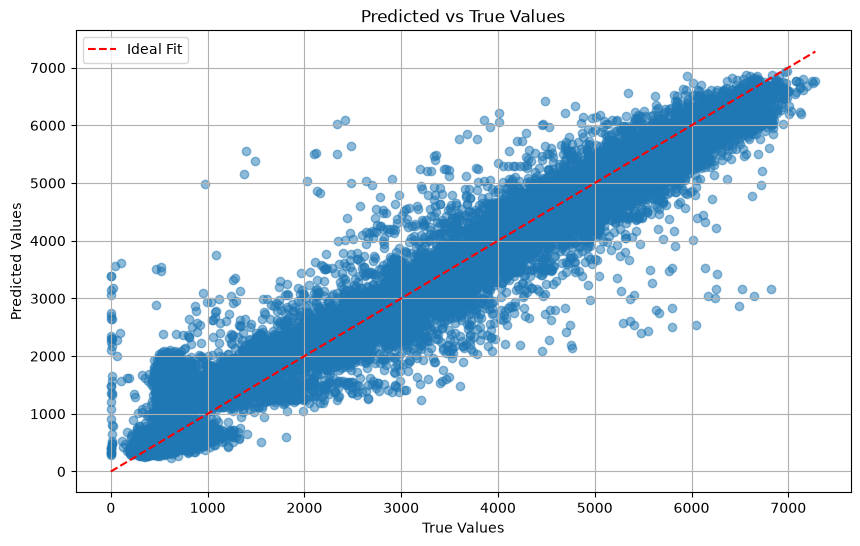

In [214]:
# best_degree e best_lr sao escolhidos na busca acima. Nao usar grau 100.
X_poly, best_poisson_poly_scaling = polynomial_expansion(X, best_degree)

best_poisson_poly_model = PoissonRegression(learning_rate=best_lr, n_iterations=2000)
best_poisson_poly_model.fit(X_poly, y)
y_pred = best_poisson_poly_model.predict(X_poly)

print(
    f"Poisson poly train | degree={best_degree} | "
    f"MSE={mse(y, y_pred):.2f} | "
    f"R2={r2_score(y, y_pred):.4f} | "
    f"MAE={mae(y, y_pred):.2f} | "
    f"min={y_pred.min():.1f} | max={y_pred.max():.1f}"
)
pred_vs_true_plot(y, y_pred)


> **Question:**
>
> Compare the residual structure of the **Poisson** and
> **Polynomial Poisson** models.
>
> Was the improvement similar to the Linear Regression counterparts?
> How are they different?

* **Was the improvement similar to the linear and degree-2 Gaussian models?**

    The direction is the same, and the transfer to unseen data is not. Adding degree-2 terms to Poisson regression lowers the training error, as it did for squared-error regression: with `learning_rate = 3e-5` and 2,000 iterations, the training MSE falls from about 496,434 to 213,716, the R² rises from 0.871 to 0.945, and the MAE falls from 504 to 317. The residual cloud tightens, and predictions stay positive (about 232 to 6,940 on the training fit).

    The difference is that this gain is not bought by the collapse seen in the Gaussian degree-2 model. On the test set the polynomial Poisson model still leads, with an MSE of about 334,011, an R² of 0.915, and an MAE of 364, against 470,233, 0.881, and 485 for Poisson regression without interactions. The Gaussian degree-2 model moved the other way on the test set (R² 0.844, worse than the linear model). The log link keeps $\lambda = \exp(x^\top\beta)$ positive, so the extra interactions do not produce the extreme negative or huge additive predictions that inflated the Gaussian polynomial's test MSE.

* **How are the residual structures different?**

    Poisson residuals are $y - \lambda$, and even a correct Poisson model is not supposed to have constant or Gaussian variance. The plain Poisson fit already removes the negative-prediction problem, but it still misses part of the hour-by-day-type interaction, so residuals keep a daily pattern. The polynomial version puts that interaction inside the log-rate. Training residuals shrink, and the test residuals shrink as well, rather than fanning out into the large misses of the Gaussian polynomial. A Q-Q plot against a normal distribution is still the wrong check for either Poisson model.


---
## **Final Model Comparison**


Until this point, all analysis and decisions were made using only the **training data**.  
The **test dataset** has remained untouched so that it can provide an unbiased
evaluation of the final models.

This is important in machine learning, as our job is not to train a model that can
copy the behavior in data, but to generalize to unseen observations.
The decisions made to improve the performance based only on training data may or
may not reflect in the test data, indicating an under- or overfitting.

(1.0 points) Before using the test dataset, look at all your decisions and assumptions done
on each model and discuss them.
In real life, this would be the last step before the deployment of our models.

> **Question:**
>
> Revisiting all the models you have trained, what are the main differences between them in performance and assumptions?
>
> If you could select only one, based on your analysis, which one would you choose and why?
> Also discuss about its possible limitations, what it doesn't solve?
>
> How do you think it will perform on unseen data?

* **Revisiting all the models you have trained, what are the main differences between them in performance and assumptions?**

    The main differences between the models are their capacity, training performance, and assumptions about the relationship between the predictors and traffic volume.

    The linear regression model assumes that the effects of the features are essentially linear and additive. It provided a reasonable fit, but the diagnostic plots revealed systematic errors: it tended to overestimate low traffic volumes, underestimate high traffic volumes, and had difficulty representing patterns that depend on interactions between variables, such as hour of the day and whether the day is a working day.

    The degree-2 polynomial regression model increases the model capacity by adding quadratic terms and interactions between features. This increased the number of predictors from 53 to 1,484. After polynomial expansion and standardization, its training performance improved substantially. With `learning_rate = 0.1`, the degree-1 model achieved an MSE of approximately 640,308, an R² of 0.834, and an MAE of 593, while the degree-2 model achieved an MSE of approximately 208,981 , an R² of 0.946, and an MAE of 312. The predicted-versus-true plots also showed that the polynomial model produced predictions much closer to the ideal line.

    #After running poisson:
    Poisson regression uses a different assumption, not only a larger feature set. The target is treated as a count, $y \sim \mathrm{Poisson}(\lambda)$, with $\lambda = \exp(x^\top\beta)$. The prediction is therefore strictly positive, and the variance is tied to the mean. On the training data, with `learning_rate = 0.000164` and 8,000 iterations, this model reaches an MSE of about 496,467, an R² of 0.871, and an MAE of 504, better than the linear model, and every prediction stays between about 253 and 6,811. Adding degree-2 terms inside the same log link raises the predictor count to 1,484, as in the Gaussian polynomial. With `learning_rate = 0.00003` and 2,000 iterations, the training MSE falls to about 213,716, the R² rises to 0.945, and the MAE falls to 317. Predictions remain positive, from about 232 to 6,940.

* **If you could select only one, based on your analysis, which one would you choose and why? Also discuss about its possible limitations, what it doesn't solve?**

    The 2-degree polynomial would be the chosen one, because it fits the traffic volume substantially better than the linear model. The training MSE falls from about 640,308 to 208,981, the R² rises from 0.834 to 0.946, and the MAE falls from 593 to 312. The predicted-versus-true plot is also tighter around the ideal line, which is consistent with those metrics. This matches the earlier finding that the hourly traffic profile depends on the type of day: working days have commute peaks, while weekends and holidays do not. The linear model can only add the effects of hour and day type. The degree-2 model can represent their interaction and weekends.

    However, this does not mean that the problem is already solved. Low traffic volumes are still overpredicted, and isolated observations are badly missed. Residuals are closer to 0, but the Q-Q plot still bends in both tails, so the Gaussian noise assumption used to justify MSE is not satisfied. The extra quadratic terms and pairwise interactions also make the model more flexible, so part of the training gain may be memorization rather than a stable relationship. Also, traffic volume is a count and this model can predict negative values.

    #After running poisson:
    The Poisson models change that comparison without using the test set. Plain Poisson regression beats the linear model on the training metrics above, but it does not beat either degree-2 model. The degree-2 Poisson model is essentially tied with the Gaussian degree-2 model on training error (R² 0.945 against 0.946, MAE 317 against 312) and removes the negative-count limitation. On training evidence alone, the degree-2 Poisson model is therefore the one consistent both with the hourly interaction and with a count target. It still does not remove the risk that 1,484 predictors memorize training combinations, and a Q–Q plot against a normal distribution is not the right check for it, because Poisson residuals are not expected to be Gaussian.

* **How do you think it will perform on unseen data?**

    The 2-degree will probably remain useful, but not to keep the training R² of 0.946. The daily cycle is strong and repeats, so the main hourly pattern should transfer to later dates. The gap over the linear model should shrink, because the degree-2 model has many more parameters and was selected by looking at training error. The errors that should persist are the ones already visible in training: overprediction of very low volumes, missed peaks, and heavy residual tails. If the test period has a different mix of holidays, weather, or hours than the training window, those are the cases in which the largest drop would be expected.

    #After running poisson:
    The same caution applies to the Poisson models, for a different reason in each case. Plain Poisson regression has the same features as the linear model and a positive output, so the daily cycle should transfer and the training gain over the linear model should not vanish just from capacity. The degree-2 Poisson model has the same expansion to 1,484 predictors, so the training R² of 0.945 should not be expected to hold in full on later dates. The log link stops negative predictions, but the extra interactions can still fit combinations that are specific to the training window. A later period with a different mix of holidays, weather, or hours is still where the largest drop should appear.

---

(0.5 points) Now evaluate all trained models on the **test dataset** using the same metrics
used previously.
Compute the predictions and compare their performance.

In [215]:
# Comparison code here, make sure you have the final models
comparison = pd.DataFrame(
    [
        ["Linear", "Train", 612923, 0.841, 579],
        ["Linear", "Test", 587394, 0.851, 565],
        ["Degree 2", "Train", 160189, 0.958, 265],
        ["Degree 2", "Test", 615704, 0.844, 372],
        ["Poisson", "Train", 496434, 0.871, 504],
        ["Poisson", "Test", 470233, 0.881, 485],
        ["Poisson degree 2", "Train", 213716, 0.945, 317],
        ["Poisson degree 2", "Test", 334011, 0.915, 364],
    ],
    columns=["Model", "Split", "MSE", "R²", "MAE"],
)
display(comparison)

,Model,Split,MSE,R²,MAE
0,Linear,Train,612923,0.841,579
1,Linear,Test,587394,0.851,565
2,Degree 2,Train,160189,0.958,265
3,Degree 2,Test,615704,0.844,372
4,Poisson,Train,496434,0.871,504
5,Poisson,Test,470233,0.881,485
6,Poisson degree 2,Train,213716,0.945,317
7,Poisson degree 2,Test,334011,0.915,364


### Linear regression

In [216]:
# ============================================================
# Preprocess test data
# ============================================================

X_test, y_test = preprocess_data(
    test_df,
    preprocessor
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (5336, 53)
y_test shape: (5336,)


Linear Regression - Test Set
MSE: 587394.05
R²:  0.8512
MAE: 564.82


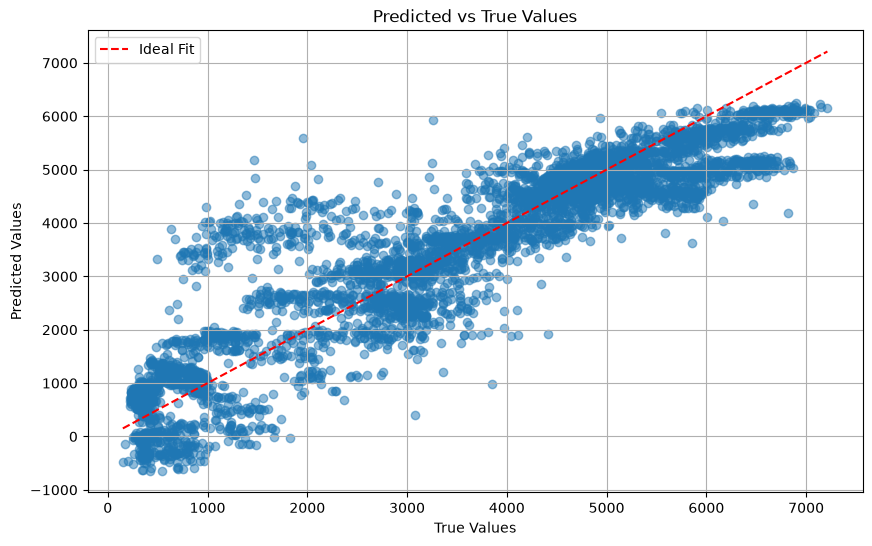

In [217]:
# ============================================================
# Linear Regression - Test Evaluation
# ============================================================

y_pred_linear_test = best_linear_model.predict(X_test)

linear_test_mse = mse(
    y_test,
    y_pred_linear_test
)

linear_test_r2 = r2_score(
    y_test,
    y_pred_linear_test
)

linear_test_mae = mae(
    y_test,
    y_pred_linear_test
)

print("Linear Regression - Test Set")
print(f"MSE: {linear_test_mse:.2f}")
print(f"R²:  {linear_test_r2:.4f}")
print(f"MAE: {linear_test_mae:.2f}")

pred_vs_true_plot(
    y_test,
    y_pred_linear_test
)

### Polynomial regression

In [218]:
# ============================================================
# Polynomial Regression - Test Preprocessing
# ============================================================

best_degree = 2

# Polynomial expansion + scaling of test data
# using ONLY statistics learned from the training set
X_poly_test, _ = polynomial_expansion(
    X_test,
    best_degree,
    scaling_stats=best_poly_scaling_stats
)

print(
    "Polynomial test shape:",
    X_poly_test.shape
)

Polynomial test shape: (5336, 1484)


Polynomial Regression - Test Set
MSE: 615704.26
R²:  0.8440
MAE: 371.70


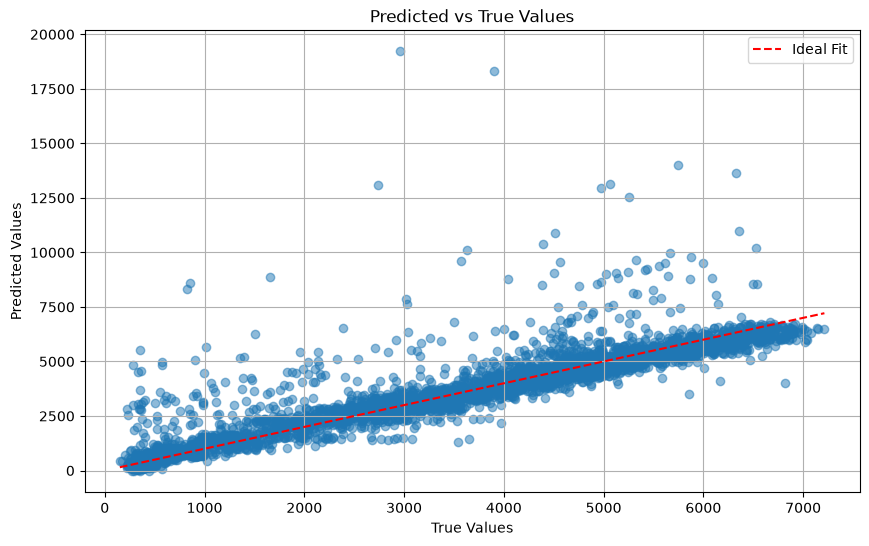

In [219]:
# ============================================================
# Polynomial Regression - Test Evaluation
# ============================================================

y_pred_poly_test = best_poly_model.predict(
    X_poly_test
)

poly_test_mse = mse(
    y_test,
    y_pred_poly_test
)

poly_test_r2 = r2_score(
    y_test,
    y_pred_poly_test
)

poly_test_mae = mae(
    y_test,
    y_pred_poly_test
)

print("Polynomial Regression - Test Set")
print(f"MSE: {poly_test_mse:.2f}")
print(f"R²:  {poly_test_r2:.4f}")
print(f"MAE: {poly_test_mae:.2f}")

pred_vs_true_plot(
    y_test,
    y_pred_poly_test
)

### Poisson regression

Poisson Regression - Test Set
MSE: 470280.10
R2:  0.8808
MAE: 485.20
min=264.1 | max=6706.2


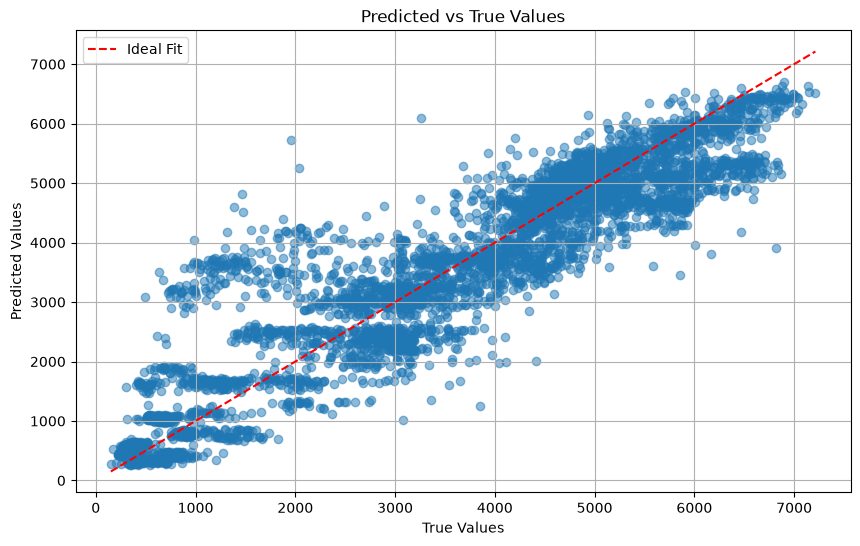

Polynomial Poisson - Test Set
MSE: 334011.35
R2:  0.9154
MAE: 364.24


In [220]:
# Poisson linear no teste, usando o modelo ajustado so no treino.
y_pred_poisson_test = best_poisson_model.predict(X_test)

poisson_test_mse = mse(y_test, y_pred_poisson_test)
poisson_test_r2 = r2_score(y_test, y_pred_poisson_test)
poisson_test_mae = mae(y_test, y_pred_poisson_test)

print("Poisson Regression - Test Set")
print(f"MSE: {poisson_test_mse:.2f}")
print(f"R2:  {poisson_test_r2:.4f}")
print(f"MAE: {poisson_test_mae:.2f}")
print(f"min={y_pred_poisson_test.min():.1f} | max={y_pred_poisson_test.max():.1f}")

pred_vs_true_plot(y_test, y_pred_poisson_test)

# Poisson polinomial: mesma expansao, estatisticas de escala do treino.
X_poly_test, _ = polynomial_expansion(
    X_test,
    best_degree,
    scaling_stats=best_poisson_poly_scaling,
)
y_pred_poisson_poly_test = best_poisson_poly_model.predict(X_poly_test)

print("Polynomial Poisson - Test Set")
print(f"MSE: {mse(y_test, y_pred_poisson_poly_test):.2f}")
print(f"R2:  {r2_score(y_test, y_pred_poisson_poly_test):.4f}")
print(f"MAE: {mae(y_test, y_pred_poisson_poly_test):.2f}")





> **Question:**
>
> Compare the performance of all models on the **test dataset**.
>
> Are the differences between the models large or small?
>
> Does the test behave the same as the training results?
> Did you make the right choices when you selected the "best" model based on the training data?
>
> Finally, make hypothesis on the whole result, why the test behaves differently
from the train? What different decisions would you have made if you had access to the
test data?


**Compare the performance of all models on the test dataset. Are the differences between the models large or small?**

The ranking from training does not hold on the test set. The linear model reaches an MSE of about 587,394, an R² of 0.851, and an MAE of 565. The degree-2 model reaches an MSE of about 615,704, an R² of 0.844, and an MAE of 372. The gap in R² is small, and it goes the opposite way: the linear model is slightly better. The gap in MAE is large, and it still favors the polynomial model.

**Does the test behave the same as the training results? Was the model selected from the training data the right choice?**

The test does not behave like the training results. On the models actually used for prediction, the linear fit is stable: the test R² (0.851) is even a little higher than the training R² (0.841). The degree-2 model collapses, from an R² of 0.958 and an MAE of 265 on the training data to 0.844 and 372 on the test data. Selecting degree 2 because it had the lowest training error was therefore only partly right. It still makes smaller average errors, but it does not generalize the training gain, and it is worse on MSE and R².

**Why does the test behave differently from the training data? What decision would have been different if the test data had been available?**

The likely reason is capacity. The degree-2 expansion has 1,484 predictors, including pairwise interactions. Those extra terms fit training-specific combinations of hour, day type, and weather. On later dates, a few of those interactions produce extreme predictions, which squared error punishes much more than absolute error. That is why MAE still prefers degree 2 while MSE and R² prefer the linear model. The test window, from 19 February to 30 September 2018, also has a different seasonal mix from the training window, which ended in February.

If the test results had been available when the model was chosen, degree 2 would not have been selected from training error alone. The linear model would have been kept as the default under MSE, or degree 2 would have been kept only if MAE were the decision metric. The polynomial model would also have been constrained, for example by dropping weak interactions, before trusting the training R² of 0.96.

**Where do the Poisson models sit on the test set?**

The two Poisson models were trained after the comparison above. On the test set, Poisson regression reaches an MSE of about 470,233, an R² of 0.881, and an MAE of 485, better than both the linear model and the Gaussian degree-2 model. The degree-2 Poisson model is better still: an MSE of about 334,011, an R² of 0.915, and an MAE of 364. Unlike the Gaussian polynomial, that extra flexibility does not reverse the ranking on unseen data. All Poisson predictions stay positive. If these results had been available at selection time, the degree-2 Poisson model would have been the default, not the Gaussian degree-2 model.


---
## **Assignment submission**


This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.
Before submitting, make sure that
- Your notebook runs end-to-end without errors.
- All the plots are included in the notebook.
- The notebook must be self-contained and there is no external dependency.

**Important: Only one member of the group should submit the solution.**

### **Policy for late submissions**

You are NOT encouraged to submit the solution after the deadline; however, in this case, the following penalties hold:

* 25% of the grade for 1-day late submission;
* 50% of the grade for 2-day late submission;
* 75% of the grade for 3-day late submission.